In [45]:
import scanpy as sc
#adata=sc.read_h5ad("/app/project/restore_data/pipeline_articulo/4.models/scanvi_model/scanvi_integrated.h5ad")
#adata

In [46]:
# Crear una máscara booleana para seleccionar solo 'old' y 'young'
#mask = adata.obs['age_group'].isin(['old', 'adult'])

# Crear el nuevo dataset filtrado
#adata_filtered = adata[mask].copy()

# Verificar el resultado
#print("\nTamaño del dataset original:", adata.n_obs)
#print("Tamaño del nuevo dataset:", adata_filtered.n_obs)
#print("\nDistribución de grupos de edad en el nuevo dataset:")
#print(adata_filtered.obs['age_group'].value_counts())

In [47]:
# Guardar el archivo
#output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/4.models/scanvi_model/scanvi_sin_jovenes.h5ad'
#adata_filtered.write_h5ad(output_path)

#print(f"Archivo guardado exitosamente en: {output_path}")

In [48]:
#check point para no creear dataset desde cero
import scanpy as sc
adata=sc.read_h5ad('/app/project/restore_data/pipeline_articulo/old_vs_adult/4.models/scanvi_model/scanvi_sin_jovenes.h5ad')
# Verificar el resultado
print("Tamaño del nuevo dataset:", adata.n_obs)
print("\nDistribución de grupos de edad en el nuevo dataset:")
print(adata.obs['age_group'].value_counts())

Tamaño del nuevo dataset: 193701

Distribución de grupos de edad en el nuevo dataset:
age_group
adult    133527
old       60174
Name: count, dtype: int64


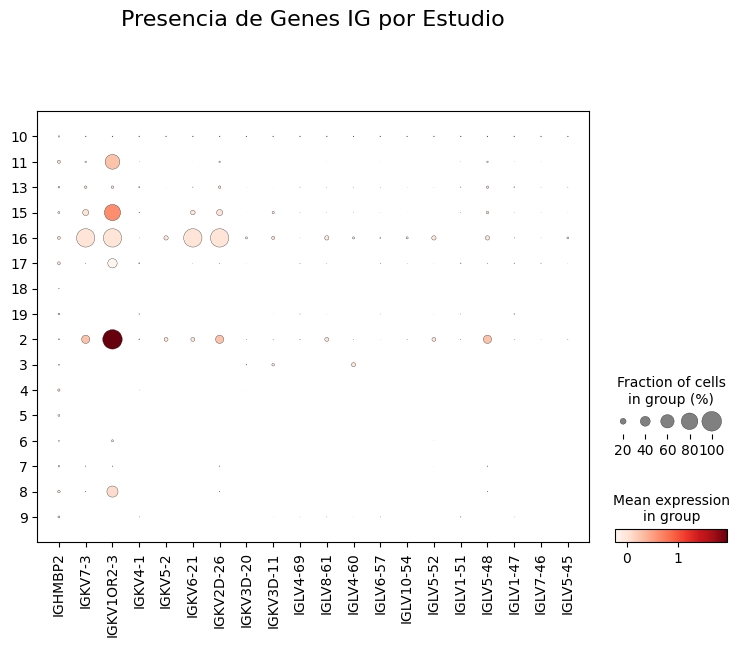

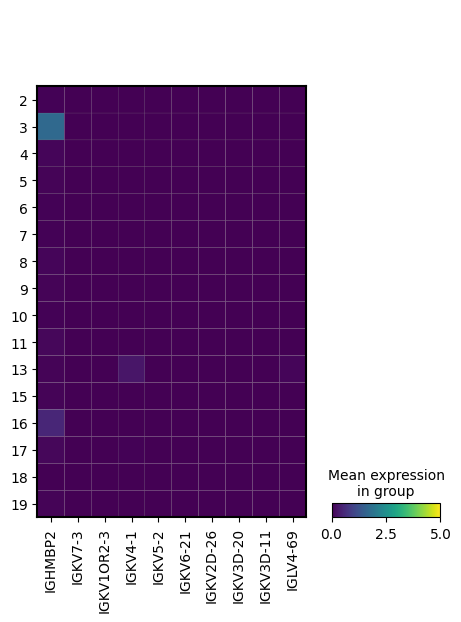

In [49]:
# 1. Definir firma de genes IG
ig_genes = adata.var_names[adata.var_names.str.startswith(('IGK', 'IGL', 'IGH'))].tolist()

# 2. Calcular puntuación media de IG por célula (o usar dotplot)
sc.pl.dotplot(adata, var_names=ig_genes[:20], groupby='short_title', 
              categories_order=sorted(adata.obs.short_title.unique()),
              title="Presencia de Genes IG por Estudio")

# 3. Comparar adultos vs viejos dentro de cada estudio (si tienen ambos)
# Esto te dirá si la "subexpresión" es real en cada estudio o si unos estudios "ensucian" el promedio
sc.pl.matrixplot(adata, var_names=ig_genes[:10], groupby='short_title', 
                 layer='counts', dendrogram=False, vmin=0, vmax=5)

In [50]:
# 1. Definir la máscara booleana basada en los 7000 genes originales
genes_to_exclude = adata.var_names.str.startswith(('IGH', 'IGK', 'IGL', "TRAV", "TRAJ", "TRAC",
                                            "TRBV", "TRBD", "TRBJ", "TRBC",
                                            "TRGV", "TRGJ", "TRGC",
                                            "TRDV", "TRDJ", "TRDC"))

# 2. EXTRAER LA LISTA PRIMERO (aquí es donde fallaba)
# Usamos la máscara sobre los var_names originales antes de filtrar adata
removed_genes_list = adata.var_names[genes_to_exclude].tolist()

print(f"Genes identificados para eliminar: {len(removed_genes_list)}")

# 3. AHORA FILTRAR el objeto adata
print(f"Genes antes del filtro: {adata.n_vars}")
adata = adata[:, ~genes_to_exclude].copy()
print(f"Genes después del filtro: {adata.n_vars}")

# 4. Verificación rápida
print("Primeros 5 genes eliminados:", removed_genes_list[:5])

Genes identificados para eliminar: 255
Genes antes del filtro: 7000
Genes después del filtro: 6745
Primeros 5 genes eliminados: ['IGHMBP2', 'IGKV7-3', 'IGKV1OR2-3', 'IGKV4-1', 'IGKV5-2']


In [51]:
cell_subset= adata.copy()

In [52]:
cell_subset

AnnData object with n_obs × n_vars = 193701 × 6745
    obs: 'dataset_id', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_group', 'age_yrs', 'age_group', 'source_file', 'title', 'short_title', 'batch', 'n_genes_by_counts', 'total_counts', 'n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'complexity', '_scvi_batch', '_scvi_labels', 'doublet_score', 'singlet_score', 'doublet_prediction', 'leiden', 'scanvi_leiden'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_length', 'nnz', 'n_measured_obs', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'genome', 'hvg', 'hvg_genes', 'leiden', 'leiden_colors', 'log1p', 'modality', 'neighbors', 'pca', 'processing_info', 'scanvi_leiden', 'scanvi_leiden_co

In [53]:
import scanpy as sc
import numpy as np
from scipy import sparse

# Creamos un identificador único de muestra (si no existe ya)
if 'pb_identifier' not in cell_subset.obs.columns:
    cell_subset.obs['pb_identifier'] =  cell_subset.obs['age_group'].astype(str) + '-' + cell_subset.obs['donor_id'].astype(str)

pbs = []
for title in cell_subset.obs.pb_identifier.unique():
    samp_cell_subset = cell_subset[cell_subset.obs['pb_identifier'] == title]
    
    # Obtener los conteos crudos
    X = samp_cell_subset.layers['counts']
    
    # Sumar los conteos y manejar matrices sparse
    if sparse.issparse(X):
        summed_counts = X.sum(axis=0).A1
    else:
        summed_counts = X.sum(axis=0)
    
    # Crear nuevo AnnData
    rep_adata = sc.AnnData(
        X = summed_counts.reshape(1, -1),
        var = samp_cell_subset.var[[]]
    )
    
    # Agregar metadatos - ahora incluimos tanto short_title como donor_id
    rep_adata.obs_names = [title]
    rep_adata.obs['age_group'] = samp_cell_subset.obs['age_group'].iloc[0]
    rep_adata.obs['donor_id'] = samp_cell_subset.obs['donor_id'].iloc[0]  # Mantenemos el donor_id
    rep_adata.obs['sex'] = samp_cell_subset.obs['sex'].iloc[0] 
    rep_adata.obs['self_reported_ethnicity'] = samp_cell_subset.obs['self_reported_ethnicity'].iloc[0] 
    rep_adata.obs['cell_type'] = samp_cell_subset.obs['cell_type'].iloc[0] 
    rep_adata.obs['short_title'] = samp_cell_subset.obs['short_title'].iloc[0]
    rep_adata.obs['age_yrs'] = samp_cell_subset.obs['age_yrs'].iloc[0] 


    
    pbs.append(rep_adata)

# Concatenar todos los resultados
pb = sc.concat(pbs)

In [54]:

# Verificar resultado
print("Forma del pseudobulk:", pb.shape)
print("Columnas en obs:", pb.obs.columns)
print("Tipos únicos en age_group:", pb.obs['age_group'].unique())

# Verificar valores
if sparse.issparse(pb.X):
    print("\nEstadísticas de los conteos:")
    print("Mínimo:", pb.X.data.min())
    print("Máximo:", pb.X.data.max())
else:
    print("\nEstadísticas de los conteos:")
    print("Mínimo:", pb.X.min())
    print("Máximo:", pb.X.max())

Forma del pseudobulk: (502, 6745)
Columnas en obs: Index(['age_group', 'donor_id', 'sex', 'self_reported_ethnicity', 'cell_type',
       'short_title', 'age_yrs'],
      dtype='object')
Tipos únicos en age_group: ['old' 'adult']

Estadísticas de los conteos:
Mínimo: 0
Máximo: 998641


In [55]:
pb.obs

,age_group,donor_id,sex,self_reported_ethnicity,cell_type,short_title,age_yrs
old-1,old,1,male,unknown,natural killer cell,3,75
adult-H1,adult,H1,female,European,natural killer cell,4,49
adult-H2,adult,H2,male,European,natural killer cell,4,49
adult-H3,adult,H3,female,European,natural killer cell,4,36
adult-H4,adult,H4,male,European,natural killer cell,4,49
...,...,...,...,...,...,...,...
adult-P-HC018,adult,P-HC018,male,unknown,natural killer cell,19,55
adult-P-HC001,adult,P-HC001,female,unknown,natural killer cell,19,53
adult-P-HC002,adult,P-HC002,male,unknown,natural killer cell,19,49
adult-P-HC003,adult,P-HC003,male,unknown,natural killer cell,19,46


In [56]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

counts = pd.DataFrame(pb.X, columns=pb.var_names)

# Incluimos donor_id en el diseño
dds = DeseqDataSet(
    counts=counts,
    metadata=pb.obs,
    design_factors= [ "age_group"])  # Aquí incluimos donor_id como covariable

dds.deseq2()



Fitting size factors...
... done in 0.10 seconds.

Fitting dispersions...
... done in 1.77 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 1.59 seconds.

Fitting LFCs...
... done in 1.39 seconds.

Calculating cook's distance...
... done in 0.44 seconds.

Replacing 880 outlier genes.

Fitting dispersions...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 0.30 seconds.

Fitting LFCs...
... done in 0.27 seconds.



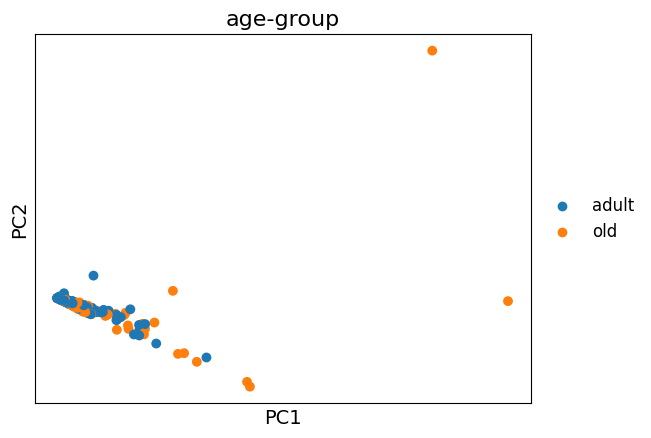

In [57]:
sc.tl.pca(dds)
sc.pl.pca(dds, color = 'age-group', size = 200)

In [58]:
# Para el contraste, seguimos interesados en age_group
stat_res = DeseqStats(dds, contrast=('age-group', 'old', 'adult'))
    
stat_res.summary()
de = stat_res.results_df
de.sort_values('stat', ascending=False)

Running Wald tests...


Log2 fold change & Wald test p-value: age-group old vs adult
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
featurekey                                                                    
DPM1         26.904069        0.082418  0.059806  1.378092  0.168175  0.314143
FGR         258.387210       -0.032267  0.061656 -0.523346  0.600734  0.753391
FUCA2        22.178823        0.237161  0.056207  4.219456  0.000024  0.000406
GCLC         20.581617       -0.026719  0.072932 -0.366353  0.714102  0.836013
NFYA         14.611691       -0.285374  0.064176 -4.446706  0.000009  0.000181
...                ...             ...       ...       ...       ...       ...
COPG2IT1      0.495402       -0.003422  0.292031 -0.011719  0.990650  0.995254
GABPB1-IT1   43.324761       -0.273720  0.227327 -1.204081  0.228558  0.392603
PDGFRL2P      0.004997       -0.173817  3.436215 -0.050584  0.959657       NaN
BMS1P23       0.001258       -0.140240  3.435881 -0.040816  0.967442  

... done in 0.81 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
SERPINA1,25.815199,2.940629,0.237045,12.405339,2.444763e-35,1.321150e-31
CXCL8,8.556232,2.033144,0.252325,8.057633,7.778581e-16,2.101773e-12
IFT22,4.855280,0.779391,0.101651,7.667289,1.756696e-14,3.164395e-11
CST3,118.633573,1.198063,0.162781,7.359951,1.839771e-13,2.485530e-10
LST1,73.460945,1.690537,0.231003,7.318259,2.512086e-13,2.715063e-10
...,...,...,...,...,...,...
TMEM108-AS1,0.000000,NaN,NaN,NaN,NaN,NaN
LINC02230,0.000000,NaN,NaN,NaN,NaN,NaN
LINC02489,0.000000,NaN,NaN,NaN,NaN,NaN


In [59]:
# Ya está incluido en DESeq2, pero podríamos verificar
lib_sizes = pb.X.sum(axis=1)
print("\nEstadísticas de tamaño de biblioteca:")
print(pd.Series(lib_sizes).describe())


Estadísticas de tamaño de biblioteca:
count    5.020000e+02
mean     7.060816e+05
std      1.170381e+06
min      1.289000e+03
25%      2.826375e+05
50%      4.825145e+05
75%      7.544162e+05
max      1.682589e+07
dtype: float64


In [60]:
# Documentar las decisiones de diseño
print("\nParámetros del análisis:")
print(f"Número total de donantes: {len(pb.obs)}")
print(f"Número de genes: {len(pb.var)}")
print(f"Diseño: {pb.obs['age_group'].value_counts()}")


Parámetros del análisis:
Número total de donantes: 502
Número de genes: 6745
Diseño: age_group
adult    384
old      118
Name: count, dtype: int64


In [61]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def create_deseq2_report(adata, pb, de_results, output_prefix="deseq2_report"):
    """
    Crear un reporte completo del análisis DESeq2
    """
    # 1. Información General
    print("=== REPORTE DE ANÁLISIS DESEQ2 ===")
    print("\n1. INFORMACIÓN GENERAL")
    print("--------------------------")
    print(f"Número total de células en datos originales: {adata.n_obs}")
    print(f"Número de donantes: {len(pb.obs)}")
    print(f"Número de genes analizados: {len(pb.var)}")
    print("\nDistribución por grupo de edad:")
    print(pb.obs['age_group'].value_counts())
    
    # 2. Estadísticas de Expresión
    print("\n2. ESTADÍSTICAS DE EXPRESIÓN")
    print("--------------------------")
    print("Estadísticas de conteos por donante:")
    counts_stats = pd.DataFrame(pb.X).describe()
    print(counts_stats)
    
    # 3. Resultados DE
    print("\n3. RESULTADOS DE EXPRESIÓN DIFERENCIAL")
    print("--------------------------")
    
    # Filtrar genes significativos
    significant = (de_results['padj'] < 0.05) & (abs(de_results['log2FoldChange']) > 1)
    
    print(f"Genes totales analizados: {len(de_results)}")
    print(f"Genes significativos (padj < 0.05 & |log2FC| > 1): {sum(significant)}")
    print(f"Genes up-regulados en 'old': {sum((de_results['log2FoldChange'] > 1) & (de_results['padj'] < 0.05))}")
    print(f"Genes down-regulados en 'old': {sum((de_results['log2FoldChange'] < -1) & (de_results['padj'] < 0.05))}")
    
    # 4. Visualizaciones
    print("\n4. GENERANDO VISUALIZACIONES")
    print("--------------------------")
    
    # Volcano plot
    plt.figure(figsize=(10, 8))
    plt.scatter(
        de_results['log2FoldChange'],
        -np.log10(de_results['padj']),
        alpha=0.5,
        color='gray',
        label='No significativo'
    )
    
    # Resaltar genes significativos
    plt.scatter(
        de_results.loc[significant, 'log2FoldChange'],
        -np.log10(de_results.loc[significant, 'padj']),
        alpha=0.8,
        color='red',
        label='Significativo'
    )
    
    plt.axhline(-np.log10(0.05), color='r', linestyle='--', alpha=0.3)
    plt.axvline(-1, color='r', linestyle='--', alpha=0.3)
    plt.axvline(1, color='r', linestyle='--', alpha=0.3)
    
    plt.xlabel('log2 Fold Change')
    plt.ylabel('-log10(adjusted p-value)')
    plt.title('Volcano Plot: old vs adult')
    plt.legend()
    plt.savefig(f'{output_prefix}_volcano.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # MA plot
    plt.figure(figsize=(10, 8))
    plt.scatter(
        np.log10(de_results['baseMean']),
        de_results['log2FoldChange'],
        alpha=0.5,
        color='gray'
    )
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('log10(Base Mean)')
    plt.ylabel('log2 Fold Change')
    plt.title('MA Plot')
    plt.savefig(f'{output_prefix}_MA.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # 5. Top Genes
    print("\n5. TOP GENES DIFERENCIALMENTE EXPRESADOS")
    print("--------------------------")
    sig_genes = de_results[significant].sort_values('padj')
    
    print("\nTop 10 genes up-regulados en 'old':")
    print(sig_genes[sig_genes['log2FoldChange'] > 0].head(10)[['baseMean', 'log2FoldChange', 'padj']])
    
    print("\nTop 10 genes down-regulados en 'old':")
    print(sig_genes[sig_genes['log2FoldChange'] < 0].head(10)[['baseMean', 'log2FoldChange', 'padj']])
    
    # 6. Guardar resultados
    print("\n6. GUARDANDO RESULTADOS")
    print("--------------------------")
    
    # Guardar todos los resultados
    de_results.to_csv(f'{output_prefix}_all_results.csv')
    
    # Guardar solo genes significativos
    sig_genes.to_csv(f'{output_prefix}_significant_genes.csv')
    
    print(f"\nResultados guardados en:")
    print(f"- {output_prefix}_all_results.csv")
    print(f"- {output_prefix}_significant_genes.csv")
    print(f"- {output_prefix}_volcano.png")
    print(f"- {output_prefix}_MA.png")
    
    return sig_genes

# Usar la función
sig_genes = create_deseq2_report(
    adata=adata,
    pb=pb,
    de_results=de,
    output_prefix="NK_aging_analysis"
)

=== REPORTE DE ANÁLISIS DESEQ2 ===

1. INFORMACIÓN GENERAL
--------------------------
Número total de células en datos originales: 193701
Número de donantes: 502
Número de genes analizados: 6745

Distribución por grupo de edad:
age_group
adult    384
old      118
Name: count, dtype: int64

2. ESTADÍSTICAS DE EXPRESIÓN
--------------------------
Estadísticas de conteos por donante:
              0             1            2            3           4     \
count   502.000000    502.000000   502.000000   502.000000  502.000000   
mean     44.659363    447.627490    40.055777    31.762948   22.153386   
std     150.616940   1266.868014   108.770248    63.198303   46.546420   
min       0.000000      0.000000     0.000000     0.000000    0.000000   
25%      14.000000    151.750000    13.000000    12.000000    8.000000   
50%      26.000000    293.500000    23.000000    22.000000   16.000000   
75%      41.000000    467.000000    39.000000    37.000000   26.000000   
max    3142.000000  2574

In [62]:
tabla_de_genes_up= sig_genes[sig_genes['log2FoldChange'] > 0]
tabla_de_genes_up

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
SERPINA1,25.815199,2.940629,0.237045,12.405339,2.444763e-35,1.321150e-31
CXCL8,8.556232,2.033144,0.252325,8.057633,7.778581e-16,2.101773e-12
CST3,118.633573,1.198063,0.162781,7.359951,1.839771e-13,2.485530e-10
LST1,73.460945,1.690537,0.231003,7.318259,2.512086e-13,2.715063e-10
FAM131B-AS2,3.614191,1.510134,0.210303,7.180764,6.932298e-13,5.351734e-10
IL1B,6.537629,1.669227,0.237325,7.033517,2.013919e-12,1.360402e-09
DEGS2,1.865256,1.167043,0.171493,6.805190,1.009160e-11,4.544585e-09
LINC00513,2.761999,1.537797,0.227246,6.767106,1.313841e-11,5.315457e-09
AIF1,60.830887,1.690164,0.250396,6.749964,1.478819e-11,5.327691e-09


In [63]:
tabla_de_genes_down= sig_genes[sig_genes['log2FoldChange'] < 0]
tabla_de_genes_down

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
CSF2,1.190940,-2.031524,0.483444,-4.202192,0.000026,0.000436
BGLAP,0.955799,-1.494362,0.430376,-3.472225,0.000516,0.004543
CERKL,2.049482,-1.385275,0.451750,-3.066464,0.002166,0.012600
MT-RNR2,9.476389,-9.690776,3.620622,-2.676550,0.007438,0.031751


In [64]:
up_genes= sig_genes[sig_genes['log2FoldChange'] > 0].index.tolist()
up_genes

['SERPINA1',
 'CXCL8',
 'CST3',
 'LST1',
 'FAM131B-AS2',
 'IL1B',
 'DEGS2',
 'LINC00513',
 'AIF1',
 'LYPD2',
 'SLC15A3',
 'G0S2',
 'KLC1-AS1',
 'VMO1',
 'CXCL2',
 'SULF2',
 'SIGLEC10',
 'PID1',
 'SLC16A4',
 'PDK4',
 'PABIR1',
 'SLC8A1',
 'CXCL3',
 'HBB',
 'EBLN2',
 'CTSL',
 'PTX3',
 'SPON1',
 'ANGPT2',
 'ANKRD20A4P',
 'JAKMIP1',
 'ST3GAL1-DT',
 'SIDT1-AS1',
 'DGCR6',
 'TNFAIP6',
 'CDH23',
 'BST1',
 'DUOX1',
 'SERPINB2',
 'IFI27',
 'HBA2',
 'MRFAP1P1',
 'IL6',
 'FAM220A']

In [65]:
down_genes= sig_genes[sig_genes['log2FoldChange'] < 0].index.tolist()
down_genes

['CSF2', 'BGLAP', 'CERKL', 'MT-RNR2']

In [66]:
print(sig_genes.index.tolist())

['SERPINA1', 'CXCL8', 'CST3', 'LST1', 'FAM131B-AS2', 'IL1B', 'DEGS2', 'LINC00513', 'AIF1', 'LYPD2', 'SLC15A3', 'G0S2', 'KLC1-AS1', 'VMO1', 'CXCL2', 'SULF2', 'SIGLEC10', 'PID1', 'SLC16A4', 'PDK4', 'PABIR1', 'SLC8A1', 'CXCL3', 'HBB', 'EBLN2', 'CTSL', 'PTX3', 'SPON1', 'ANGPT2', 'ANKRD20A4P', 'JAKMIP1', 'ST3GAL1-DT', 'CSF2', 'SIDT1-AS1', 'DGCR6', 'TNFAIP6', 'CDH23', 'BST1', 'BGLAP', 'DUOX1', 'SERPINB2', 'IFI27', 'CERKL', 'HBA2', 'MRFAP1P1', 'IL6', 'FAM220A', 'MT-RNR2']


In [67]:
age_color_map = {
    'young': '#1a9850',      # Verde - jóvenes
    'adult': '#fdae61',      # Naranja - adultos (CORREGIDO)
    'old': '#d73027',        # Rojo - envejecidos (CORREGIDO)
}

🎨 HEATMAP CORREGIDO - PALETA OTOÑAL Y ESPAÑOL
🔍 VERIFICACIÓN DE DATOS PARA HEATMAP
📊 Pseudobulk shape: (502, 6745)
🧬 Genes significativos: 48
👥 Grupos de edad: {'adult': 384, 'old': 118}
🎯 Genes disponibles en pb: 6745
📝 Genes significativos solicitados: 48
❓ Genes faltantes: 0

✅ Datos verificados, procediendo con heatmap...
🔬 Creando heatmap de genes diferencialmente expresados...
📊 Forma de pb: (502, 6745)
🧬 Número de genes significativos: 48
🔝 Genes seleccionados: 44 (40 up, 4 down)

📋 Estadísticas antes de la limpieza:
   NaN valores: 0
   Inf valores: 0
   Rango original: 0.00 a 998641.00
📈 Rango después de scaling: -0.30 a 22.32
👥 Grupos de edad encontrados: ['old' 'adult']
🇪🇸 Traducidos a: ['envejecidos' 'adultos']
🎯 Escala robusta: -4.13 a 4.13
🔄 Creando clustermap...
✅ Clustermap creado exitosamente
✅ Títulos y etiquetas configurados
✅ Leyenda configurada
✅ Colorbar configurado
✅ Información añadida
✅ Layout ajustado
💾 Heatmap guardado en: /app/project/restore_data/pipeline_a

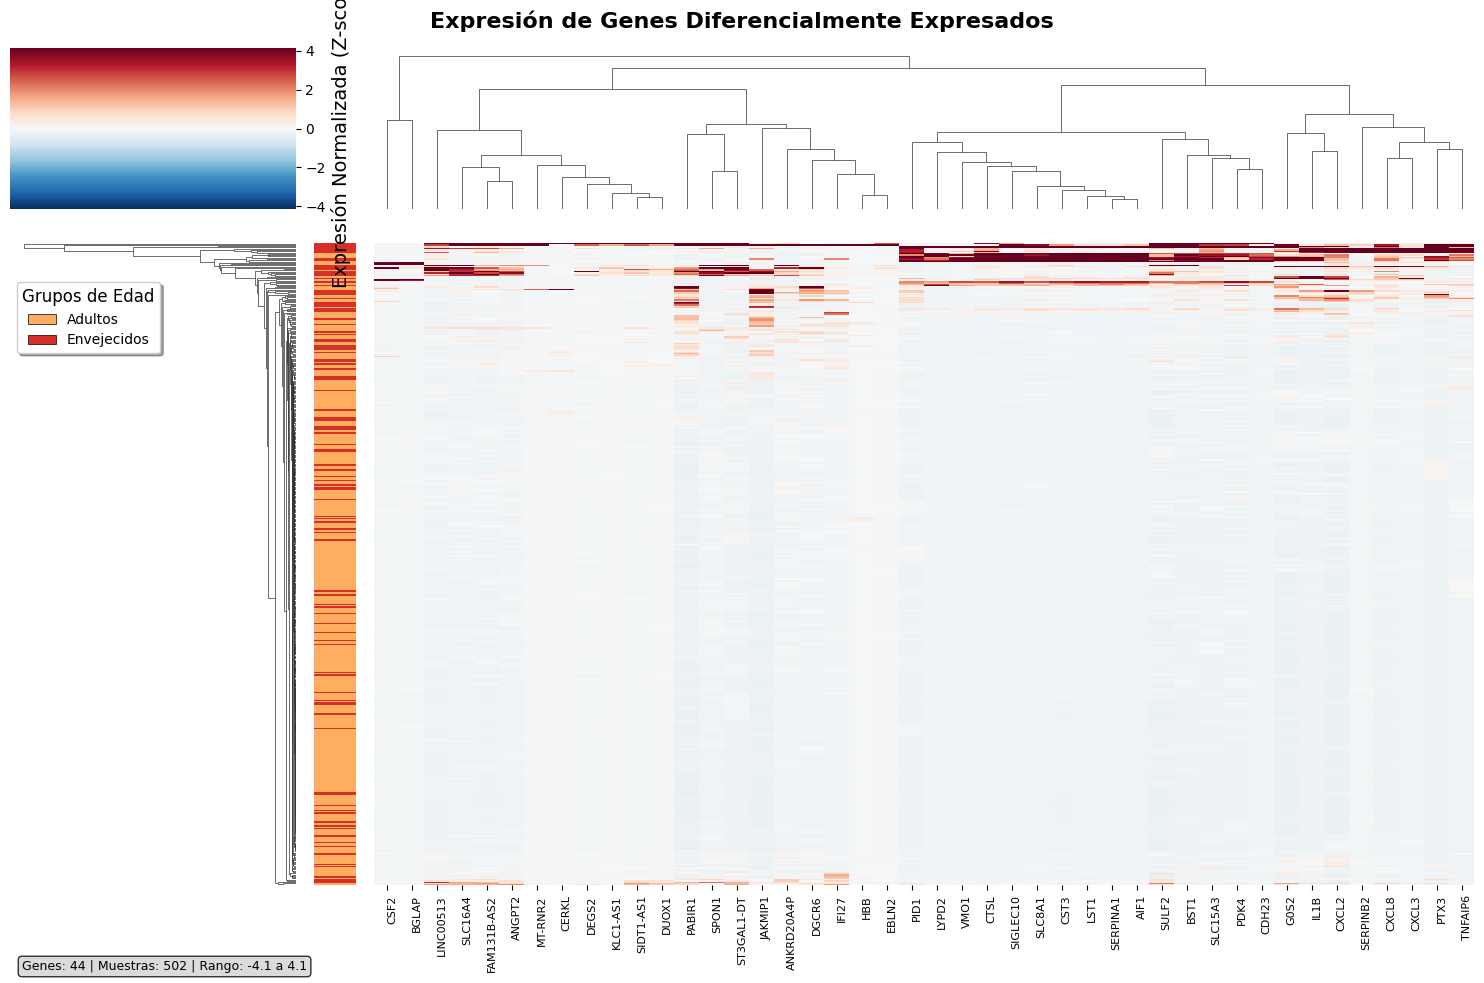

👀 Heatmap mostrado

✅ Heatmap creado exitosamente!
📊 Estadísticas finales:
   Rango de datos: -0.30 a 22.32
   Media: 0.000
   Desviación estándar: 1.001

🔧 SOLUCIONES PARA PROBLEMAS COMUNES:

1️⃣  Si el heatmap no se muestra:
   - Verificar configuración de matplotlib backend
   - Ejecutar: import matplotlib; matplotlib.use('Agg'); plt.switch_backend('inline')

2️⃣  Para instalar fastcluster (opcional, mejora rendimiento):
   - pip install fastcluster

3️⃣  Si hay problemas de memoria:
   - Reducir n_top a 40-60 genes
   - Usar la versión simplificada

4️⃣  Para forzar visualización:
   - Añadir plt.ioff() antes del heatmap
   - Usar %matplotlib inline en Jupyter

5️⃣  Uso recomendado paso a paso:

# Paso 1: Configurar matplotlib
import matplotlib.pyplot as plt
plt.ioff()  # Desactivar modo interactivo
%matplotlib inline  # En Jupyter

# Paso 2: Ejecutar heatmap
expr_data = plot_top_genes_heatmap_corrected(pb, sig_genes, n_top=60)

# Paso 3: Si falla, usar versión simple
expr_data = p

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
import scipy.sparse as sparse

def plot_top_genes_heatmap_corrected(pb, sig_genes, n_top=80):
    """
    Crear heatmap de los top genes con paleta otoñal correcta y en español
    """
    print("🔬 Creando heatmap de genes diferencialmente expresados...")
    print(f"📊 Forma de pb: {pb.shape}")
    print(f"🧬 Número de genes significativos: {len(sig_genes)}")
    
    # Configuración para presentaciones
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 12
    })
    
    # Seleccionar top genes
    top_up = sig_genes[sig_genes['log2FoldChange'] > 0].head(n_top//2).index
    top_down = sig_genes[sig_genes['log2FoldChange'] < 0].head(n_top//2).index
    top_genes = list(top_up) + list(top_down)
    
    print(f"🔝 Genes seleccionados: {len(top_genes)} ({len(top_up)} up, {len(top_down)} down)")
    
    try:
        # Obtener datos de expresión
        gene_indices = [pb.var_names.get_loc(g) for g in top_genes]
        
        if sparse.issparse(pb.X):
            expr_matrix = pb.X[:, gene_indices].toarray()
        else:
            expr_matrix = pb.X[:, gene_indices]
        
        # Crear DataFrame
        expr_data = pd.DataFrame(
            expr_matrix,
            columns=top_genes,
            index=pb.obs_names
        )
        
        # Verificar y manejar valores no finitos
        print(f"\n📋 Estadísticas antes de la limpieza:")
        print(f"   NaN valores: {expr_data.isna().sum().sum()}")
        print(f"   Inf valores: {np.isinf(expr_data).sum().sum()}")
        print(f"   Rango original: {expr_data.min().min():.2f} a {expr_data.max().max():.2f}")
        
        # Reemplazar valores no finitos
        expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
        expr_data = expr_data.fillna(expr_data.mean())
        
        # Normalizar datos (z-score por gen)
        scaler = StandardScaler()
        expr_data_scaled = pd.DataFrame(
            scaler.fit_transform(expr_data),
            columns=expr_data.columns,
            index=expr_data.index
        )
        
        print(f"📈 Rango después de scaling: {expr_data_scaled.min().min():.2f} a {expr_data_scaled.max().max():.2f}")
        
        # CORRECCIÓN 1: Paleta otoñal correcta y traducción a español
        age_color_map = {
            'young': '#1a9850',      # Verde - jóvenes
            'adult': '#fdae61',      # Naranja - adultos (CORREGIDO)
            'old': '#d73027',        # Rojo - envejecidos (CORREGIDO)
            'jóvenes': '#1a9850',    # Por si ya están traducidos
            'adultos': '#fdae61',
            'envejecidos': '#d73027'
        }
        
        # Traducir grupos de edad
        age_translation = {
            'young': 'jóvenes',
            'adult': 'adultos', 
            'old': 'envejecidos'
        }
        
        # Crear vector de colores con traducción
        age_groups = pb.obs['age_group'].astype(str)
        age_groups_es = age_groups.map(age_translation).fillna(age_groups)
        
        print(f"👥 Grupos de edad encontrados: {age_groups.unique()}")
        print(f"🇪🇸 Traducidos a: {age_groups_es.unique()}")
        
        # Crear colores para filas
        row_colors = [age_color_map.get(group, '#808080') for group in age_groups_es]
        
        # CORRECCIÓN 2: Escala centrada y robusta
        # Usar percentiles para evitar outliers extremos
        p1, p99 = np.percentile(expr_data_scaled.values, [1, 99])
        
        # Limitar rango para mejor visualización
        if abs(p99) > 5 or abs(p1) > 5:
            print(f"⚠️  Rango extremo detectado, aplicando límites robustos...")
            # Usar percentiles 5-95 para casos extremos
            p5, p95 = np.percentile(expr_data_scaled.values, [5, 95])
            max_limit = min(5, max(abs(p5), abs(p95)))  # Máximo 5, o el percentil mayor
        else:
            max_limit = max(abs(p1), abs(p99))
        
        vmin, vmax = -max_limit, max_limit
        
        print(f"🎯 Escala robusta: {vmin:.2f} a {vmax:.2f}")
        
        # CORRECCIÓN 3: Clustermap más robusto
        try:
            print("🔄 Creando clustermap...")
            
            # Cerrar figuras previas
            plt.close('all')
            
            g = sns.clustermap(
                expr_data_scaled,
                row_cluster=True,
                col_cluster=True,
                cmap='RdBu_r',          
                center=0,               
                vmin=vmin,              
                vmax=vmax,
                row_colors=row_colors,
                xticklabels=True,
                yticklabels=False,
                figsize=(15, 10),       # Tamaño más conservador
                method='average',       # Método más estable que ward
                metric='euclidean',     # Métrica explícita
                cbar_kws={
                    'label': 'Expresión Normalizada (Z-score)', 
                    'shrink': 0.7,
                    'aspect': 20
                },
                linewidths=0,           # Sin líneas para mejor rendimiento
                rasterized=True         # Rasterizar para mejor rendimiento
            )
            
            print("✅ Clustermap creado exitosamente")
            
        except Exception as e:
            print(f"❌ Error en clustermap: {e}")
            print("🔄 Intentando versión simplificada...")
            
            # Fallback: heatmap simple sin clustering
            plt.figure(figsize=(15, 10))
            
            g = sns.heatmap(
                expr_data_scaled,
                cmap='RdBu_r',
                center=0,
                vmin=vmin,
                vmax=vmax,
                xticklabels=True,
                yticklabels=False,
                cbar_kws={'label': 'Expresión Normalizada (Z-score)'}
            )
            
            # Simular estructura de clustermap para compatibilidad
            class SimpleHeatmap:
                def __init__(self, ax):
                    self.ax_heatmap = ax
                    self.fig = ax.figure
                    self.ax_row_dendrogram = ax  # Usar el mismo eje
            
            g = SimpleHeatmap(g)
        
        # CORRECCIÓN 4: Títulos y etiquetas en español (más robusto)
        try:
            g.fig.suptitle('Expresión de Genes Diferencialmente Expresados', 
                           y=0.98, fontsize=16, fontweight='bold')
            
            # Mejorar etiquetas de genes con manejo de errores
            if hasattr(g, 'ax_heatmap'):
                ax_heatmap = g.ax_heatmap
                
                # Rotar etiquetas con mejor configuración
                plt.setp(ax_heatmap.get_xticklabels(), 
                        rotation=90, ha='right', fontsize=8, rotation_mode='anchor')
                
                # Configurar eje Y
                ax_heatmap.set_ylabel('')  # Limpiar etiqueta Y
                
            print("✅ Títulos y etiquetas configurados")
            
        except Exception as e:
            print(f"⚠️  Error en configuración de títulos: {e}")
        
        # CORRECCIÓN 5: Leyenda en español con colores correctos (más robusta)
        try:
            unique_groups_es = age_groups_es.unique()
            legend_elements = []
            
            grupo_orden = ['adultos', 'envejecidos']  # Solo los que tenemos
            
            for group in grupo_orden:
                if group in unique_groups_es:
                    legend_elements.append(
                        Patch(facecolor=age_color_map[group], 
                             edgecolor='black', linewidth=0.5,
                             label=group.title())
                    )
            
            # Posicionar leyenda de forma más robusta
            if hasattr(g, 'ax_row_dendrogram') and legend_elements:
                g.ax_row_dendrogram.legend(
                    handles=legend_elements, 
                    title='Grupos de Edad',
                    bbox_to_anchor=(0, 0.95),
                    loc='upper left',
                    frameon=True,
                    fancybox=True,
                    shadow=True,
                    fontsize=10
                )
            
            print("✅ Leyenda configurada")
            
        except Exception as e:
            print(f"⚠️  Error en leyenda: {e}")
        
        # CORRECCIÓN 6: Colorbar mejorado
        try:
            if hasattr(g, 'ax_heatmap'):
                # Encontrar la colorbar
                for child in g.fig.get_children():
                    if hasattr(child, 'colorbar'):
                        cbar = child.colorbar
                        cbar.set_label('Expresión Normalizada (Z-score)', 
                                      rotation=270, labelpad=15, fontweight='bold')
                        break
            
            print("✅ Colorbar configurado")
            
        except Exception as e:
            print(f"⚠️  Error en colorbar: {e}")
        
        # CORRECCIÓN 7: Información adicional y guardado robusto
        try:
            info_text = f'Genes: {len(top_genes)} | Muestras: {expr_data_scaled.shape[0]} | Rango: {vmin:.1f} a {vmax:.1f}'
            g.fig.text(0.02, 0.02, info_text, fontsize=9, 
                      bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.8))
            
            print("✅ Información añadida")
            
        except Exception as e:
            print(f"⚠️  Error añadiendo información: {e}")
        
        # Ajustar layout
        try:
            plt.tight_layout()
            print("✅ Layout ajustado")
        except Exception as e:
            print(f"⚠️  Error en layout: {e}")
        
        # Guardar con manejo de errores
        try:
            output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_genes_DE_corregido.png'
            g.fig.savefig(output_path, dpi=300, bbox_inches='tight', 
                         facecolor='white', edgecolor='none')
            print(f"💾 Heatmap guardado en: {output_path}")
        except Exception as e:
            print(f"⚠️  Error guardando: {e}")
        
        # Mostrar con configuración explícita
        try:
            plt.show()
            print("👀 Heatmap mostrado")
        except Exception as e:
            print(f"⚠️  Error mostrando: {e}")
            
        # NO cerrar la figura inmediatamente para permitir visualización
        # plt.close() - Comentado para debugging
        
        # Estadísticas finales
        print(f"\n✅ Heatmap creado exitosamente!")
        print(f"📊 Estadísticas finales:")
        print(f"   Rango de datos: {expr_data_scaled.min().min():.2f} a {expr_data_scaled.max().max():.2f}")
        print(f"   Media: {expr_data_scaled.mean().mean():.3f}")
        print(f"   Desviación estándar: {expr_data_scaled.std().mean():.3f}")
        
        return expr_data_scaled
        
    except Exception as e:
        print(f"❌ Error durante la creación del heatmap: {str(e)}")
        print("🔍 Detalles adicionales:")
        import traceback
        print(traceback.format_exc())
        return None

# FUNCIÓN ADICIONAL: Verificar datos antes del heatmap
def verify_heatmap_data(pb, sig_genes):
    """
    Verificar datos antes de crear el heatmap
    """
    print("🔍 VERIFICACIÓN DE DATOS PARA HEATMAP")
    print("=" * 50)
    
    print(f"📊 Pseudobulk shape: {pb.shape}")
    print(f"🧬 Genes significativos: {len(sig_genes)}")
    
    if 'age_group' in pb.obs.columns:
        print(f"👥 Grupos de edad: {pb.obs['age_group'].value_counts().to_dict()}")
    else:
        print("❌ No se encontró columna 'age_group'")
    
    # Verificar genes en el objeto
    available_genes = set(pb.var_names)
    sig_gene_names = set(sig_genes.index)
    missing_genes = sig_gene_names - available_genes
    
    print(f"🎯 Genes disponibles en pb: {len(available_genes)}")
    print(f"📝 Genes significativos solicitados: {len(sig_gene_names)}")
    print(f"❓ Genes faltantes: {len(missing_genes)}")
    
    if missing_genes:
        print(f"⚠️  Primeros genes faltantes: {list(missing_genes)[:5]}")
    
    return len(missing_genes) == 0

# FUNCIÓN ALTERNATIVA SIMPLE EN CASO DE PROBLEMAS
def plot_simple_heatmap_backup(pb, sig_genes, n_top=80):
    """
    Versión simplificada del heatmap sin clustering para casos problemáticos
    """
    print("🛠️  Creando heatmap simplificado (sin clustering)...")
    
    # Configuración básica
    plt.rcParams.update({'font.size': 12})
    
    # Seleccionar genes
    top_up = sig_genes[sig_genes['log2FoldChange'] > 0].head(n_top//2).index
    top_down = sig_genes[sig_genes['log2FoldChange'] < 0].head(n_top//2).index
    top_genes = list(top_up) + list(top_down)
    
    # Obtener datos
    gene_indices = [pb.var_names.get_loc(g) for g in top_genes]
    
    if sparse.issparse(pb.X):
        expr_matrix = pb.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb.X[:, gene_indices]
    
    expr_data = pd.DataFrame(expr_matrix, columns=top_genes, index=pb.obs_names)
    
    # Normalizar
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    expr_data_scaled = pd.DataFrame(
        scaler.fit_transform(expr_data),
        columns=expr_data.columns,
        index=expr_data.index
    )
    
    # Limitar rango
    p5, p95 = np.percentile(expr_data_scaled.values, [5, 95])
    max_limit = min(4, max(abs(p5), abs(p95)))
    vmin, vmax = -max_limit, max_limit
    
    # Crear heatmap simple
    plt.figure(figsize=(14, 8))
    
    # Ordenar por grupos de edad
    age_order = pb.obs.sort_values('age_group')
    expr_ordered = expr_data_scaled.loc[age_order.index]
    
    # Crear heatmap
    ax = sns.heatmap(
        expr_ordered.T,  # Transponer para genes en filas
        cmap='RdBu_r',
        center=0,
        vmin=vmin,
        vmax=vmax,
        xticklabels=False,  # Sin etiquetas de muestras
        yticklabels=True,   # Etiquetas de genes
        cbar_kws={'label': 'Expresión Normalizada (Z-score)'}
    )
    
    # Configurar
    ax.set_title('Expresión de Genes Diferencialmente Expresados\n(Versión Simplificada)', 
                fontweight='bold', pad=20)
    ax.set_xlabel('Muestras (Ordenadas por Edad)', fontweight='bold')
    ax.set_ylabel('Genes', fontweight='bold')
    
    # Añadir separador visual entre grupos
    age_groups = age_order['age_group']
    adult_count = (age_groups == 'adult').sum()
    
    if adult_count > 0:
        ax.axvline(x=adult_count, color='black', linewidth=2, alpha=0.7)
        ax.text(adult_count/2, -5, 'Adultos', ha='center', fontweight='bold')
        ax.text(adult_count + (len(age_groups) - adult_count)/2, -5, 
               'Envejecidos', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return expr_data_scaled

# Ejecutar con verificación previa y fallback
print("🎨 HEATMAP CORREGIDO - PALETA OTOÑAL Y ESPAÑOL")
print("=" * 60)

# Verificar datos primero
if verify_heatmap_data(pb, sig_genes):
    print("\n✅ Datos verificados, procediendo con heatmap...")
    
    try:
        expr_data = plot_top_genes_heatmap_corrected(pb, sig_genes, n_top=80)
        
        if expr_data is None:
            print("\n🔄 Fallback: Intentando heatmap simplificado...")
            expr_data = plot_simple_heatmap_backup(pb, sig_genes, n_top=80)
            
    except Exception as e:
        print(f"\n❌ Error en heatmap principal: {e}")
        print("🔄 Usando versión simplificada...")
        expr_data = plot_simple_heatmap_backup(pb, sig_genes, n_top=80)
        
# INSTRUCCIONES ADICIONALES PARA SOLUCIONAR PROBLEMAS DE VISUALIZACIÓN

print("\n" + "="*60)
print("🔧 SOLUCIONES PARA PROBLEMAS COMUNES:")
print("="*60)

print("\n1️⃣  Si el heatmap no se muestra:")
print("   - Verificar configuración de matplotlib backend")
print("   - Ejecutar: import matplotlib; matplotlib.use('Agg'); plt.switch_backend('inline')")

print("\n2️⃣  Para instalar fastcluster (opcional, mejora rendimiento):")
print("   - pip install fastcluster")

print("\n3️⃣  Si hay problemas de memoria:")
print("   - Reducir n_top a 40-60 genes")
print("   - Usar la versión simplificada")

print("\n4️⃣  Para forzar visualización:")
print("   - Añadir plt.ioff() antes del heatmap")
print("   - Usar %matplotlib inline en Jupyter")

print("\n5️⃣  Uso recomendado paso a paso:")
print("""
# Paso 1: Configurar matplotlib
import matplotlib.pyplot as plt
plt.ioff()  # Desactivar modo interactivo
%matplotlib inline  # En Jupyter

# Paso 2: Ejecutar heatmap
expr_data = plot_top_genes_heatmap_corrected(pb, sig_genes, n_top=60)

# Paso 3: Si falla, usar versión simple
expr_data = plot_simple_heatmap_backup(pb, sig_genes, n_top=60)
""")

print("="*60)

🧬 GENERANDO HEATMAPS MEJORADOS PARA ANÁLISIS DE ENVEJECIMIENTO 🧬

1️⃣ Generando heatmap principal con clustering...
=== ANÁLISIS DE HEATMAP PARA ENVEJECIMIENTO ===
Forma de datos: (502, 6745)
Genes significativos disponibles: 48

--- Selección de Genes ---
Genes sobreexpresados seleccionados: 40
Genes subexpresados seleccionados: 4
Genes encontrados en datos: 44

--- Distribución de Grupos ---
age_group
adultos        384
envejecidos    118
Name: count, dtype: int64

--- Procesamiento de Datos ---
Método de normalización: Log2(x+1)
Rango después de normalización: -3.21 a 9.18
Grupos únicos encontrados: ['envejecidos' 'adultos']

--- Heatmap guardado en: /app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_genes_DE_mejorado.png ---


<Figure size 1600x1200 with 0 Axes>

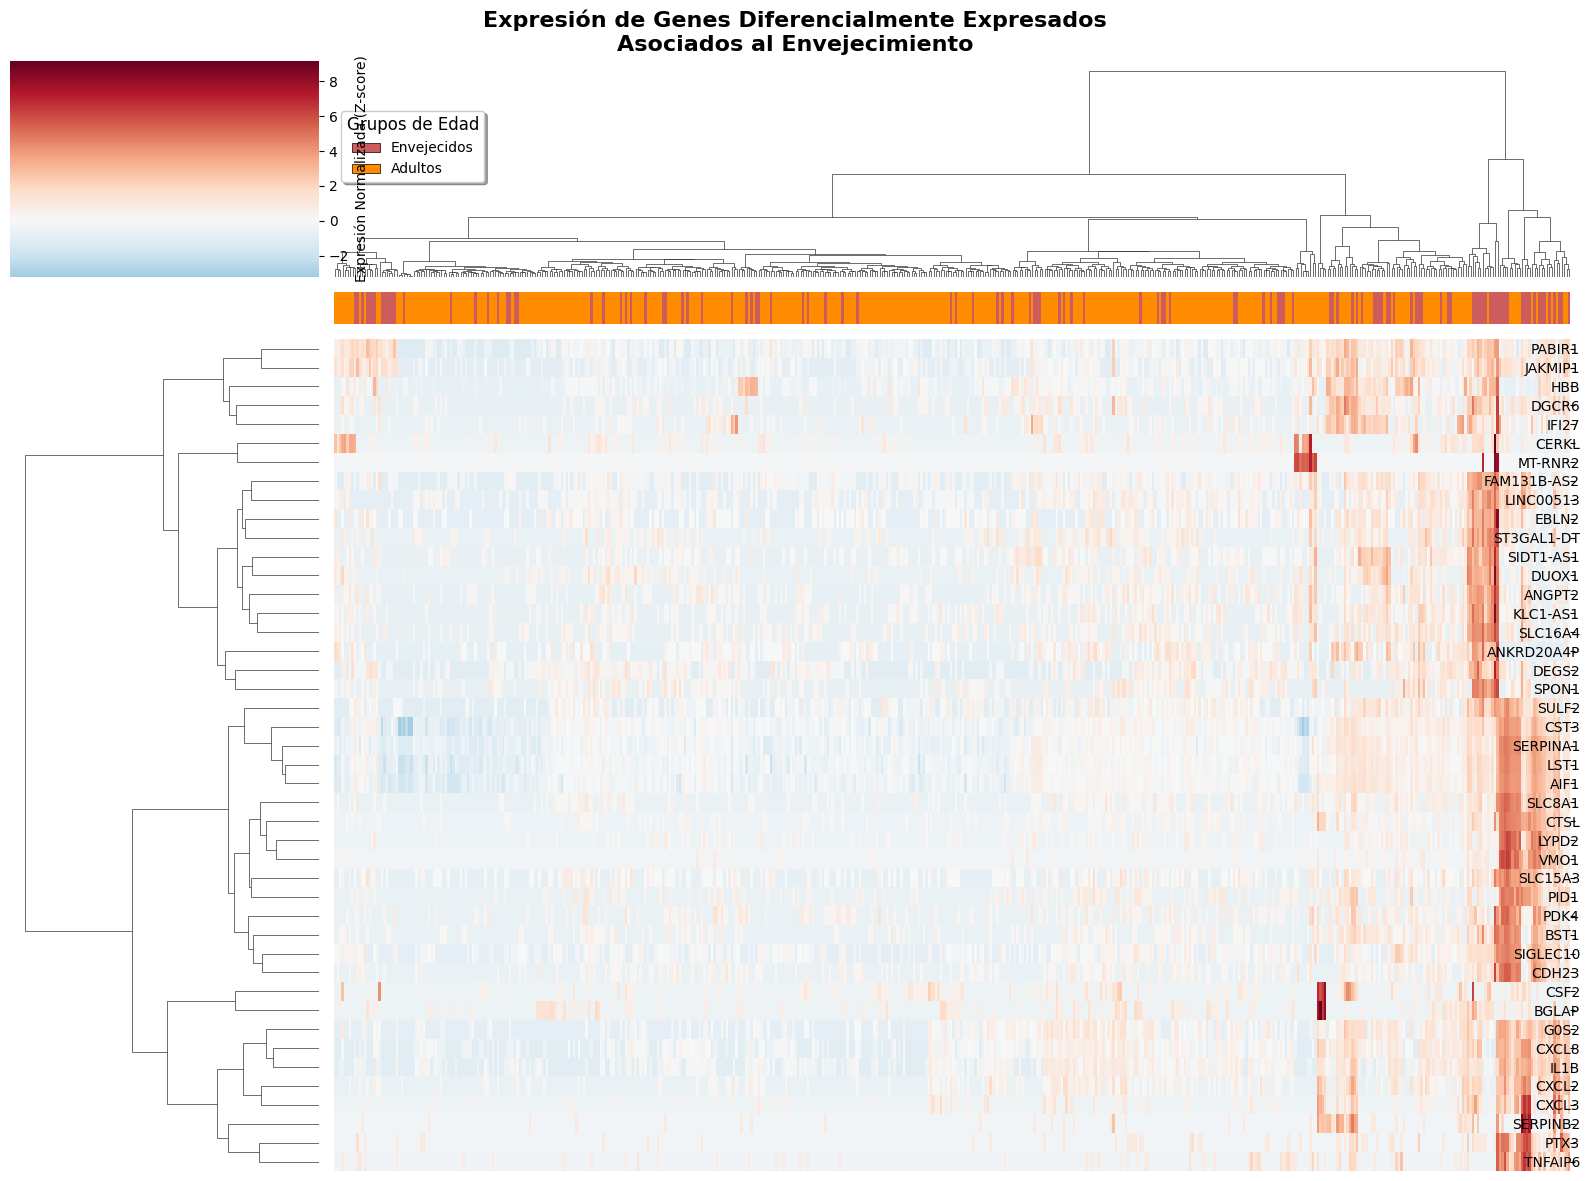



2️⃣ Generando heatmap simplificado...

=== HEATMAP SIMPLIFICADO ===
Genes disponibles para visualización: 4
Heatmap simplificado guardado en: /app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_simplified_mejorado.png


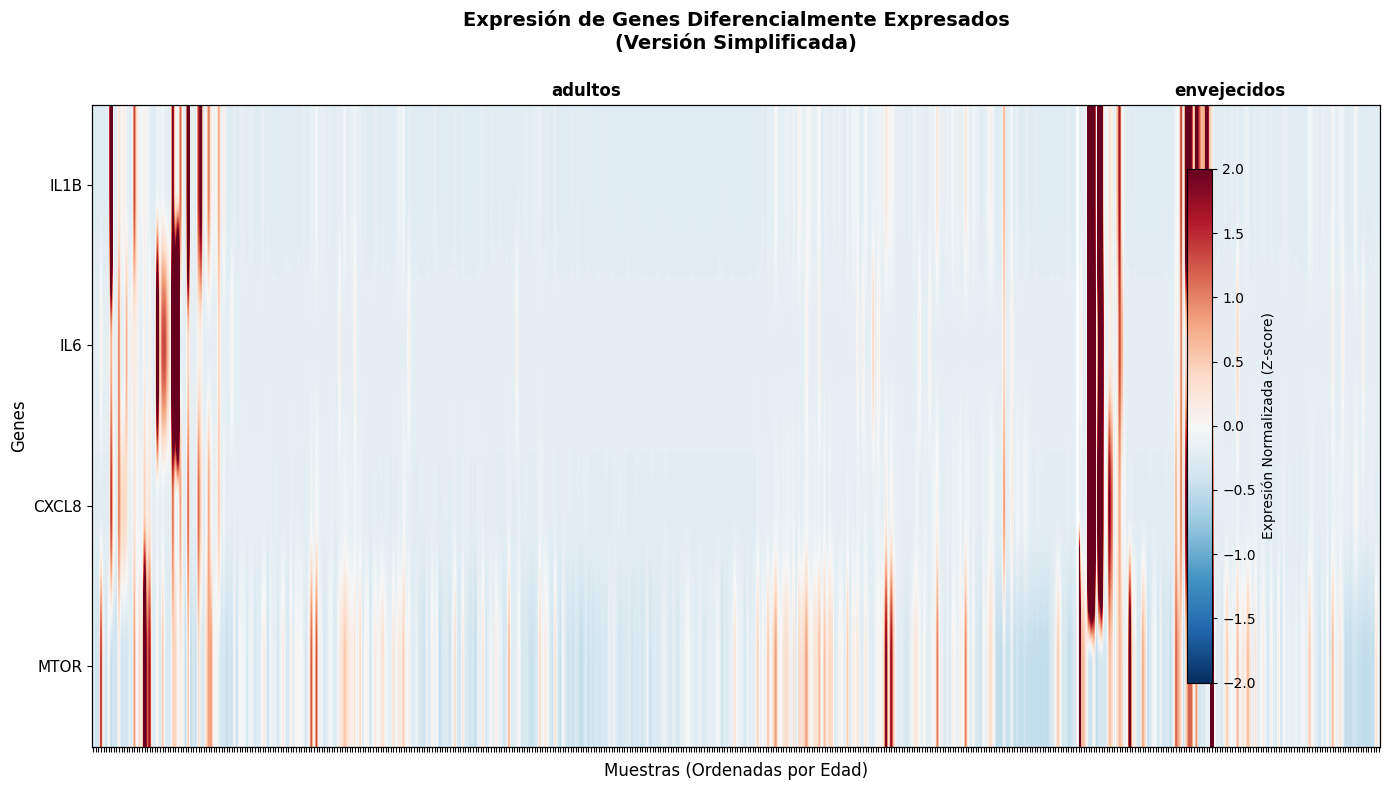


✅ ANÁLISIS COMPLETADO
📊 Se generaron dos visualizaciones optimizadas para presentación
🎨 Paleta de colores consistente aplicada
📝 Textos en español y tamaños optimizados


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import sparse
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

def plot_improved_aging_heatmap(pb, sig_genes, n_top=80, figsize=(16, 12)):
    """
    Crear heatmap mejorado para análisis de envejecimiento con paleta consistente
    """
    print("=== ANÁLISIS DE HEATMAP PARA ENVEJECIMIENTO ===")
    print(f"Forma de datos: {pb.shape}")
    print(f"Genes significativos disponibles: {len(sig_genes)}")
    
    # Paleta de colores consistente para envejecimiento
    AGING_COLORS = {
        'young': '#2E8B57',      # Verde bosque para jóvenes
        'jóvenes': '#2E8B57',
        'adult': '#FF8C00',      # Naranja para adultos
        'adultos': '#FF8C00', 
        'old': '#CD5C5C',        # Rojo para envejecidos
        'envejecidos': '#CD5C5C'
    }
    
    # Selección inteligente de genes
    print("\n--- Selección de Genes ---")
    
    # Separar genes up y down regulados
    up_genes = sig_genes[sig_genes['log2FoldChange'] > 0].copy()
    down_genes = sig_genes[sig_genes['log2FoldChange'] < 0].copy()
    
    # Seleccionar por significancia y fold change
    up_genes = up_genes.sort_values(['padj', 'log2FoldChange'], ascending=[True, False])
    down_genes = down_genes.sort_values(['padj', 'log2FoldChange'], ascending=[True, True])
    
    n_each = n_top // 2
    top_up = up_genes.head(n_each).index.tolist()
    top_down = down_genes.head(n_each).index.tolist()
    top_genes = top_up + top_down
    
    print(f"Genes sobreexpresados seleccionados: {len(top_up)}")
    print(f"Genes subexpresados seleccionados: {len(top_down)}")
    
    # Extraer datos de expresión
    try:
        gene_indices = [pb.var_names.get_loc(g) for g in top_genes if g in pb.var_names]
        available_genes = [g for g in top_genes if g in pb.var_names]
        
        print(f"Genes encontrados en datos: {len(available_genes)}")
        
        if sparse.issparse(pb.X):
            expr_matrix = pb.X[:, gene_indices].toarray()
        else:
            expr_matrix = pb.X[:, gene_indices]
        
        # Crear DataFrame con mejor manejo de datos
        expr_data = pd.DataFrame(
            expr_matrix,
            columns=available_genes,
            index=pb.obs_names
        )
        
        # Información de grupos de edad
        age_groups = pb.obs['age_group'].copy()
        
        # Estandarizar nombres de grupos
        age_mapping = {
            'young': 'jóvenes',
            'adult': 'adultos', 
            'old': 'envejecidos'
        }
        age_groups = age_groups.map(age_mapping).fillna(age_groups)
        
        print(f"\n--- Distribución de Grupos ---")
        print(age_groups.value_counts())
        
    except Exception as e:
        print(f"Error extrayendo datos: {e}")
        return None
    
    # Limpieza y normalización de datos
    print("\n--- Procesamiento de Datos ---")
    
    # Manejar valores no finitos
    expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
    
    # Verificar NaN
    nan_count = expr_data.isna().sum().sum()
    if nan_count > 0:
        print(f"Valores NaN encontrados: {nan_count}, rellenando con mediana por gen")
        expr_data = expr_data.fillna(expr_data.median())
    
    # OPCIÓN 1: Normalización menos agresiva (preserva más rango dinámico)
    # Usar log2(x + 1) si los datos no están ya en log
    if expr_data.max().max() > 20:  # Probablemente datos raw
        expr_data_norm = np.log2(expr_data + 1)
        normalization_method = "Log2(x+1)"
    else:
        expr_data_norm = expr_data.copy()
        normalization_method = "Datos ya normalizados"
    
    # OPCIÓN 2: Z-score por gen (menos agresivo que z-score global)
    expr_data_zscore = expr_data_norm.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    print(f"Método de normalización: {normalization_method}")
    print(f"Rango después de normalización: {expr_data_zscore.min().min():.2f} a {expr_data_zscore.max().max():.2f}")
    
    # Crear colores para filas
    unique_groups = age_groups.unique()
    print(f"Grupos únicos encontrados: {unique_groups}")
    
    row_colors = [AGING_COLORS.get(group, '#808080') for group in age_groups]
    
    # === CREAR HEATMAP PRINCIPAL ===
    plt.style.use('default')  # Reset style
    
    fig = plt.figure(figsize=figsize)
    
    # Crear clustermap con parámetros optimizados
    g = sns.clustermap(
        expr_data_zscore.T,  # Transponer para genes en filas
        row_cluster=True,     # Cluster genes
        col_cluster=True,     # Cluster muestras
        cmap='RdBu_r',       # Mapa de colores divergente
        center=0,            # Centrar en 0
        col_colors=row_colors, # Colores por grupo de edad
        xticklabels=False,   # No mostrar nombres de muestras
        yticklabels=True,    # Mostrar nombres de genes
        figsize=figsize,
        method='ward',       # Método de clustering
        metric='euclidean',  # Métrica de distancia
        cbar_kws={
            'label': 'Expresión Normalizada (Z-score)',
            'shrink': 0.8
        },
        linewidths=0,
        rasterized=True
    )
    
    # Configurar texto y etiquetas
    plt.setp(g.ax_heatmap.get_yticklabels(), 
             rotation=0, 
             fontsize=10,
             ha='right')
    
    # Título principal
    g.fig.suptitle(
        'Expresión de Genes Diferencialmente Expresados\nAsociados al Envejecimiento', 
        fontsize=16, 
        fontweight='bold',
        y=0.98
    )
    
    # Crear leyenda mejorada para grupos de edad
    legend_elements = []
    for group in unique_groups:
        if group in AGING_COLORS:
            legend_elements.append(
                Patch(facecolor=AGING_COLORS[group], 
                     label=group.capitalize(),
                     edgecolor='black',
                     linewidth=0.5)
            )
    
    # Posicionar leyenda
    g.ax_col_dendrogram.legend(
        handles=legend_elements,
        title='Grupos de Edad',
        title_fontsize=12,
        fontsize=10,
        bbox_to_anchor=(0, 0.8),
        loc='upper left',
        frameon=True,
        fancybox=True,
        shadow=True
    )
    
    # Ajustar layout
    plt.tight_layout()
    
    # Guardar con alta resolución
    output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_genes_DE_mejorado.png'
    plt.savefig(output_path, 
                dpi=300, 
                bbox_inches='tight',
                facecolor='white',
                edgecolor='none')
    
    print(f"\n--- Heatmap guardado en: {output_path} ---")
    plt.show()
    
    return expr_data_zscore, expr_data_norm

def create_simplified_heatmap(pb, sig_genes, selected_genes=None, figsize=(14, 8)):
    """
    Crear heatmap simplificado sin clustering para genes específicos
    """
    print("\n=== HEATMAP SIMPLIFICADO ===")
    
    # Paleta consistente
    AGING_COLORS = {
        'young': '#2E8B57', 'jóvenes': '#2E8B57',
        'adult': '#FF8C00', 'adultos': '#FF8C00', 
        'old': '#CD5C5C', 'envejecidos': '#CD5C5C'
    }
    
    # Genes específicos de interés (puedes personalizar esta lista)
    if selected_genes is None:
        # Seleccionar genes representativos por categorías funcionales
        selected_genes = [
            # Genes de inmunoglobulinas
            'IGHV3-74', 'IGHV3-15', 'IGLV1-44', 'IGKV3-20',
            # Genes inflamatorios
            'IL1B', 'TNF', 'IL6', 'CXCL8',
            # Genes de envejecimiento
            'CDKN1A', 'TP53', 'LMNA', 'TERT',
            # Genes metabólicos
            'PPARG', 'SIRT1', 'FOXO1', 'MTOR'
        ]
    
    # Filtrar genes disponibles
    available_genes = [g for g in selected_genes if g in pb.var_names]
    print(f"Genes disponibles para visualización: {len(available_genes)}")
    
    if len(available_genes) == 0:
        print("No se encontraron genes específicos, usando top DE genes")
        top_genes = sig_genes.head(20).index.tolist()
        available_genes = [g for g in top_genes if g in pb.var_names]
    
    # Extraer datos
    gene_indices = [pb.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb.X):
        expr_matrix = pb.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb.X[:, gene_indices]
    
    expr_data = pd.DataFrame(
        expr_matrix,
        columns=available_genes,
        index=pb.obs_names
    )
    
    # Normalizar
    expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
    expr_data = expr_data.fillna(expr_data.median())
    
    # Z-score por gen
    expr_data_norm = expr_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Preparar grupos de edad
    age_groups = pb.obs['age_group'].copy()
    age_mapping = {'young': 'jóvenes', 'adult': 'adultos', 'old': 'envejecidos'}
    age_groups = age_groups.map(age_mapping).fillna(age_groups)
    
    # Ordenar por grupo de edad
    sort_order = ['jóvenes', 'adultos', 'envejecidos']
    available_groups = [g for g in sort_order if g in age_groups.values]
    
    sorted_indices = []
    for group in available_groups:
        group_indices = age_groups[age_groups == group].index
        sorted_indices.extend(group_indices)
    
    expr_sorted = expr_data_norm.loc[sorted_indices]
    groups_sorted = age_groups.loc[sorted_indices]
    
    # Crear figura
    fig, ax = plt.subplots(figsize=figsize)
    
    # Crear heatmap
    im = ax.imshow(
        expr_sorted.T, 
        cmap='RdBu_r', 
        aspect='auto',
        vmin=-2, vmax=2
    )
    
    # Configurar ejes
    ax.set_xticks(range(len(expr_sorted)))
    ax.set_xticklabels([])  # Sin etiquetas de muestras
    
    ax.set_yticks(range(len(available_genes)))
    ax.set_yticklabels(available_genes, fontsize=11)
    
    # Añadir separadores entre grupos
    group_changes = []
    current_group = groups_sorted.iloc[0]
    
    for i, group in enumerate(groups_sorted):
        if group != current_group:
            group_changes.append(i)
            current_group = group
    
    for change_point in group_changes:
        ax.axvline(x=change_point - 0.5, color='white', linewidth=2)
    
    # Añadir etiquetas de grupos
    group_positions = []
    group_labels = []
    
    start_pos = 0
    for group in available_groups:
        group_size = (groups_sorted == group).sum()
        end_pos = start_pos + group_size
        group_positions.append(start_pos + group_size/2)
        group_labels.append(group)
        start_pos = end_pos
    
    # Crear eje secundario para etiquetas de grupos
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(group_positions)
    ax2.set_xticklabels(group_labels, fontsize=12, fontweight='bold')
    ax2.tick_params(length=0)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Expresión Normalizada (Z-score)', fontsize=10)
    
    # Título
    ax.set_title('Expresión de Genes Diferencialmente Expresados\n(Versión Simplificada)', 
                fontsize=14, fontweight='bold', pad=40)
    
    ax.set_xlabel('Muestras (Ordenadas por Edad)', fontsize=12)
    ax.set_ylabel('Genes', fontsize=12)
    
    plt.tight_layout()
    
    # Guardar
    output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_simplified_mejorado.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    print(f"Heatmap simplificado guardado en: {output_path}")
    plt.show()
    
    return expr_sorted

# Función principal de ejecución
def run_improved_heatmaps(pb, sig_genes):
    """
    Ejecutar ambos tipos de heatmaps mejorados
    """
    print("🧬 GENERANDO HEATMAPS MEJORADOS PARA ANÁLISIS DE ENVEJECIMIENTO 🧬\n")
    
    try:
        # Heatmap principal con clustering
        print("1️⃣ Generando heatmap principal con clustering...")
        expr_zscore, expr_norm = plot_improved_aging_heatmap(pb, sig_genes, n_top=80)
        
        print("\n" + "="*60 + "\n")
        
        # Heatmap simplificado
        print("2️⃣ Generando heatmap simplificado...")
        expr_sorted = create_simplified_heatmap(pb, sig_genes)
        
        print("\n✅ ANÁLISIS COMPLETADO")
        print("📊 Se generaron dos visualizaciones optimizadas para presentación")
        print("🎨 Paleta de colores consistente aplicada")
        print("📝 Textos en español y tamaños optimizados")
        
        return expr_zscore, expr_sorted
        
    except Exception as e:
        print(f"❌ Error durante la generación: {e}")
        import traceback
        print(traceback.format_exc())
        return None, None

# Ejecutar
expr_zscore, expr_sorted = run_improved_heatmaps(pb, sig_genes)

🎯 ANÁLISIS COMPLETO BASADO EN EDAD NUMÉRICA
🔍 ANÁLISIS DE DATOS DE EDAD
Total de muestras: 502
Valores únicos de edad: 46
Valores no nulos: 446
Valores faltantes: 56

⚠️  Columna age_yrs no es numérica, intentando conversión...
Valores únicos encontrados:
  '75' (tipo: <class 'int'>)
  '49' (tipo: <class 'int'>)
  '36' (tipo: <class 'int'>)
  '48' (tipo: <class 'int'>)
  '37' (tipo: <class 'int'>)
  '63' (tipo: <class 'int'>)
  '67' (tipo: <class 'int'>)
  '54' (tipo: <class 'int'>)
  '70' (tipo: <class 'int'>)
  '73' (tipo: <class 'int'>)
Después de conversión:
  Valores convertidos exitosamente: 446
  Valores que no se pudieron convertir: 56

📊 ESTADÍSTICAS DE EDAD:
  Edad mínima: 35.0
  Edad máxima: 89.0
  Edad promedio: 50.3
  Edad mediana: 48.0
  Desviación estándar: 10.8

📈 DISTRIBUCIÓN DE EDADES:
  35-46 años: 173 muestras
  46-57 años: 144 muestras
  57-67 años: 97 muestras
  67-78 años: 29 muestras
  78-89 años: 3 muestras


🎨 GENERANDO HEATMAP ORDENADO POR EDAD...
🧬 GENERANDO

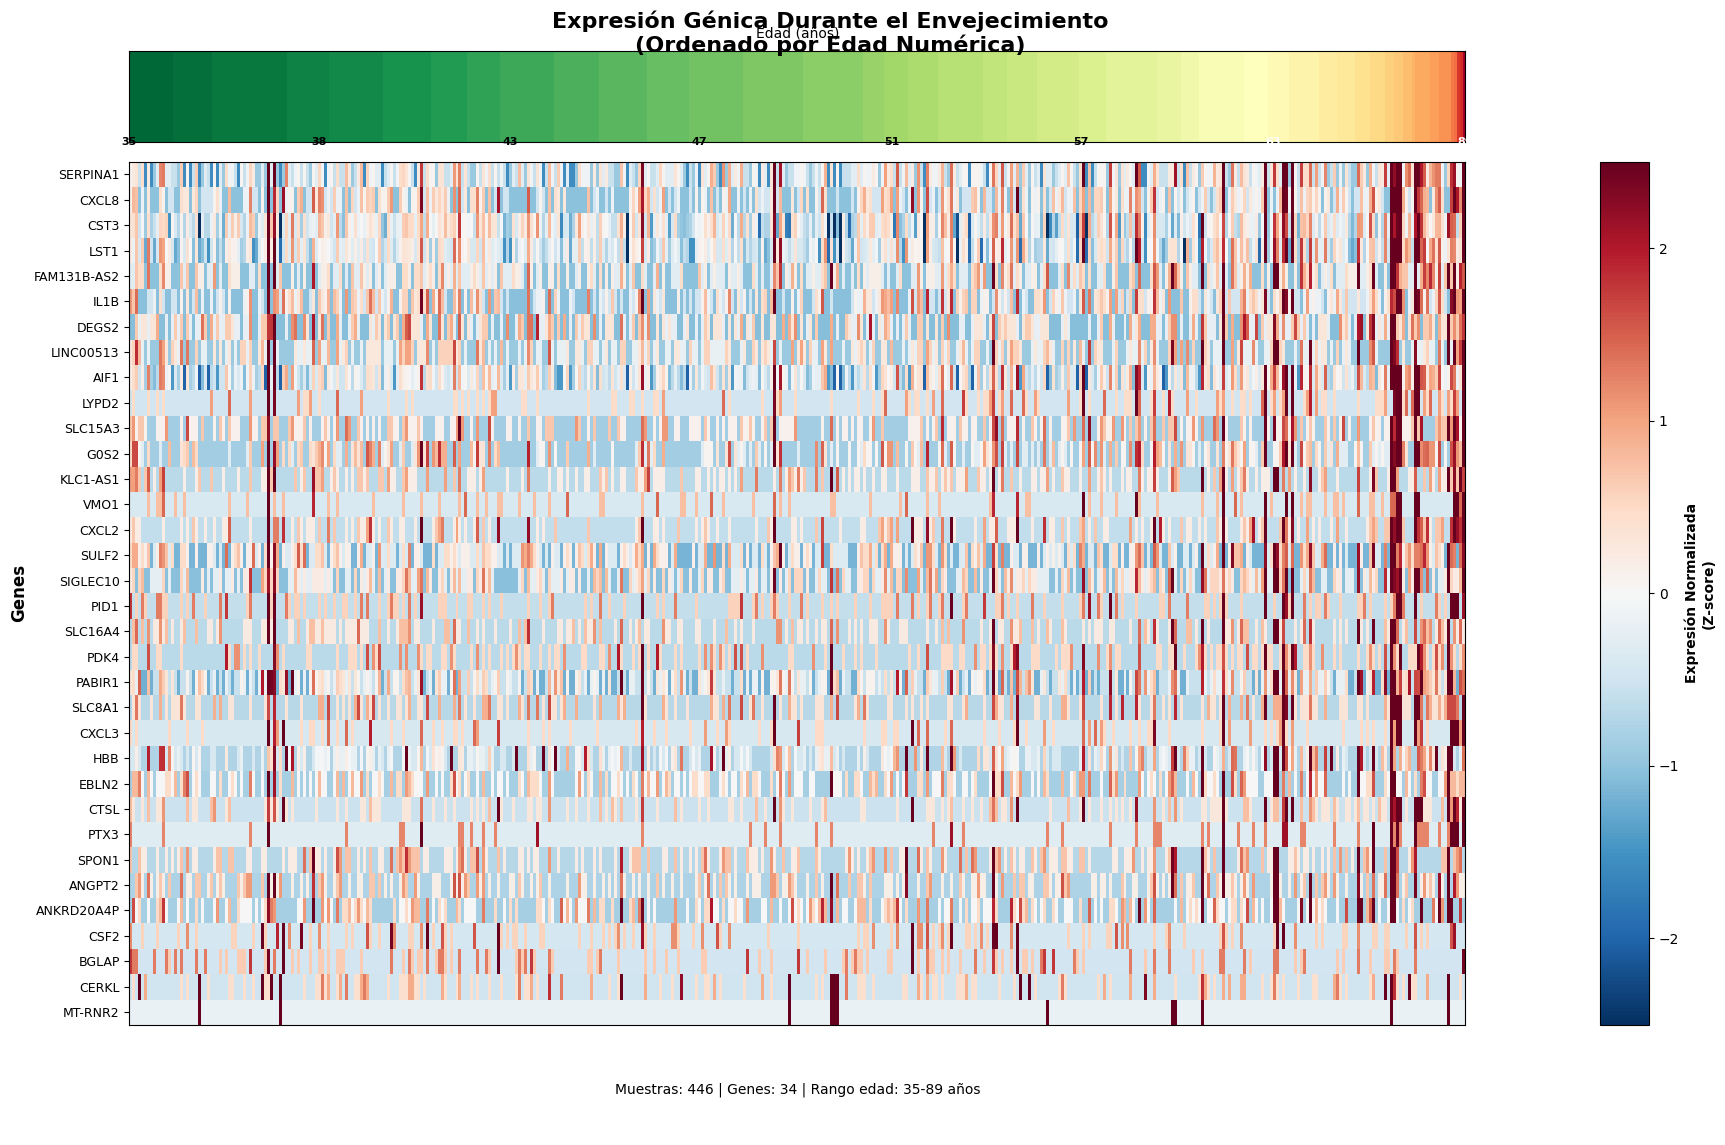



📈 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN...

📊 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN
❌ Error durante el análisis: single positional indexer is out-of-bounds
Traceback (most recent call last):
  File "/tmp/ipykernel_6059/1597581916.py", line 378, in run_age_numeric_analysis
    corr_results = plot_age_correlation_analysis(pb, sig_genes)
  File "/tmp/ipykernel_6059/1597581916.py", line 331, in plot_age_correlation_analysis
    top_neg_gene = corr_df[corr_df['Correlacion_Edad'] < 0].iloc[0]['Gene']
  File "/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pandas/core/indexing.py", line 1192, in __getitem__
    return self._getitem_axis(maybe_callable, axis=axis)
  File "/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pandas/core/indexing.py", line 1753, in _getitem_axis
    self._validate_integer(key, axis)
  File "/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pandas/core/indexing.py", line 1686, in _validate_integer
    raise IndexError("single positional index

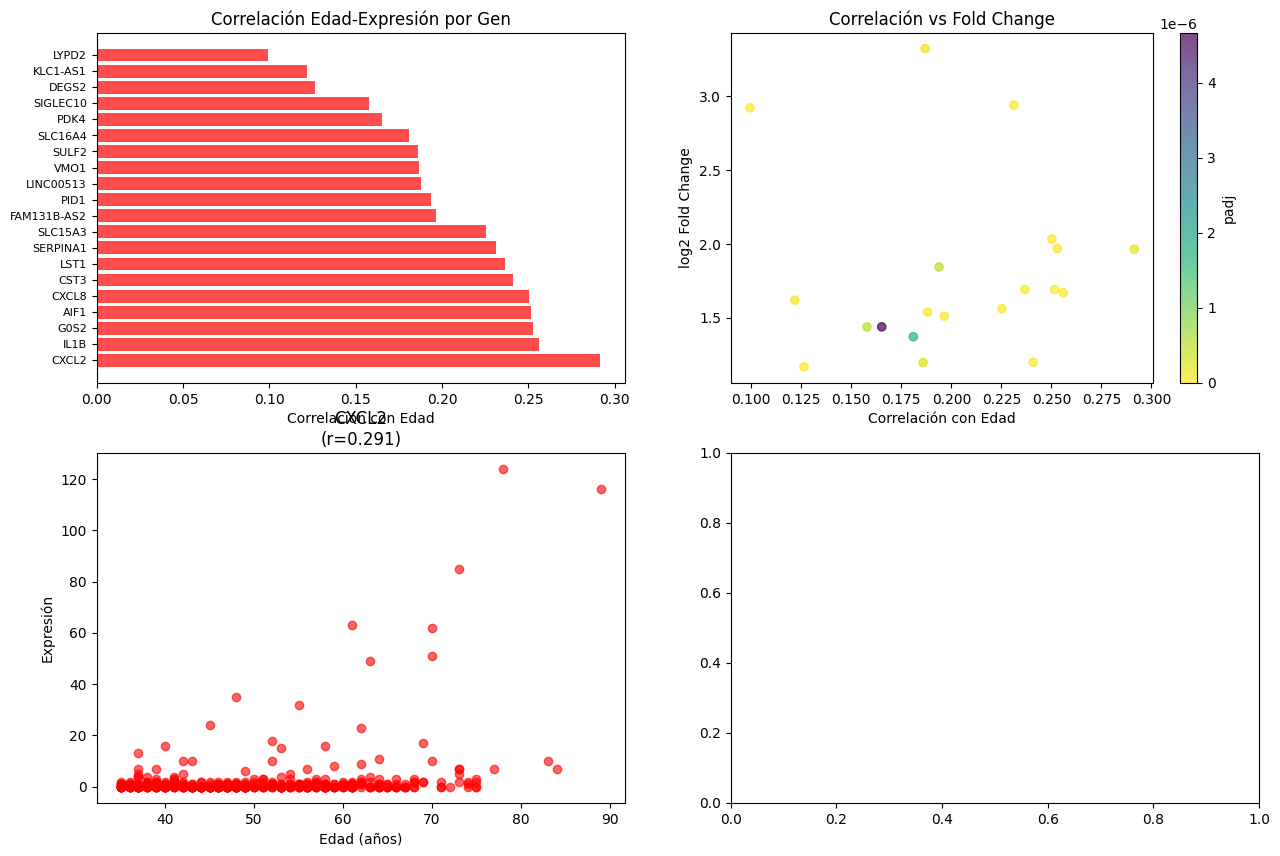

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

def analyze_age_data(pb):
    """
    Analizar los datos de edad disponibles
    """
    print("🔍 ANÁLISIS DE DATOS DE EDAD")
    print("=" * 50)
    
    # Verificar columna de edad
    if 'age_yrs' not in pb.obs.columns:
        print("❌ No se encontró columna 'age_yrs'")
        print("Columnas disponibles:", pb.obs.columns.tolist())
        return None
    
    age_data = pb.obs['age_yrs'].copy()
    
    # Estadísticas básicas
    print(f"Total de muestras: {len(age_data)}")
    print(f"Valores únicos de edad: {age_data.nunique()}")
    print(f"Valores no nulos: {age_data.notna().sum()}")
    print(f"Valores faltantes: {age_data.isna().sum()}")
    
    # Convertir a numérico si es necesario
    if age_data.dtype == 'object':
        print("\n⚠️  Columna age_yrs no es numérica, intentando conversión...")
        
        # Mostrar valores únicos
        print("Valores únicos encontrados:")
        unique_vals = age_data.unique()
        for val in unique_vals[:10]:  # Mostrar primeros 10
            print(f"  '{val}' (tipo: {type(val)})")
        
        # Intentar conversión
        age_numeric = pd.to_numeric(age_data, errors='coerce')
        
        print(f"Después de conversión:")
        print(f"  Valores convertidos exitosamente: {age_numeric.notna().sum()}")
        print(f"  Valores que no se pudieron convertir: {age_numeric.isna().sum()}")
        
        age_data = age_numeric
    
    # Filtrar valores válidos
    valid_ages = age_data.dropna()
    
    if len(valid_ages) == 0:
        print("❌ No hay edades válidas después de la conversión")
        return None
    
    print(f"\n📊 ESTADÍSTICAS DE EDAD:")
    print(f"  Edad mínima: {valid_ages.min()}")
    print(f"  Edad máxima: {valid_ages.max()}")
    print(f"  Edad promedio: {valid_ages.mean():.1f}")
    print(f"  Edad mediana: {valid_ages.median():.1f}")
    print(f"  Desviación estándar: {valid_ages.std():.1f}")
    
    # Distribución de edades
    print(f"\n📈 DISTRIBUCIÓN DE EDADES:")
    age_bins = np.linspace(valid_ages.min(), valid_ages.max(), 6)
    age_hist, _ = np.histogram(valid_ages, bins=age_bins)
    
    for i, (start, end, count) in enumerate(zip(age_bins[:-1], age_bins[1:], age_hist)):
        print(f"  {start:.0f}-{end:.0f} años: {count} muestras")
    
    return valid_ages

def create_age_gradient_colors(ages, colormap='RdYlGn_r'):
    """
    Crear gradiente de colores basado en edad
    """
    # Normalizar edades a rango 0-1
    age_min, age_max = ages.min(), ages.max()
    normalized_ages = (ages - age_min) / (age_max - age_min)
    
    # Crear mapa de colores
    cmap = plt.cm.get_cmap(colormap)
    colors = [cmap(age) for age in normalized_ages]
    
    return colors, normalized_ages

def plot_age_ordered_heatmap(pb, sig_genes, n_top=80, figsize=(18, 12)):
    """
    Crear heatmap ordenado por edad numérica
    """
    print("🧬 GENERANDO HEATMAP ORDENADO POR EDAD NUMÉRICA")
    print("=" * 60)
    
    # Analizar datos de edad
    valid_ages = analyze_age_data(pb)
    if valid_ages is None:
        return None, None
    
    # Filtrar células con edad válida
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    
    print(f"\n🔬 Muestras con edad válida: {pb_filtered.n_obs}")
    
    # Seleccionar genes top significativos
    print(f"\n🧮 SELECCIÓN DE GENES (top {n_top})")
    
    # Criterios más estrictos para mejor visualización
    sig_filtered = sig_genes[
        (abs(sig_genes['log2FoldChange']) > 0.75) &  # Fold change mayor
        (sig_genes['padj'] < 0.01)  # Más significativo
    ].copy()
    
    print(f"Genes que cumplen criterios estrictos: {len(sig_filtered)}")
    
    if len(sig_filtered) < n_top:
        print("⚠️  Pocos genes con criterios estrictos, relajando filtros...")
        sig_filtered = sig_genes[
            (abs(sig_genes['log2FoldChange']) > 0.5) &
            (sig_genes['padj'] < 0.05)
        ].copy()
    
    # Seleccionar genes balanceados
    up_genes = sig_filtered[sig_filtered['log2FoldChange'] > 0].sort_values('padj').head(n_top//2)
    down_genes = sig_filtered[sig_filtered['log2FoldChange'] < 0].sort_values('padj').head(n_top//2)
    
    selected_genes = list(up_genes.index) + list(down_genes.index)
    available_genes = [g for g in selected_genes if g in pb_filtered.var_names]
    
    print(f"Genes finales seleccionados: {len(available_genes)}")
    print(f"  Up-regulados: {len([g for g in available_genes if g in up_genes.index])}")
    print(f"  Down-regulados: {len([g for g in available_genes if g in down_genes.index])}")
    
    # Extraer datos de expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(
        expr_matrix,
        columns=available_genes,
        index=pb_filtered.obs_names
    )
    
    # Procesar datos de expresión
    print(f"\n🔄 PROCESANDO EXPRESIÓN GÉNICA")
    
    # Limpiar valores no finitos
    expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
    expr_data = expr_data.fillna(expr_data.median())
    
    # Log transform si es necesario
    if expr_data.max().max() > 20:
        expr_data = np.log2(expr_data + 1)
        print("✅ Aplicada transformación log2(x+1)")
    
    # Z-score por gen para normalización
    expr_data_norm = expr_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Obtener edades correspondientes
    ages_filtered = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    # Ordenar por edad
    age_order = ages_filtered.sort_values().index
    expr_ordered = expr_data_norm.loc[age_order]
    ages_ordered = ages_filtered.loc[age_order]
    
    print(f"Rango de edades: {ages_ordered.min():.0f} - {ages_ordered.max():.0f} años")
    
    # CREAR VISUALIZACIÓN
    print(f"\n🎨 GENERANDO VISUALIZACIÓN")
    
    # Configurar colores para edad
    age_colors, age_normalized = create_age_gradient_colors(ages_ordered, 'RdYlGn_r')
    
    # Crear figura con subplots para mejor control
    fig = plt.figure(figsize=figsize)
    
    # Crear heatmap principal
    ax_main = plt.subplot2grid((10, 10), (1, 1), colspan=8, rowspan=8)
    
    # Heatmap de expresión
    im = ax_main.imshow(
        expr_ordered.T,  # Genes en Y, muestras en X
        cmap='RdBu_r',
        aspect='auto',
        vmin=-2.5, vmax=2.5,  # Rango fijo para comparabilidad
        interpolation='nearest'
    )
    
    # Configurar ejes principales
    ax_main.set_xticks([])  # Sin etiquetas X (demasiadas muestras)
    ax_main.set_yticks(range(len(available_genes)))
    ax_main.set_yticklabels(available_genes, fontsize=9)
    ax_main.set_ylabel('Genes', fontsize=12, fontweight='bold')
    
    # Barra de colores para edad (arriba)
    ax_age = plt.subplot2grid((10, 10), (0, 1), colspan=8, rowspan=1)
    
    # Crear gradiente de edad
    age_gradient = np.array([age_normalized]).reshape(1, -1)
    ax_age.imshow(age_gradient, cmap='RdYlGn_r', aspect='auto')
    ax_age.set_xlim(0, len(ages_ordered)-1)
    ax_age.set_xticks([])
    ax_age.set_yticks([])
    ax_age.set_title('Edad (años)', fontsize=10, pad=10)
    
    # Añadir etiquetas de edad en puntos clave
    n_labels = 8  # Número de etiquetas de edad
    label_indices = np.linspace(0, len(ages_ordered)-1, n_labels, dtype=int)
    for i, idx in enumerate(label_indices):
        age_val = ages_ordered.iloc[idx]
        ax_age.text(idx, 0.5, f'{age_val:.0f}', 
                   ha='center', va='center', 
                   fontsize=8, fontweight='bold',
                   color='white' if age_normalized[idx] > 0.5 else 'black')
    
    # Colorbar para expresión (derecha)
    ax_cbar = plt.subplot2grid((10, 10), (1, 9), colspan=1, rowspan=8)
    cbar = plt.colorbar(im, cax=ax_cbar)
    cbar.set_label('Expresión Normalizada\n(Z-score)', fontsize=10, fontweight='bold')
    
    # Título principal
    fig.suptitle('Expresión Génica Durante el Envejecimiento\n(Ordenado por Edad Numérica)', 
                fontsize=16, fontweight='bold', y=0.95)
    
    # Información adicional
    ax_info = plt.subplot2grid((10, 10), (9, 1), colspan=8, rowspan=1)
    ax_info.text(0.5, 0.5, 
                f'Muestras: {len(ages_ordered)} | Genes: {len(available_genes)} | '
                f'Rango edad: {ages_ordered.min():.0f}-{ages_ordered.max():.0f} años',
                ha='center', va='center', fontsize=10,
                transform=ax_info.transAxes)
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)
    ax_info.axis('off')
    
    plt.tight_layout()
    
    # Guardar
    output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_edad_numerica.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Heatmap guardado en: {output_path}")
    
    plt.show()
    
    return expr_ordered, ages_ordered

def plot_age_correlation_analysis(pb, sig_genes, top_genes=None):
    """
    Análisis de correlación entre edad y expresión génica
    """
    print("\n📊 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN")
    print("=" * 50)
    
    # Filtrar datos válidos
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    ages = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    if top_genes is None:
        # Usar genes más significativos
        top_genes = sig_genes.head(20).index.tolist()
    
    available_genes = [g for g in top_genes if g in pb_filtered.var_names]
    
    # Extraer expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(expr_matrix, columns=available_genes, index=pb_filtered.obs_names)
    
    # Calcular correlaciones
    correlations = []
    for gene in available_genes:
        corr = np.corrcoef(ages, expr_data[gene])[0, 1]
        p_val = sig_genes.loc[gene, 'padj'] if gene in sig_genes.index else np.nan
        fold_change = sig_genes.loc[gene, 'log2FoldChange'] if gene in sig_genes.index else np.nan
        
        correlations.append({
            'Gene': gene,
            'Correlacion_Edad': corr,
            'log2FoldChange': fold_change,
            'padj': p_val
        })
    
    corr_df = pd.DataFrame(correlations).sort_values('Correlacion_Edad', key=abs, ascending=False)
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Gráfico 1: Correlaciones ordenadas
    ax1 = axes[0, 0]
    colors = ['red' if x > 0 else 'blue' for x in corr_df['Correlacion_Edad']]
    bars = ax1.barh(range(len(corr_df)), corr_df['Correlacion_Edad'], color=colors, alpha=0.7)
    ax1.set_yticks(range(len(corr_df)))
    ax1.set_yticklabels(corr_df['Gene'], fontsize=8)
    ax1.set_xlabel('Correlación con Edad')
    ax1.set_title('Correlación Edad-Expresión por Gen')
    ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
    
    # Gráfico 2: Scatter correlación vs fold change
    ax2 = axes[0, 1]
    scatter = ax2.scatter(corr_df['Correlacion_Edad'], corr_df['log2FoldChange'], 
                         c=corr_df['padj'], cmap='viridis_r', alpha=0.7)
    ax2.set_xlabel('Correlación con Edad')
    ax2.set_ylabel('log2 Fold Change')
    ax2.set_title('Correlación vs Fold Change')
    plt.colorbar(scatter, ax=ax2, label='padj')
    
    # Gráfico 3: Ejemplo de gen positivamente correlacionado
    ax3 = axes[1, 0]
    top_pos_gene = corr_df[corr_df['Correlacion_Edad'] > 0].iloc[0]['Gene']
    if top_pos_gene in available_genes:
        ax3.scatter(ages, expr_data[top_pos_gene], alpha=0.6, color='red')
        ax3.set_xlabel('Edad (años)')
        ax3.set_ylabel('Expresión')
        ax3.set_title(f'{top_pos_gene}\n(r={corr_df[corr_df["Gene"]==top_pos_gene]["Correlacion_Edad"].iloc[0]:.3f})')
    
    # Gráfico 4: Ejemplo de gen negativamente correlacionado
    ax4 = axes[1, 1]
    top_neg_gene = corr_df[corr_df['Correlacion_Edad'] < 0].iloc[0]['Gene']
    if top_neg_gene in available_genes:
        ax4.scatter(ages, expr_data[top_neg_gene], alpha=0.6, color='blue')
        ax4.set_xlabel('Edad (años)')
        ax4.set_ylabel('Expresión')
        ax4.set_title(f'{top_neg_gene}\n(r={corr_df[corr_df["Gene"]==top_neg_gene]["Correlacion_Edad"].iloc[0]:.3f})')
    
    plt.tight_layout()
    
    # Guardar
    corr_output = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlacion_edad_expresion.png'
    plt.savefig(corr_output, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Guardar tabla de correlaciones
    corr_table_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlaciones_edad.csv'
    corr_df.to_csv(corr_table_path, index=False)
    
    print(f"✅ Análisis de correlación guardado en: {corr_output}")
    print(f"✅ Tabla de correlaciones guardada en: {corr_table_path}")
    
    return corr_df

# FUNCIÓN PRINCIPAL
def run_age_numeric_analysis(pb, sig_genes):
    """
    Ejecutar análisis completo basado en edad numérica
    """
    print("🎯 ANÁLISIS COMPLETO BASADO EN EDAD NUMÉRICA")
    print("=" * 70)
    
    try:
        # 1. Análisis exploratorio de edad
        valid_ages = analyze_age_data(pb)
        if valid_ages is None:
            return None, None
        
        print("\n" + "="*70)
        
        # 2. Heatmap ordenado por edad
        print("\n🎨 GENERANDO HEATMAP ORDENADO POR EDAD...")
        expr_ordered, ages_ordered = plot_age_ordered_heatmap(pb, sig_genes, n_top=60)
        
        print("\n" + "="*70)
        
        # 3. Análisis de correlación
        print("\n📈 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN...")
        corr_results = plot_age_correlation_analysis(pb, sig_genes)
        
        print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
        print("📁 Archivos generados:")
        print("   - Heatmap por edad numérica")
        print("   - Análisis de correlación")
        print("   - Tabla de correlaciones")
        
        return expr_ordered, corr_results
        
    except Exception as e:
        print(f"❌ Error durante el análisis: {e}")
        import traceback
        print(traceback.format_exc())
        return None, None

# EJECUTAR ANÁLISIS
expr_ordered, corr_results = run_age_numeric_analysis(pb, sig_genes)

🎯 ANÁLISIS COMPLETO BASADO EN EDAD NUMÉRICA
🔍 ANÁLISIS DE DATOS DE EDAD
Total de muestras: 502
Valores únicos de edad: 46
Valores no nulos: 446
Valores faltantes: 56

⚠️  Columna age_yrs no es numérica, intentando conversión...
Valores únicos encontrados:
  '75' (tipo: <class 'int'>)
  '49' (tipo: <class 'int'>)
  '36' (tipo: <class 'int'>)
  '48' (tipo: <class 'int'>)
  '37' (tipo: <class 'int'>)
  '63' (tipo: <class 'int'>)
  '67' (tipo: <class 'int'>)
  '54' (tipo: <class 'int'>)
  '70' (tipo: <class 'int'>)
  '73' (tipo: <class 'int'>)
Después de conversión:
  Valores convertidos exitosamente: 446
  Valores que no se pudieron convertir: 56

📊 ESTADÍSTICAS DE EDAD:
  Edad mínima: 35.0
  Edad máxima: 89.0
  Edad promedio: 50.3
  Edad mediana: 48.0
  Desviación estándar: 10.8

📈 DISTRIBUCIÓN DE EDADES:
  35-46 años: 173 muestras
  46-57 años: 144 muestras
  57-67 años: 97 muestras
  67-78 años: 29 muestras
  78-89 años: 3 muestras


🎨 GENERANDO HEATMAP ORDENADO POR EDAD...
🧬 GENERANDO

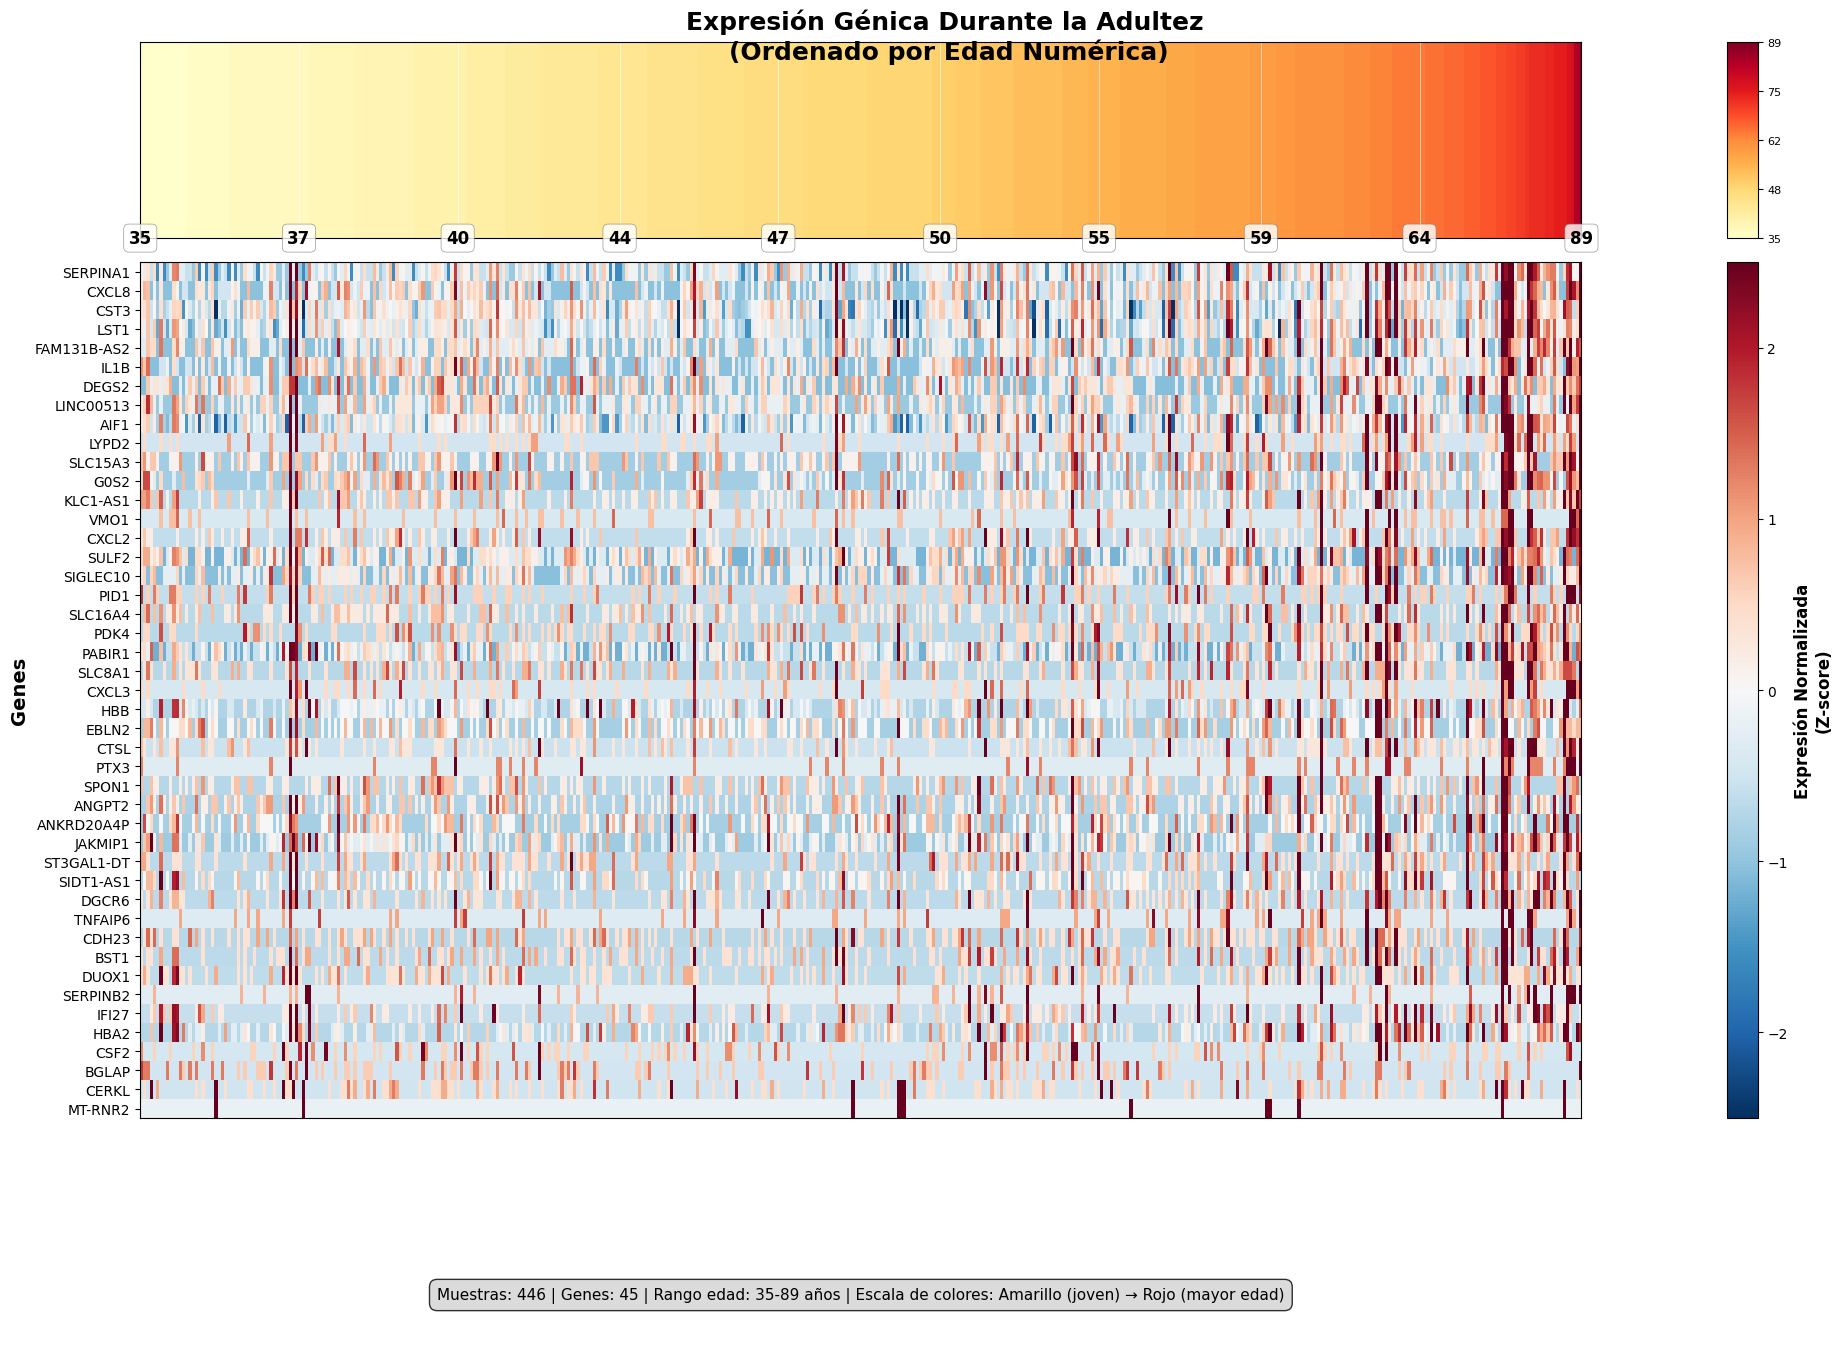



📈 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN...

📊 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN
❌ Error durante el análisis: single positional indexer is out-of-bounds
Traceback (most recent call last):
  File "/tmp/ipykernel_6059/340750642.py", line 423, in run_age_numeric_analysis
    corr_results = plot_age_correlation_analysis(pb, sig_genes)
  File "/tmp/ipykernel_6059/340750642.py", line 374, in plot_age_correlation_analysis
    top_neg_gene = corr_df[corr_df['Correlacion_Edad'] < 0].iloc[0]['Gene']
  File "/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pandas/core/indexing.py", line 1192, in __getitem__
    return self._getitem_axis(maybe_callable, axis=axis)
  File "/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pandas/core/indexing.py", line 1753, in _getitem_axis
    self._validate_integer(key, axis)
  File "/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/pandas/core/indexing.py", line 1686, in _validate_integer
    raise IndexError("single positional indexer

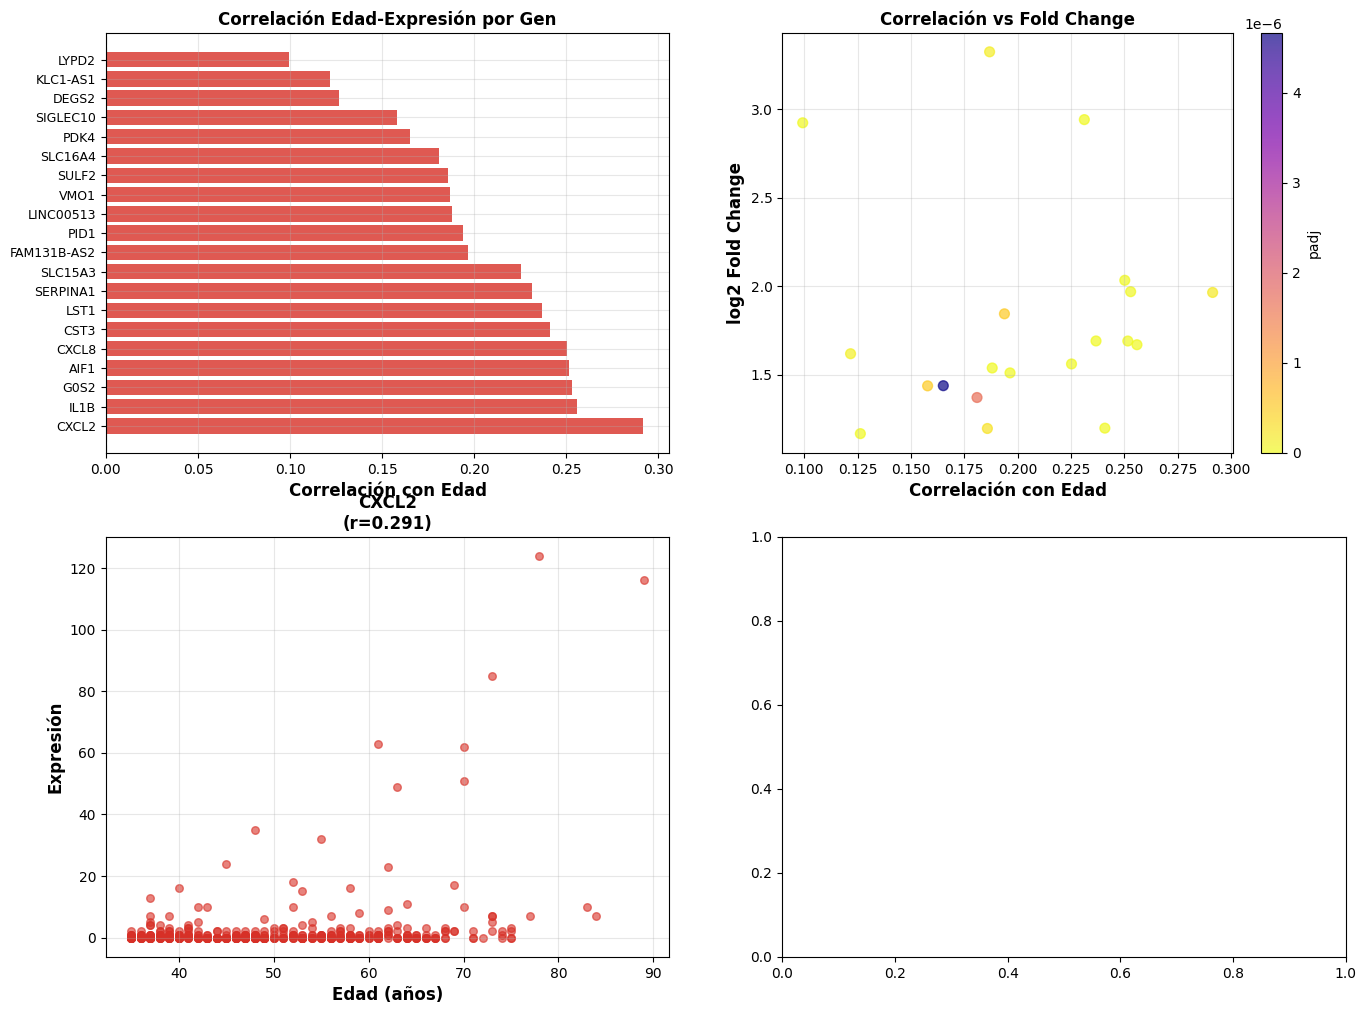

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

def analyze_age_data(pb):
    """
    Analizar los datos de edad disponibles
    """
    print("🔍 ANÁLISIS DE DATOS DE EDAD")
    print("=" * 50)
    
    # Verificar columna de edad
    if 'age_yrs' not in pb.obs.columns:
        print("❌ No se encontró columna 'age_yrs'")
        print("Columnas disponibles:", pb.obs.columns.tolist())
        return None
    
    age_data = pb.obs['age_yrs'].copy()
    
    # Estadísticas básicas
    print(f"Total de muestras: {len(age_data)}")
    print(f"Valores únicos de edad: {age_data.nunique()}")
    print(f"Valores no nulos: {age_data.notna().sum()}")
    print(f"Valores faltantes: {age_data.isna().sum()}")
    
    # Convertir a numérico si es necesario
    if age_data.dtype == 'object':
        print("\n⚠️  Columna age_yrs no es numérica, intentando conversión...")
        
        # Mostrar valores únicos
        print("Valores únicos encontrados:")
        unique_vals = age_data.unique()
        for val in unique_vals[:10]:  # Mostrar primeros 10
            print(f"  '{val}' (tipo: {type(val)})")
        
        # Intentar conversión
        age_numeric = pd.to_numeric(age_data, errors='coerce')
        
        print(f"Después de conversión:")
        print(f"  Valores convertidos exitosamente: {age_numeric.notna().sum()}")
        print(f"  Valores que no se pudieron convertir: {age_numeric.isna().sum()}")
        
        age_data = age_numeric
    
    # Filtrar valores válidos
    valid_ages = age_data.dropna()
    
    if len(valid_ages) == 0:
        print("❌ No hay edades válidas después de la conversión")
        return None
    
    print(f"\n📊 ESTADÍSTICAS DE EDAD:")
    print(f"  Edad mínima: {valid_ages.min()}")
    print(f"  Edad máxima: {valid_ages.max()}")
    print(f"  Edad promedio: {valid_ages.mean():.1f}")
    print(f"  Edad mediana: {valid_ages.median():.1f}")
    print(f"  Desviación estándar: {valid_ages.std():.1f}")
    
    # Distribución de edades
    print(f"\n📈 DISTRIBUCIÓN DE EDADES:")
    age_bins = np.linspace(valid_ages.min(), valid_ages.max(), 6)
    age_hist, _ = np.histogram(valid_ages, bins=age_bins)
    
    for i, (start, end, count) in enumerate(zip(age_bins[:-1], age_bins[1:], age_hist)):
        print(f"  {start:.0f}-{end:.0f} años: {count} muestras")
    
    return valid_ages

def create_age_gradient_colors(ages, colormap='YlOrRd'):
    """
    Crear gradiente de colores basado en edad
    Cambiado de 'RdYlGn_r' a 'YlOrRd' para ir de amarillo a rojo
    """
    # Normalizar edades a rango 0-1
    age_min, age_max = ages.min(), ages.max()
    normalized_ages = (ages - age_min) / (age_max - age_min)
    
    # Crear mapa de colores
    cmap = plt.cm.get_cmap(colormap)
    colors = [cmap(age) for age in normalized_ages]
    
    return colors, normalized_ages

def plot_age_ordered_heatmap(pb, sig_genes, n_top=80, figsize=(20, 14)):
    """
    Crear heatmap ordenado por edad numérica con mejoras visuales
    """
    print("🧬 GENERANDO HEATMAP ORDENADO POR EDAD NUMÉRICA")
    print("=" * 60)
    
    # Analizar datos de edad
    valid_ages = analyze_age_data(pb)
    if valid_ages is None:
        return None, None
    
    # Filtrar células con edad válida
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    
    print(f"\n🔬 Muestras con edad válida: {pb_filtered.n_obs}")
    
    # Seleccionar genes top significativos
    print(f"\n🧮 SELECCIÓN DE GENES (top {n_top})")
    
    # Criterios más estrictos para mejor visualización
    sig_filtered = sig_genes[
        (abs(sig_genes['log2FoldChange']) > 0.75) &  # Fold change mayor
        (sig_genes['padj'] < 0.01)  # Más significativo
    ].copy()
    
    print(f"Genes que cumplen criterios estrictos: {len(sig_filtered)}")
    
    if len(sig_filtered) < n_top:
        print("⚠️  Pocos genes con criterios estrictos, relajando filtros...")
        sig_filtered = sig_genes[
            (abs(sig_genes['log2FoldChange']) > 0.5) &
            (sig_genes['padj'] < 0.05)
        ].copy()
    
    # Seleccionar genes balanceados
    up_genes = sig_filtered[sig_filtered['log2FoldChange'] > 0].sort_values('padj').head(n_top//2)
    down_genes = sig_filtered[sig_filtered['log2FoldChange'] < 0].sort_values('padj').head(n_top//2)
    
    selected_genes = list(up_genes.index) + list(down_genes.index)
    available_genes = [g for g in selected_genes if g in pb_filtered.var_names]
    
    print(f"Genes finales seleccionados: {len(available_genes)}")
    print(f"  Up-regulados: {len([g for g in available_genes if g in up_genes.index])}")
    print(f"  Down-regulados: {len([g for g in available_genes if g in down_genes.index])}")
    
    # Extraer datos de expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(
        expr_matrix,
        columns=available_genes,
        index=pb_filtered.obs_names
    )
    
    # Procesar datos de expresión
    print(f"\n🔄 PROCESANDO EXPRESIÓN GÉNICA")
    
    # Limpiar valores no finitos
    expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
    expr_data = expr_data.fillna(expr_data.median())
    
    # Log transform si es necesario
    if expr_data.max().max() > 20:
        expr_data = np.log2(expr_data + 1)
        print("✅ Aplicada transformación log2(x+1)")
    
    # Z-score por gen para normalización
    expr_data_norm = expr_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Obtener edades correspondientes
    ages_filtered = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    # Ordenar por edad
    age_order = ages_filtered.sort_values().index
    expr_ordered = expr_data_norm.loc[age_order]
    ages_ordered = ages_filtered.loc[age_order]
    
    print(f"Rango de edades: {ages_ordered.min():.0f} - {ages_ordered.max():.0f} años")
    
    # CREAR VISUALIZACIÓN MEJORADA
    print(f"\n🎨 GENERANDO VISUALIZACIÓN")
    
    # Configurar colores para edad (cambio de escala de colores)
    age_colors, age_normalized = create_age_gradient_colors(ages_ordered, 'YlOrRd')
    
    # Crear figura con subplots para mejor control
    fig = plt.figure(figsize=figsize)
    
    # Crear heatmap principal con más espacio
    ax_main = plt.subplot2grid((12, 12), (2, 1), colspan=9, rowspan=8)
    
    # Heatmap de expresión
    im = ax_main.imshow(
        expr_ordered.T,  # Genes en Y, muestras en X
        cmap='RdBu_r',
        aspect='auto',
        vmin=-2.5, vmax=2.5,  # Rango fijo para comparabilidad
        interpolation='nearest'
    )
    
    # Configurar ejes principales
    ax_main.set_xticks([])  # Sin etiquetas X (demasiadas muestras)
    ax_main.set_yticks(range(len(available_genes)))
    ax_main.set_yticklabels(available_genes, fontsize=10)  # Aumentar tamaño de fuente
    ax_main.set_ylabel('Genes', fontsize=14, fontweight='bold')
    
    # Barra de colores para edad (arriba) - MEJORADA
    ax_age = plt.subplot2grid((12, 12), (0, 1), colspan=9, rowspan=2)
    
    # Crear gradiente de edad
    age_gradient = np.array([age_normalized]).reshape(1, -1)
    age_im = ax_age.imshow(age_gradient, cmap='YlOrRd', aspect='auto')
    ax_age.set_xlim(0, len(ages_ordered)-1)
    ax_age.set_xticks([])
    ax_age.set_yticks([])
    
   
    
    # MEJORA: Añadir más etiquetas de edad con mejor formato
    n_labels = 10  # Más etiquetas de edad
    label_indices = np.linspace(0, len(ages_ordered)-1, n_labels, dtype=int)
    
    for i, idx in enumerate(label_indices):
        age_val = ages_ordered.iloc[idx]
        # Posición Y ajustada para mejor visibilidad
        y_pos = 0.5
        
        # MEJORA: Usar siempre texto negro con fondo blanco para máxima legibilidad
        # Esto resuelve el problema de la edad 89 en blanco
        text_color = 'black'  # Siempre negro para consistencia
        
        # Texto más grande y con borde para mejor legibilidad
        ax_age.text(idx, y_pos, f'{age_val:.0f}', 
                   ha='center', va='center', 
                   fontsize=12, fontweight='bold',  # Aumentar tamaño de fuente
                   color=text_color,
                   bbox=dict(boxstyle="round,pad=0.3", 
                            facecolor='white', 
                            alpha=0.8,  # Más opaco para mejor contraste
                            edgecolor='gray',  # Añadir borde gris sutil
                            linewidth=0.5))
    
    # Añadir líneas de separación para mejor legibilidad
    for idx in label_indices[1:-1]:  # Excluir primero y último
        ax_age.axvline(x=idx, color='white', linewidth=0.5, alpha=0.8)
    
    # Colorbar para expresión (derecha) - MEJORADA
    ax_cbar = plt.subplot2grid((12, 12), (2, 10), colspan=1, rowspan=8)
    cbar = plt.colorbar(im, cax=ax_cbar)
    cbar.set_label('Expresión Normalizada\n(Z-score)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Colorbar para edad (lado derecho, pequeña) - SIN ETIQUETA para evitar duplicación
    ax_age_cbar = plt.subplot2grid((12, 12), (0, 10), colspan=1, rowspan=2)
    age_cbar = plt.colorbar(age_im, cax=ax_age_cbar)
    # Removemos la etiqueta del colorbar ya que ahora está arriba de la barra principal
    age_cbar.ax.tick_params(labelsize=8)
    
    # Configurar ticks del colorbar de edad
    age_ticks = np.linspace(0, 1, 5)
    age_tick_labels = [f'{int(ages_ordered.min() + tick * (ages_ordered.max() - ages_ordered.min()))}' 
                       for tick in age_ticks]
    age_cbar.set_ticks(age_ticks)
    age_cbar.set_ticklabels(age_tick_labels)
    
    # Título principal mejorado
    fig.suptitle('Expresión Génica Durante la Adultez \n(Ordenado por Edad Numérica)', 
                fontsize=18, fontweight='bold', y=0.96)
    
    # Información adicional mejorada
    ax_info = plt.subplot2grid((12, 12), (11, 1), colspan=9, rowspan=1)
    info_text = (f'Muestras: {len(ages_ordered)} | Genes: {len(available_genes)} | '
                f'Rango edad: {ages_ordered.min():.0f}-{ages_ordered.max():.0f} años | '
                f'Escala de colores: Amarillo (joven) → Rojo (mayor edad)')
    
    ax_info.text(0.5, 0.5, info_text,
                ha='center', va='center', fontsize=11,
                transform=ax_info.transAxes,
                bbox=dict(boxstyle="round,pad=0.5", 
                         facecolor='lightgray', 
                         alpha=0.8))
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)
    ax_info.axis('off')
    
    plt.tight_layout()
    
    # Guardar con mayor resolución
    output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_edad_numerica_mejorado.png'
    plt.savefig(output_path, dpi=400, bbox_inches='tight', facecolor='white')
    print(f"✅ Heatmap mejorado guardado en: {output_path}")
    
    plt.show()
    
    return expr_ordered, ages_ordered

def plot_age_correlation_analysis(pb, sig_genes, top_genes=None):
    """
    Análisis de correlación entre edad y expresión génica
    """
    print("\n📊 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN")
    print("=" * 50)
    
    # Filtrar datos válidos
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    ages = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    if top_genes is None:
        # Usar genes más significativos
        top_genes = sig_genes.head(20).index.tolist()
    
    available_genes = [g for g in top_genes if g in pb_filtered.var_names]
    
    # Extraer expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(expr_matrix, columns=available_genes, index=pb_filtered.obs_names)
    
    # Calcular correlaciones
    correlations = []
    for gene in available_genes:
        corr = np.corrcoef(ages, expr_data[gene])[0, 1]
        p_val = sig_genes.loc[gene, 'padj'] if gene in sig_genes.index else np.nan
        fold_change = sig_genes.loc[gene, 'log2FoldChange'] if gene in sig_genes.index else np.nan
        
        correlations.append({
            'Gene': gene,
            'Correlacion_Edad': corr,
            'log2FoldChange': fold_change,
            'padj': p_val
        })
    
    corr_df = pd.DataFrame(correlations).sort_values('Correlacion_Edad', key=abs, ascending=False)
    
    # Visualización mejorada
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Gráfico 1: Correlaciones ordenadas
    ax1 = axes[0, 0]
    colors = ['#D73027' if x > 0 else '#4575B4' for x in corr_df['Correlacion_Edad']]  # Colores más intensos
    bars = ax1.barh(range(len(corr_df)), corr_df['Correlacion_Edad'], color=colors, alpha=0.8)
    ax1.set_yticks(range(len(corr_df)))
    ax1.set_yticklabels(corr_df['Gene'], fontsize=9)
    ax1.set_xlabel('Correlación con Edad', fontsize=12, fontweight='bold')
    ax1.set_title('Correlación Edad-Expresión por Gen', fontsize=12, fontweight='bold')
    ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Scatter correlación vs fold change
    ax2 = axes[0, 1]
    scatter = ax2.scatter(corr_df['Correlacion_Edad'], corr_df['log2FoldChange'], 
                         c=corr_df['padj'], cmap='plasma_r', alpha=0.7, s=50)
    ax2.set_xlabel('Correlación con Edad', fontsize=12, fontweight='bold')
    ax2.set_ylabel('log2 Fold Change', fontsize=12, fontweight='bold')
    ax2.set_title('Correlación vs Fold Change', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax2, label='padj')
    
    # Gráfico 3: Ejemplo de gen positivamente correlacionado
    ax3 = axes[1, 0]
    top_pos_gene = corr_df[corr_df['Correlacion_Edad'] > 0].iloc[0]['Gene']
    if top_pos_gene in available_genes:
        ax3.scatter(ages, expr_data[top_pos_gene], alpha=0.6, color='#D73027', s=30)
        ax3.set_xlabel('Edad (años)', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Expresión', fontsize=12, fontweight='bold')
        ax3.set_title(f'{top_pos_gene}\n(r={corr_df[corr_df["Gene"]==top_pos_gene]["Correlacion_Edad"].iloc[0]:.3f})',
                     fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)
    
    # Gráfico 4: Ejemplo de gen negativamente correlacionado
    ax4 = axes[1, 1]
    top_neg_gene = corr_df[corr_df['Correlacion_Edad'] < 0].iloc[0]['Gene']
    if top_neg_gene in available_genes:
        ax4.scatter(ages, expr_data[top_neg_gene], alpha=0.6, color='#4575B4', s=30)
        ax4.set_xlabel('Edad (años)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Expresión', fontsize=12, fontweight='bold')
        ax4.set_title(f'{top_neg_gene}\n(r={corr_df[corr_df["Gene"]==top_neg_gene]["Correlacion_Edad"].iloc[0]:.3f})',
                     fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Guardar
    corr_output = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlacion_edad_expresion_mejorado.png'
    plt.savefig(corr_output, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Guardar tabla de correlaciones
    corr_table_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlaciones_edad.csv'
    corr_df.to_csv(corr_table_path, index=False)
    
    print(f"✅ Análisis de correlación guardado en: {corr_output}")
    print(f"✅ Tabla de correlaciones guardada en: {corr_table_path}")
    
    return corr_df

# FUNCIÓN PRINCIPAL
def run_age_numeric_analysis(pb, sig_genes):
    """
    Ejecutar análisis completo basado en edad numérica
    """
    print("🎯 ANÁLISIS COMPLETO BASADO EN EDAD NUMÉRICA")
    print("=" * 70)
    
    try:
        # 1. Análisis exploratorio de edad
        valid_ages = analyze_age_data(pb)
        if valid_ages is None:
            return None, None
        
        print("\n" + "="*70)
        
        # 2. Heatmap ordenado por edad
        print("\n🎨 GENERANDO HEATMAP ORDENADO POR EDAD...")
        expr_ordered, ages_ordered = plot_age_ordered_heatmap(pb, sig_genes, n_top=83)
        
        print("\n" + "="*70)
        
        # 3. Análisis de correlación
        print("\n📈 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN...")
        corr_results = plot_age_correlation_analysis(pb, sig_genes)
        
        print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
        print("📁 Archivos generados:")
        print("   - Heatmap por edad numérica (mejorado)")
        print("   - Análisis de correlación (mejorado)")
        print("   - Tabla de correlaciones")
        
        return expr_ordered, corr_results
        
    except Exception as e:
        print(f"❌ Error durante el análisis: {e}")
        import traceback
        print(traceback.format_exc())
        return None, None

# EJECUTAR ANÁLISIS
expr_ordered, corr_results = run_age_numeric_analysis(pb, sig_genes)

🎯 ANÁLISIS COMPLETO BASADO EN EDAD NUMÉRICA
🔍 ANÁLISIS DE DATOS DE EDAD
Total de muestras: 502
Valores únicos de edad: 46
Valores no nulos: 446
Valores faltantes: 56

⚠️  Columna age_yrs no es numérica, intentando conversión...
Valores únicos encontrados:
  '75' (tipo: <class 'int'>)
  '49' (tipo: <class 'int'>)
  '36' (tipo: <class 'int'>)
  '48' (tipo: <class 'int'>)
  '37' (tipo: <class 'int'>)
  '63' (tipo: <class 'int'>)
  '67' (tipo: <class 'int'>)
  '54' (tipo: <class 'int'>)
  '70' (tipo: <class 'int'>)
  '73' (tipo: <class 'int'>)
Después de conversión:
  Valores convertidos exitosamente: 446
  Valores que no se pudieron convertir: 56

📊 ESTADÍSTICAS DE EDAD:
  Edad mínima: 35.0
  Edad máxima: 89.0
  Edad promedio: 50.3
  Edad mediana: 48.0
  Desviación estándar: 10.8

📈 DISTRIBUCIÓN DE EDADES:
  35-46 años: 173 muestras
  46-57 años: 144 muestras
  57-67 años: 97 muestras
  67-78 años: 29 muestras
  78-89 años: 3 muestras


🎨 GENERANDO HEATMAP ORDENADO POR EDAD...
🧬 GENERANDO

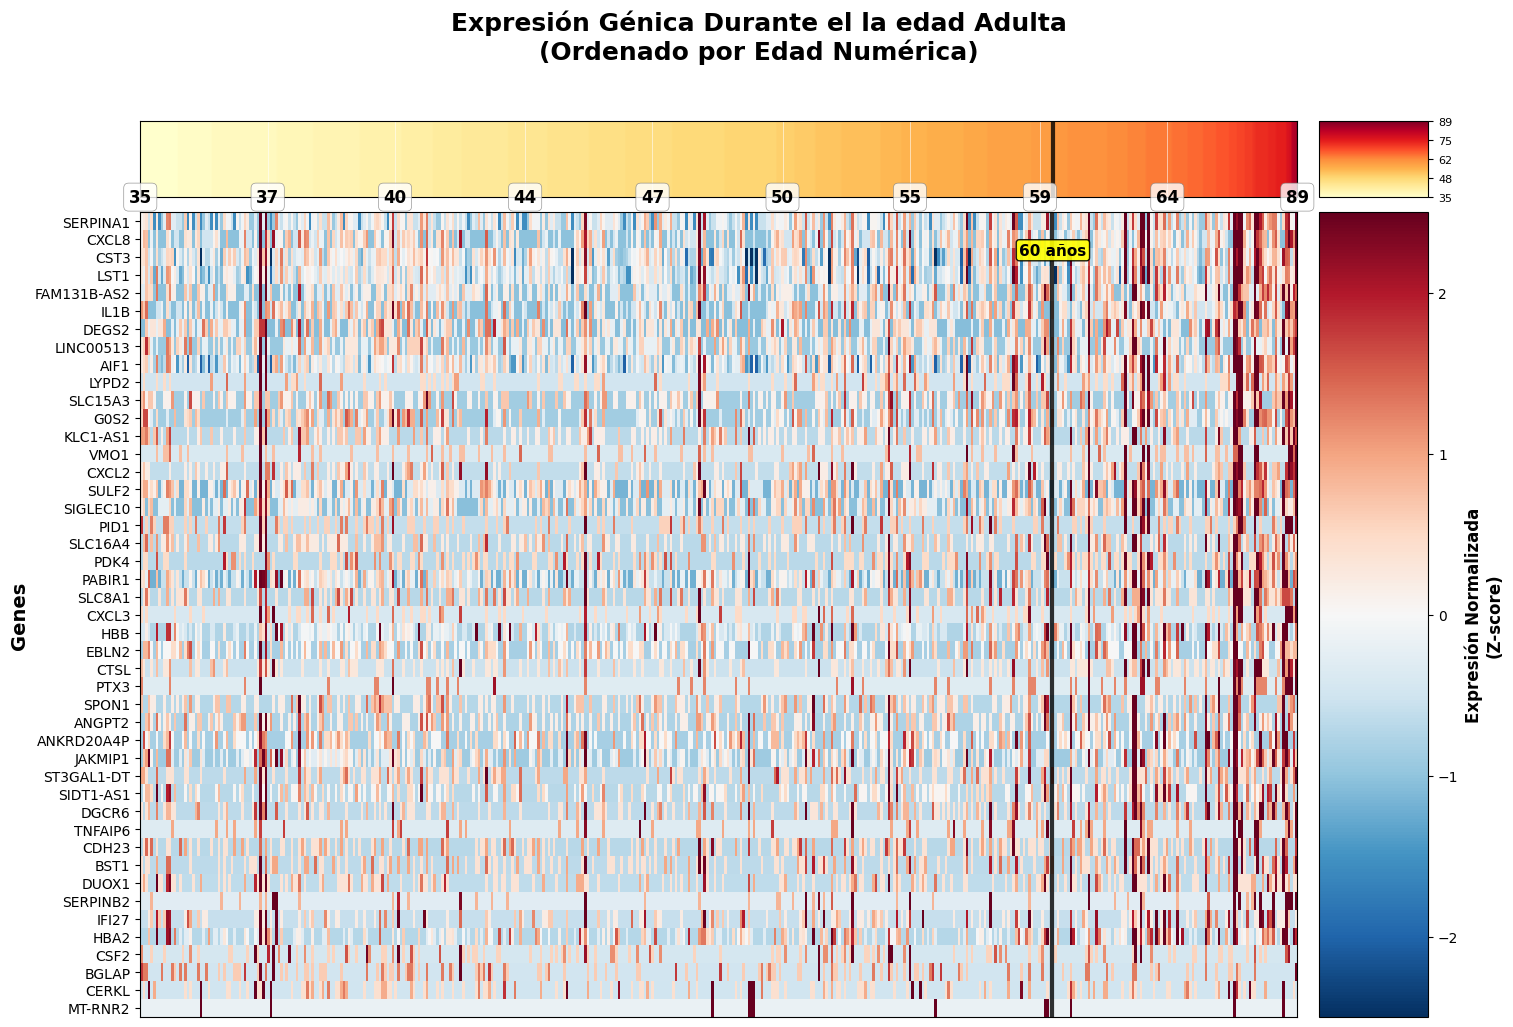

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

def analyze_age_data(pb):
    """
    Analizar los datos de edad disponibles
    """
    print("🔍 ANÁLISIS DE DATOS DE EDAD")
    print("=" * 50)
    
    # Verificar columna de edad
    if 'age_yrs' not in pb.obs.columns:
        print("❌ No se encontró columna 'age_yrs'")
        print("Columnas disponibles:", pb.obs.columns.tolist())
        return None
    
    age_data = pb.obs['age_yrs'].copy()
    
    # Estadísticas básicas
    print(f"Total de muestras: {len(age_data)}")
    print(f"Valores únicos de edad: {age_data.nunique()}")
    print(f"Valores no nulos: {age_data.notna().sum()}")
    print(f"Valores faltantes: {age_data.isna().sum()}")
    
    # Convertir a numérico si es necesario
    if age_data.dtype == 'object':
        print("\n⚠️  Columna age_yrs no es numérica, intentando conversión...")
        
        # Mostrar valores únicos
        print("Valores únicos encontrados:")
        unique_vals = age_data.unique()
        for val in unique_vals[:10]:  # Mostrar primeros 10
            print(f"  '{val}' (tipo: {type(val)})")
        
        # Intentar conversión
        age_numeric = pd.to_numeric(age_data, errors='coerce')
        
        print(f"Después de conversión:")
        print(f"  Valores convertidos exitosamente: {age_numeric.notna().sum()}")
        print(f"  Valores que no se pudieron convertir: {age_numeric.isna().sum()}")
        
        age_data = age_numeric
    
    # Filtrar valores válidos
    valid_ages = age_data.dropna()
    
    if len(valid_ages) == 0:
        print("❌ No hay edades válidas después de la conversión")
        return None
    
    print(f"\n📊 ESTADÍSTICAS DE EDAD:")
    print(f"  Edad mínima: {valid_ages.min()}")
    print(f"  Edad máxima: {valid_ages.max()}")
    print(f"  Edad promedio: {valid_ages.mean():.1f}")
    print(f"  Edad mediana: {valid_ages.median():.1f}")
    print(f"  Desviación estándar: {valid_ages.std():.1f}")
    
    # Distribución de edades
    print(f"\n📈 DISTRIBUCIÓN DE EDADES:")
    age_bins = np.linspace(valid_ages.min(), valid_ages.max(), 6)
    age_hist, _ = np.histogram(valid_ages, bins=age_bins)
    
    for i, (start, end, count) in enumerate(zip(age_bins[:-1], age_bins[1:], age_hist)):
        print(f"  {start:.0f}-{end:.0f} años: {count} muestras")
    
    return valid_ages

def create_age_gradient_colors(ages, colormap='YlOrRd'):
    """
    Crear gradiente de colores basado en edad
    Cambiado de 'RdYlGn_r' a 'YlOrRd' para ir de amarillo a rojo
    """
    # Normalizar edades a rango 0-1
    age_min, age_max = ages.min(), ages.max()
    normalized_ages = (ages - age_min) / (age_max - age_min)
    
    # Crear mapa de colores
    cmap = plt.cm.get_cmap(colormap)
    colors = [cmap(age) for age in normalized_ages]
    
    return colors, normalized_ages

def plot_age_ordered_heatmap(pb, sig_genes, n_top=80, figsize=(20, 14)):
    """
    Crear heatmap ordenado por edad numérica con mejoras visuales
    """
    print("🧬 GENERANDO HEATMAP ORDENADO POR EDAD NUMÉRICA")
    print("=" * 60)
    
    # Analizar datos de edad
    valid_ages = analyze_age_data(pb)
    if valid_ages is None:
        return None, None
    
    # Filtrar células con edad válida
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    
    print(f"\n🔬 Muestras con edad válida: {pb_filtered.n_obs}")
    
    # Seleccionar genes top significativos
    print(f"\n🧮 SELECCIÓN DE GENES (top {n_top})")
    
    # Criterios más estrictos para mejor visualización
    sig_filtered = sig_genes[
        (abs(sig_genes['log2FoldChange']) > 0.75) &  # Fold change mayor
        (sig_genes['padj'] < 0.01)  # Más significativo
    ].copy()
    
    print(f"Genes que cumplen criterios estrictos: {len(sig_filtered)}")
    
    if len(sig_filtered) < n_top:
        print("⚠️  Pocos genes con criterios estrictos, relajando filtros...")
        sig_filtered = sig_genes[
            (abs(sig_genes['log2FoldChange']) > 0.5) &
            (sig_genes['padj'] < 0.05)
        ].copy()
    
    # Seleccionar genes balanceados
    up_genes = sig_filtered[sig_filtered['log2FoldChange'] > 0].sort_values('padj').head(n_top//2)
    down_genes = sig_filtered[sig_filtered['log2FoldChange'] < 0].sort_values('padj').head(n_top//2)
    
    selected_genes = list(up_genes.index) + list(down_genes.index)
    available_genes = [g for g in selected_genes if g in pb_filtered.var_names]
    
    print(f"Genes finales seleccionados: {len(available_genes)}")
    print(f"  Up-regulados: {len([g for g in available_genes if g in up_genes.index])}")
    print(f"  Down-regulados: {len([g for g in available_genes if g in down_genes.index])}")
    
    # Extraer datos de expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(
        expr_matrix,
        columns=available_genes,
        index=pb_filtered.obs_names
    )
    
    # Procesar datos de expresión
    print(f"\n🔄 PROCESANDO EXPRESIÓN GÉNICA")
    
    # Limpiar valores no finitos
    expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
    expr_data = expr_data.fillna(expr_data.median())
    
    # Log transform si es necesario
    if expr_data.max().max() > 20:
        expr_data = np.log2(expr_data + 1)
        print("✅ Aplicada transformación log2(x+1)")
    
    # Z-score por gen para normalización
    expr_data_norm = expr_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Obtener edades correspondientes
    ages_filtered = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    # Ordenar por edad
    age_order = ages_filtered.sort_values().index
    expr_ordered = expr_data_norm.loc[age_order]
    ages_ordered = ages_filtered.loc[age_order]
    
    print(f"Rango de edades: {ages_ordered.min():.0f} - {ages_ordered.max():.0f} años")
    
    # CREAR VISUALIZACIÓN MEJORADA
    print(f"\n🎨 GENERANDO VISUALIZACIÓN")
    
    # Configurar colores para edad (cambio de escala de colores)
    age_colors, age_normalized = create_age_gradient_colors(ages_ordered, 'YlOrRd')
    
    # Crear figura con subplots para mejor control
    fig = plt.figure(figsize=figsize)
    
    # Crear heatmap principal con más espacio (ajustado por menor grosor de barra de edad)
    ax_main = plt.subplot2grid((12, 12), (1, 1), colspan=9, rowspan=9)
    
    # Heatmap de expresión
    im = ax_main.imshow(
        expr_ordered.T,  # Genes en Y, muestras en X
        cmap='RdBu_r',
        aspect='auto',
        vmin=-2.5, vmax=2.5,  # Rango fijo para comparabilidad
        interpolation='nearest'
    )
    
    # Configurar ejes principales
    ax_main.set_xticks([])  # Sin etiquetas X (demasiadas muestras)
    ax_main.set_yticks(range(len(available_genes)))
    ax_main.set_yticklabels(available_genes, fontsize=10)  # Aumentar tamaño de fuente
    ax_main.set_ylabel('Genes', fontsize=14, fontweight='bold')
    
    # Barra de colores para edad (arriba) - MEJORADA con menor grosor
    ax_age = plt.subplot2grid((12, 12), (0, 1), colspan=9, rowspan=1)
    
    # Crear gradiente de edad
    age_gradient = np.array([age_normalized]).reshape(1, -1)
    age_im = ax_age.imshow(age_gradient, cmap='YlOrRd', aspect='auto')
    ax_age.set_xlim(0, len(ages_ordered)-1)
    ax_age.set_xticks([])
    ax_age.set_yticks([])
    

    
    # MEJORA: Añadir línea divisoria clara en los 60 años
    # Encontrar la posición donde las edades cruzan los 60 años
    age_60_indices = np.where(ages_ordered >= 60)[0]
    if len(age_60_indices) > 0:
        # Posición del primer índice donde la edad es >= 60
        line_position = age_60_indices[0]
        
        # Línea divisoria vertical prominente en el heatmap principal
        ax_main.axvline(x=line_position, color='black', linewidth=3, alpha=0.8, 
                       linestyle='-', label='60 años')
        
        # Línea divisoria en la barra de edad también
        ax_age.axvline(x=line_position, color='black', linewidth=3, alpha=0.8, 
                      linestyle='-')
        
        # Añadir texto indicativo cerca de la línea
        ax_age.text(line_position, 1.2, '60 años', 
                   ha='center', va='center', 
                   fontsize=11, fontweight='bold',
                   color='black',
                   bbox=dict(boxstyle="round,pad=0.2", 
                            facecolor='yellow', 
                            alpha=0.9,
                            edgecolor='black',
                            linewidth=1))
    
    # MEJORA: Añadir más etiquetas de edad con mejor formato
    n_labels = 10  # Más etiquetas de edad
    label_indices = np.linspace(0, len(ages_ordered)-1, n_labels, dtype=int)
    
    for i, idx in enumerate(label_indices):
        age_val = ages_ordered.iloc[idx]
        # Posición Y ajustada para mejor visibilidad
        y_pos = 0.5
        
        # MEJORA: Usar siempre texto negro con fondo blanco para máxima legibilidad
        # Esto resuelve el problema de la edad 89 en blanco
        text_color = 'black'  # Siempre negro para consistencia
        
        # Texto más grande y con borde para mejor legibilidad
        ax_age.text(idx, y_pos, f'{age_val:.0f}', 
                   ha='center', va='center', 
                   fontsize=12, fontweight='bold',  # Aumentar tamaño de fuente
                   color=text_color,
                   bbox=dict(boxstyle="round,pad=0.3", 
                            facecolor='white', 
                            alpha=0.8,  # Más opaco para mejor contraste
                            edgecolor='gray',  # Añadir borde gris sutil
                            linewidth=0.5))
    
    # Añadir líneas de separación para mejor legibilidad
    for idx in label_indices[1:-1]:  # Excluir primero y último
        ax_age.axvline(x=idx, color='white', linewidth=0.5, alpha=0.8)
    
    # Colorbar para expresión (derecha) - MEJORADA (ajustado por nueva posición)
    ax_cbar = plt.subplot2grid((12, 12), (1, 10), colspan=1, rowspan=9)
    cbar = plt.colorbar(im, cax=ax_cbar)
    cbar.set_label('Expresión Normalizada\n(Z-score)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Colorbar para edad (lado derecho, pequeña) - SIN ETIQUETA para evitar duplicación (ajustado)
    ax_age_cbar = plt.subplot2grid((12, 12), (0, 10), colspan=1, rowspan=1)
    age_cbar = plt.colorbar(age_im, cax=ax_age_cbar)
    # Removemos la etiqueta del colorbar ya que ahora está arriba de la barra principal
    age_cbar.ax.tick_params(labelsize=8)
    
    # Configurar ticks del colorbar de edad
    age_ticks = np.linspace(0, 1, 5)
    age_tick_labels = [f'{int(ages_ordered.min() + tick * (ages_ordered.max() - ages_ordered.min()))}' 
                       for tick in age_ticks]
    age_cbar.set_ticks(age_ticks)
    age_cbar.set_ticklabels(age_tick_labels)
    
    # Título principal mejorado
    fig.suptitle('Expresión Génica Durante el la edad Adulta\n(Ordenado por Edad Numérica)', 
                fontsize=18, fontweight='bold', y=0.96)
    
    # Información adicional mejorada (ajustada por nueva posición)
    ax_info = plt.subplot2grid((12, 12), (11, 1), colspan=9, rowspan=1.3)
    info_text = (f'Muestras: {len(ages_ordered)} | Genes: {len(available_genes)} | '
                f'Rango edad: {ages_ordered.min():.0f}-{ages_ordered.max():.0f} años | '
                f'Escala de colores: Amarillo (joven) → Rojo (mayor edad) | Línea negra: 60 años')
    
    ax_info.text(0.5, 0.5, info_text,
                ha='center', va='center', fontsize=11,
                transform=ax_info.transAxes,
                bbox=dict(boxstyle="round,pad=0.5", 
                         facecolor='lightgray', 
                         alpha=0.8))
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)
    ax_info.axis('off')
    
    plt.tight_layout()
    
    # Guardar con mayor resolución
    output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_edad_numerica_mejorado.png'
    plt.savefig(output_path, dpi=400, bbox_inches='tight', facecolor='white')
    print(f"✅ Heatmap mejorado guardado en: {output_path}")
    
    plt.show()
    
    return expr_ordered, ages_ordered

def plot_age_correlation_analysis(pb, sig_genes, top_genes=None):
    """
    Análisis de correlación entre edad y expresión génica
    """
    print("\n📊 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN")
    print("=" * 50)
    
    # Filtrar datos válidos
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    ages = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    if top_genes is None:
        # Usar genes más significativos
        top_genes = sig_genes.head(20).index.tolist()
    
    available_genes = [g for g in top_genes if g in pb_filtered.var_names]
    
    # Extraer expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(expr_matrix, columns=available_genes, index=pb_filtered.obs_names)
    
    # Calcular correlaciones
    correlations = []
    for gene in available_genes:
        corr = np.corrcoef(ages, expr_data[gene])[0, 1]
        p_val = sig_genes.loc[gene, 'padj'] if gene in sig_genes.index else np.nan
        fold_change = sig_genes.loc[gene, 'log2FoldChange'] if gene in sig_genes.index else np.nan
        
        correlations.append({
            'Gene': gene,
            'Correlacion_Edad': corr,
            'log2FoldChange': fold_change,
            'padj': p_val
        })
    
    corr_df = pd.DataFrame(correlations).sort_values('Correlacion_Edad', key=abs, ascending=False)
    
    # Visualización mejorada
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Gráfico 1: Correlaciones ordenadas
    ax1 = axes[0, 0]
    colors = ['#D73027' if x > 0 else '#4575B4' for x in corr_df['Correlacion_Edad']]  # Colores más intensos
    bars = ax1.barh(range(len(corr_df)), corr_df['Correlacion_Edad'], color=colors, alpha=0.8)
    ax1.set_yticks(range(len(corr_df)))
    ax1.set_yticklabels(corr_df['Gene'], fontsize=9)
    ax1.set_xlabel('Correlación con Edad', fontsize=12, fontweight='bold')
    ax1.set_title('Correlación Edad-Expresión por Gen', fontsize=12, fontweight='bold')
    ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Scatter correlación vs fold change
    ax2 = axes[0, 1]
    scatter = ax2.scatter(corr_df['Correlacion_Edad'], corr_df['log2FoldChange'], 
                         c=corr_df['padj'], cmap='plasma_r', alpha=0.7, s=50)
    ax2.set_xlabel('Correlación con Edad', fontsize=12, fontweight='bold')
    ax2.set_ylabel('log2 Fold Change', fontsize=12, fontweight='bold')
    ax2.set_title('Correlación vs Fold Change', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax2, label='padj')
    
    # Gráfico 3: Ejemplo de gen positivamente correlacionado
    ax3 = axes[1, 0]
    top_pos_gene = corr_df[corr_df['Correlacion_Edad'] > 0].iloc[0]['Gene']
    if top_pos_gene in available_genes:
        ax3.scatter(ages, expr_data[top_pos_gene], alpha=0.6, color='#D73027', s=30)
        ax3.set_xlabel('Edad (años)', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Expresión', fontsize=12, fontweight='bold')
        ax3.set_title(f'{top_pos_gene}\n(r={corr_df[corr_df["Gene"]==top_pos_gene]["Correlacion_Edad"].iloc[0]:.3f})',
                     fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)
    
    # Gráfico 4: Ejemplo de gen negativamente correlacionado
    ax4 = axes[1, 1]
    top_neg_gene = corr_df[corr_df['Correlacion_Edad'] < 0].iloc[0]['Gene']
    if top_neg_gene in available_genes:
        ax4.scatter(ages, expr_data[top_neg_gene], alpha=0.6, color='#4575B4', s=30)
        ax4.set_xlabel('Edad (años)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Expresión', fontsize=12, fontweight='bold')
        ax4.set_title(f'{top_neg_gene}\n(r={corr_df[corr_df["Gene"]==top_neg_gene]["Correlacion_Edad"].iloc[0]:.3f})',
                     fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Guardar
    corr_output = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlacion_edad_expresion_mejorado.png'
    plt.savefig(corr_output, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Guardar tabla de correlaciones
    corr_table_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlaciones_edad.csv'
    corr_df.to_csv(corr_table_path, index=False)
    
    print(f"✅ Análisis de correlación guardado en: {corr_output}")
    print(f"✅ Tabla de correlaciones guardada en: {corr_table_path}")
    
    return corr_df

# FUNCIÓN PRINCIPAL
def run_age_numeric_analysis(pb, sig_genes):
    """
    Ejecutar análisis completo basado en edad numérica
    """
    print("🎯 ANÁLISIS COMPLETO BASADO EN EDAD NUMÉRICA")
    print("=" * 70)
    
    try:
        # 1. Análisis exploratorio de edad
        valid_ages = analyze_age_data(pb)
        if valid_ages is None:
            return None, None
        
        print("\n" + "="*70)
        
        # 2. Heatmap ordenado por edad
        print("\n🎨 GENERANDO HEATMAP ORDENADO POR EDAD...")
        expr_ordered, ages_ordered = plot_age_ordered_heatmap(pb, sig_genes, n_top=83)
        
        print("\n" + "="*70)
        
        # 3. Análisis de correlación
        print("\n📈 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN...")
        corr_results = plot_age_correlation_analysis(pb, sig_genes)
        
        print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
        print("📁 Archivos generados:")
        print("   - Heatmap por edad numérica (mejorado)")
        print("   - Análisis de correlación (mejorado)")
        print("   - Tabla de correlaciones")
        
        return expr_ordered, corr_results
        
    except Exception as e:
        print(f"❌ Error durante el análisis: {e}")
        import traceback
        print(traceback.format_exc())
        return None, None

# EJECUTAR ANÁLISIS
expr_ordered, corr_results = run_age_numeric_analysis(pb, sig_genes)

In [73]:
# Contar número total de donantes únicos
print(f"Total de donantes únicos: {adata.obs['donor_id'].nunique()}")

# Contar donantes por grupo de edad
print(f"Donantes por grupo de edad:")
print(adata.obs.groupby('age_group')['donor_id'].nunique())

# O de forma más detallada:
adult_donors = adata.obs[adata.obs['age_group'] == 'adult']['donor_id'].nunique()
old_donors = adata.obs[adata.obs['age_group'] == 'old']['donor_id'].nunique()

print(f"Donantes adultos: {adult_donors}")
print(f"Donantes mayores: {old_donors}")

# Verificar que no hay overlap (opcional)
adult_donor_list = set(adata.obs[adata.obs['age_group'] == 'adult']['donor_id'].unique())
old_donor_list = set(adata.obs[adata.obs['age_group'] == 'old']['donor_id'].unique())
overlap = adult_donor_list.intersection(old_donor_list)
print(f"Donantes en ambos grupos: {len(overlap)}")

# Una línea súper simple para conteo total:
# adata.obs['donor_id'].nunique()

# Una línea para conteo por grupo:
# adata.obs.groupby('age_group')['donor_id'].nunique()

Total de donantes únicos: 502
Donantes por grupo de edad:
age_group
adult    384
old      118
Name: donor_id, dtype: int64
Donantes adultos: 384
Donantes mayores: 118
Donantes en ambos grupos: 0


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

def analyze_age_data(pb):
    """
    Analizar los datos de edad disponibles
    """
    print("🔍 ANÁLISIS DE DATOS DE EDAD")
    print("=" * 50)
    
    # Verificar columna de edad
    if 'age_yrs' not in pb.obs.columns:
        print("❌ No se encontró columna 'age_yrs'")
        print("Columnas disponibles:", pb.obs.columns.tolist())
        return None
    
    age_data = pb.obs['age_yrs'].copy()
    
    # Estadísticas básicas
    print(f"Total de muestras: {len(age_data)}")
    print(f"Valores únicos de edad: {age_data.nunique()}")
    print(f"Valores no nulos: {age_data.notna().sum()}")
    print(f"Valores faltantes: {age_data.isna().sum()}")
    
    # Convertir a numérico si es necesario
    if age_data.dtype == 'object':
        print("\n⚠️  Columna age_yrs no es numérica, intentando conversión...")
        
        # Mostrar valores únicos
        print("Valores únicos encontrados:")
        unique_vals = age_data.unique()
        for val in unique_vals[:10]:  # Mostrar primeros 10
            print(f"  '{val}' (tipo: {type(val)})")
        
        # Intentar conversión
        age_numeric = pd.to_numeric(age_data, errors='coerce')
        
        print(f"Después de conversión:")
        print(f"  Valores convertidos exitosamente: {age_numeric.notna().sum()}")
        print(f"  Valores que no se pudieron convertir: {age_numeric.isna().sum()}")
        
        age_data = age_numeric
    
    # Filtrar valores válidos
    valid_ages = age_data.dropna()
    
    if len(valid_ages) == 0:
        print("❌ No hay edades válidas después de la conversión")
        return None
    
    print(f"\n📊 ESTADÍSTICAS DE EDAD:")
    print(f"  Edad mínima: {valid_ages.min()}")
    print(f"  Edad máxima: {valid_ages.max()}")
    print(f"  Edad promedio: {valid_ages.mean():.1f}")
    print(f"  Edad mediana: {valid_ages.median():.1f}")
    print(f"  Desviación estándar: {valid_ages.std():.1f}")
    
    # Distribución de edades
    print(f"\n📈 DISTRIBUCIÓN DE EDADES:")
    age_bins = np.linspace(valid_ages.min(), valid_ages.max(), 6)
    age_hist, _ = np.histogram(valid_ages, bins=age_bins)
    
    for i, (start, end, count) in enumerate(zip(age_bins[:-1], age_bins[1:], age_hist)):
        print(f"  {start:.0f}-{end:.0f} años: {count} muestras")
    
    return valid_ages

def create_age_gradient_colors(ages, colormap='YlOrRd'):
    """
    Crear gradiente de colores basado en edad
    Cambiado de 'RdYlGn_r' a 'YlOrRd' para ir de amarillo a rojo
    """
    # Normalizar edades a rango 0-1
    age_min, age_max = ages.min(), ages.max()
    normalized_ages = (ages - age_min) / (age_max - age_min)
    
    # Crear mapa de colores
    cmap = plt.cm.get_cmap(colormap)
    colors = [cmap(age) for age in normalized_ages]
    
    return colors, normalized_ages

def plot_age_ordered_heatmap(pb, sig_genes, n_top=80, figsize=(20, 14)):
    """
    Crear heatmap ordenado por edad numérica con mejoras visuales
    """
    print("🧬 GENERANDO HEATMAP ORDENADO POR EDAD NUMÉRICA")
    print("=" * 60)
    
    # Analizar datos de edad
    valid_ages = analyze_age_data(pb)
    if valid_ages is None:
        return None, None
    
    # Filtrar células con edad válida
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    
    print(f"\n🔬 Muestras con edad válida: {pb_filtered.n_obs}")
    
    # Seleccionar genes top significativos
    print(f"\n🧮 SELECCIÓN DE GENES (top {n_top})")
    
    # Criterios más estrictos para mejor visualización
    sig_filtered = sig_genes[
        (abs(sig_genes['log2FoldChange']) > 0.75) &  # Fold change mayor
        (sig_genes['padj'] < 0.01)  # Más significativo
    ].copy()
    
    print(f"Genes que cumplen criterios estrictos: {len(sig_filtered)}")
    
    if len(sig_filtered) < n_top:
        print("⚠️  Pocos genes con criterios estrictos, relajando filtros...")
        sig_filtered = sig_genes[
            (abs(sig_genes['log2FoldChange']) > 0.5) &
            (sig_genes['padj'] < 0.05)
        ].copy()
    
    # Seleccionar genes balanceados
    up_genes = sig_filtered[sig_filtered['log2FoldChange'] > 0].sort_values('padj').head(n_top//2)
    down_genes = sig_filtered[sig_filtered['log2FoldChange'] < 0].sort_values('padj').head(n_top//2)
    
    selected_genes = list(up_genes.index) + list(down_genes.index)
    available_genes = [g for g in selected_genes if g in pb_filtered.var_names]
    
    print(f"Genes finales seleccionados: {len(available_genes)}")
    print(f"  Up-regulados: {len([g for g in available_genes if g in up_genes.index])}")
    print(f"  Down-regulados: {len([g for g in available_genes if g in down_genes.index])}")
    
    # Extraer datos de expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(
        expr_matrix,
        columns=available_genes,
        index=pb_filtered.obs_names
    )
    
    # Procesar datos de expresión
    print(f"\n🔄 PROCESANDO EXPRESIÓN GÉNICA")
    
    # Limpiar valores no finitos
    expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
    expr_data = expr_data.fillna(expr_data.median())
    
    # Log transform si es necesario
    if expr_data.max().max() > 20:
        expr_data = np.log2(expr_data + 1)
        print("✅ Aplicada transformación log2(x+1)")
    
    # Z-score por gen para normalización
    expr_data_norm = expr_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    
    # Obtener edades correspondientes
    ages_filtered = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    # Ordenar por edad
    age_order = ages_filtered.sort_values().index
    expr_ordered = expr_data_norm.loc[age_order]
    ages_ordered = ages_filtered.loc[age_order]
    
    print(f"Rango de edades: {ages_ordered.min():.0f} - {ages_ordered.max():.0f} años")
    
    # CREAR VISUALIZACIÓN MEJORADA
    print(f"\n🎨 GENERANDO VISUALIZACIÓN")
    
    # Configurar colores para edad (cambio de escala de colores)
    age_colors, age_normalized = create_age_gradient_colors(ages_ordered, 'YlOrRd')
    
    # Crear figura con subplots para mejor control
    fig = plt.figure(figsize=figsize)
    
    # Crear heatmap principal con más espacio
    ax_main = plt.subplot2grid((12, 12), (2, 1), colspan=9, rowspan=8)
    
    # Heatmap de expresión
    im = ax_main.imshow(
        expr_ordered.T,  # Genes en Y, muestras en X
        cmap='RdBu_r',
        aspect='auto',
        vmin=-2.5, vmax=2.5,  # Rango fijo para comparabilidad
        interpolation='nearest'
    )
    
    # Configurar ejes principales
    ax_main.set_xticks([])  # Sin etiquetas X (demasiadas muestras)
    ax_main.set_yticks(range(len(available_genes)))
    ax_main.set_yticklabels(available_genes, fontsize=10)  # Aumentar tamaño de fuente
    ax_main.set_ylabel('Genes', fontsize=14, fontweight='bold')
    
    # Barra de colores para edad (arriba) - MEJORADA
    ax_age = plt.subplot2grid((12, 12), (0, 1), colspan=9, rowspan=2)
    
    # Crear gradiente de edad
    age_gradient = np.array([age_normalized]).reshape(1, -1)
    age_im = ax_age.imshow(age_gradient, cmap='YlOrRd', aspect='auto')
    ax_age.set_xlim(0, len(ages_ordered)-1)
    ax_age.set_xticks([])
    ax_age.set_yticks([])
    
    # Título más grande y mejor posicionado
    ax_age.set_title('Edad (años)', fontsize=14, fontweight='bold', pad=20)
    
    # MEJORA: Añadir más etiquetas de edad con mejor formato
    n_labels = 10  # Más etiquetas de edad
    label_indices = np.linspace(0, len(ages_ordered)-1, n_labels, dtype=int)
    
    for i, idx in enumerate(label_indices):
        age_val = ages_ordered.iloc[idx]
        # Posición Y ajustada para mejor visibilidad
        y_pos = 0.5
        
        # Determinar color del texto basado en el fondo
        background_intensity = age_normalized[idx]
        text_color = 'white' if background_intensity > 0.6 else 'black'
        
        # Texto más grande y con borde para mejor legibilidad
        ax_age.text(idx, y_pos, f'{age_val:.0f}', 
                   ha='center', va='center', 
                   fontsize=12, fontweight='bold',  # Aumentar tamaño de fuente
                   color=text_color,
                   bbox=dict(boxstyle="round,pad=0.3", 
                            facecolor='white', 
                            alpha=0.7, 
                            edgecolor='none'))
    
    # Añadir líneas de separación para mejor legibilidad
    for idx in label_indices[1:-1]:  # Excluir primero y último
        ax_age.axvline(x=idx, color='white', linewidth=0.5, alpha=0.8)
    
    # Colorbar para expresión (derecha) - MEJORADA
    ax_cbar = plt.subplot2grid((12, 12), (2, 10), colspan=1, rowspan=8)
    cbar = plt.colorbar(im, cax=ax_cbar)
    cbar.set_label('Expresión Normalizada\n(Z-score)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Colorbar para edad (lado derecho, pequeña)
    ax_age_cbar = plt.subplot2grid((12, 12), (0, 10), colspan=1, rowspan=2)
    age_cbar = plt.colorbar(age_im, cax=ax_age_cbar)
    age_cbar.set_label('Edad\n(años)', fontsize=10, fontweight='bold')
    age_cbar.ax.tick_params(labelsize=8)
    
    # Configurar ticks del colorbar de edad
    age_ticks = np.linspace(0, 1, 5)
    age_tick_labels = [f'{int(ages_ordered.min() + tick * (ages_ordered.max() - ages_ordered.min()))}' 
                       for tick in age_ticks]
    age_cbar.set_ticks(age_ticks)
    age_cbar.set_ticklabels(age_tick_labels)
    
    # Título principal mejorado
    fig.suptitle('Expresión Génica Durante el Envejecimiento\n(Ordenado por Edad Numérica)', 
                fontsize=18, fontweight='bold', y=0.96)
    
    # Información adicional mejorada
    ax_info = plt.subplot2grid((12, 12), (11, 1), colspan=9, rowspan=1)
    info_text = (f'Muestras: {len(ages_ordered)} | Genes: {len(available_genes)} | '
                f'Rango edad: {ages_ordered.min():.0f}-{ages_ordered.max():.0f} años | '
                f'Escala de colores: Amarillo (joven) → Rojo (mayor edad)')
    
    ax_info.text(0.5, 0.5, info_text,
                ha='center', va='center', fontsize=11,
                transform=ax_info.transAxes,
                bbox=dict(boxstyle="round,pad=0.5", 
                         facecolor='lightgray', 
                         alpha=0.8))
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)
    ax_info.axis('off')
    
    plt.tight_layout()
    
    # Guardar con mayor resolución
    output_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_edad_numerica_mejorado.png'
    plt.savefig(output_path, dpi=400, bbox_inches='tight', facecolor='white')
    print(f"✅ Heatmap mejorado guardado en: {output_path}")
    
    plt.show()
    
    return expr_ordered, ages_ordered

def plot_age_correlation_analysis(pb, sig_genes, top_genes=None):
    """
    Análisis de correlación entre edad y expresión génica
    """
    print("\n📊 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN")
    print("=" * 50)
    
    # Filtrar datos válidos
    valid_age_mask = pb.obs['age_yrs'].notna()
    pb_filtered = pb[valid_age_mask].copy()
    ages = pd.to_numeric(pb_filtered.obs['age_yrs'], errors='coerce')
    
    if top_genes is None:
        # Usar genes más significativos
        top_genes = sig_genes.head(20).index.tolist()
    
    available_genes = [g for g in top_genes if g in pb_filtered.var_names]
    
    # Extraer expresión
    gene_indices = [pb_filtered.var_names.get_loc(g) for g in available_genes]
    
    if sparse.issparse(pb_filtered.X):
        expr_matrix = pb_filtered.X[:, gene_indices].toarray()
    else:
        expr_matrix = pb_filtered.X[:, gene_indices]
    
    expr_data = pd.DataFrame(expr_matrix, columns=available_genes, index=pb_filtered.obs_names)
    
    # Calcular correlaciones
    correlations = []
    for gene in available_genes:
        corr = np.corrcoef(ages, expr_data[gene])[0, 1]
        p_val = sig_genes.loc[gene, 'padj'] if gene in sig_genes.index else np.nan
        fold_change = sig_genes.loc[gene, 'log2FoldChange'] if gene in sig_genes.index else np.nan
        
        correlations.append({
            'Gene': gene,
            'Correlacion_Edad': corr,
            'log2FoldChange': fold_change,
            'padj': p_val
        })
    
    corr_df = pd.DataFrame(correlations).sort_values('Correlacion_Edad', key=abs, ascending=False)
    
    # Visualización mejorada
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Gráfico 1: Correlaciones ordenadas
    ax1 = axes[0, 0]
    colors = ['#D73027' if x > 0 else '#4575B4' for x in corr_df['Correlacion_Edad']]  # Colores más intensos
    bars = ax1.barh(range(len(corr_df)), corr_df['Correlacion_Edad'], color=colors, alpha=0.8)
    ax1.set_yticks(range(len(corr_df)))
    ax1.set_yticklabels(corr_df['Gene'], fontsize=9)
    ax1.set_xlabel('Correlación con Edad', fontsize=12, fontweight='bold')
    ax1.set_title('Correlación Edad-Expresión por Gen', fontsize=12, fontweight='bold')
    ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Scatter correlación vs fold change
    ax2 = axes[0, 1]
    scatter = ax2.scatter(corr_df['Correlacion_Edad'], corr_df['log2FoldChange'], 
                         c=corr_df['padj'], cmap='plasma_r', alpha=0.7, s=50)
    ax2.set_xlabel('Correlación con Edad', fontsize=12, fontweight='bold')
    ax2.set_ylabel('log2 Fold Change', fontsize=12, fontweight='bold')
    ax2.set_title('Correlación vs Fold Change', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax2, label='padj')
    
    # Gráfico 3: Ejemplo de gen positivamente correlacionado
    ax3 = axes[1, 0]
    top_pos_gene = corr_df[corr_df['Correlacion_Edad'] > 0].iloc[0]['Gene']
    if top_pos_gene in available_genes:
        ax3.scatter(ages, expr_data[top_pos_gene], alpha=0.6, color='#D73027', s=30)
        ax3.set_xlabel('Edad (años)', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Expresión', fontsize=12, fontweight='bold')
        ax3.set_title(f'{top_pos_gene}\n(r={corr_df[corr_df["Gene"]==top_pos_gene]["Correlacion_Edad"].iloc[0]:.3f})',
                     fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)
    
    # Gráfico 4: Ejemplo de gen negativamente correlacionado
    ax4 = axes[1, 1]
    top_neg_gene = corr_df[corr_df['Correlacion_Edad'] < 0].iloc[0]['Gene']
    if top_neg_gene in available_genes:
        ax4.scatter(ages, expr_data[top_neg_gene], alpha=0.6, color='#4575B4', s=30)
        ax4.set_xlabel('Edad (años)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Expresión', fontsize=12, fontweight='bold')
        ax4.set_title(f'{top_neg_gene}\n(r={corr_df[corr_df["Gene"]==top_neg_gene]["Correlacion_Edad"].iloc[0]:.3f})',
                     fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Guardar
    corr_output = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlacion_edad_expresion_mejorado.png'
    plt.savefig(corr_output, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Guardar tabla de correlaciones
    corr_table_path = '/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/correlaciones_edad.csv'
    corr_df.to_csv(corr_table_path, index=False)
    
    print(f"✅ Análisis de correlación guardado en: {corr_output}")
    print(f"✅ Tabla de correlaciones guardada en: {corr_table_path}")
    
    return corr_df

# FUNCIÓN PRINCIPAL
def run_age_numeric_analysis(pb, sig_genes):
    """
    Ejecutar análisis completo basado en edad numérica
    """
    print("🎯 ANÁLISIS COMPLETO BASADO EN EDAD NUMÉRICA")
    print("=" * 70)
    
    try:
        # 1. Análisis exploratorio de edad
        valid_ages = analyze_age_data(pb)
        if valid_ages is None:
            return None, None
        
        print("\n" + "="*70)
        
        # 2. Heatmap ordenado por edad
        print("\n🎨 GENERANDO HEATMAP ORDENADO POR EDAD...")
        expr_ordered, ages_ordered = plot_age_ordered_heatmap(pb, sig_genes, n_top=60)
        
        print("\n" + "="*70)
        
        # 3. Análisis de correlación
        print("\n📈 ANÁLISIS DE CORRELACIÓN EDAD-EXPRESIÓN...")
        corr_results = plot_age_correlation_analysis(pb, sig_genes)
        
        print("\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
        print("📁 Archivos generados:")
        print("   - Heatmap por edad numérica (mejorado)")
        print("   - Análisis de correlación (mejorado)")
        print("   - Tabla de correlaciones")
        
        return expr_ordered, corr_results
        
    except Exception as e:
        print(f"❌ Error durante el análisis: {e}")
        import traceback
        print(traceback.format_exc())
        return None, None

# EJECUTAR ANÁLISIS
# expr_ordered, corr_results = run_age_numeric_analysis(pb, sig_genes)

🛠️  Creando heatmap simplificado (sin clustering)...


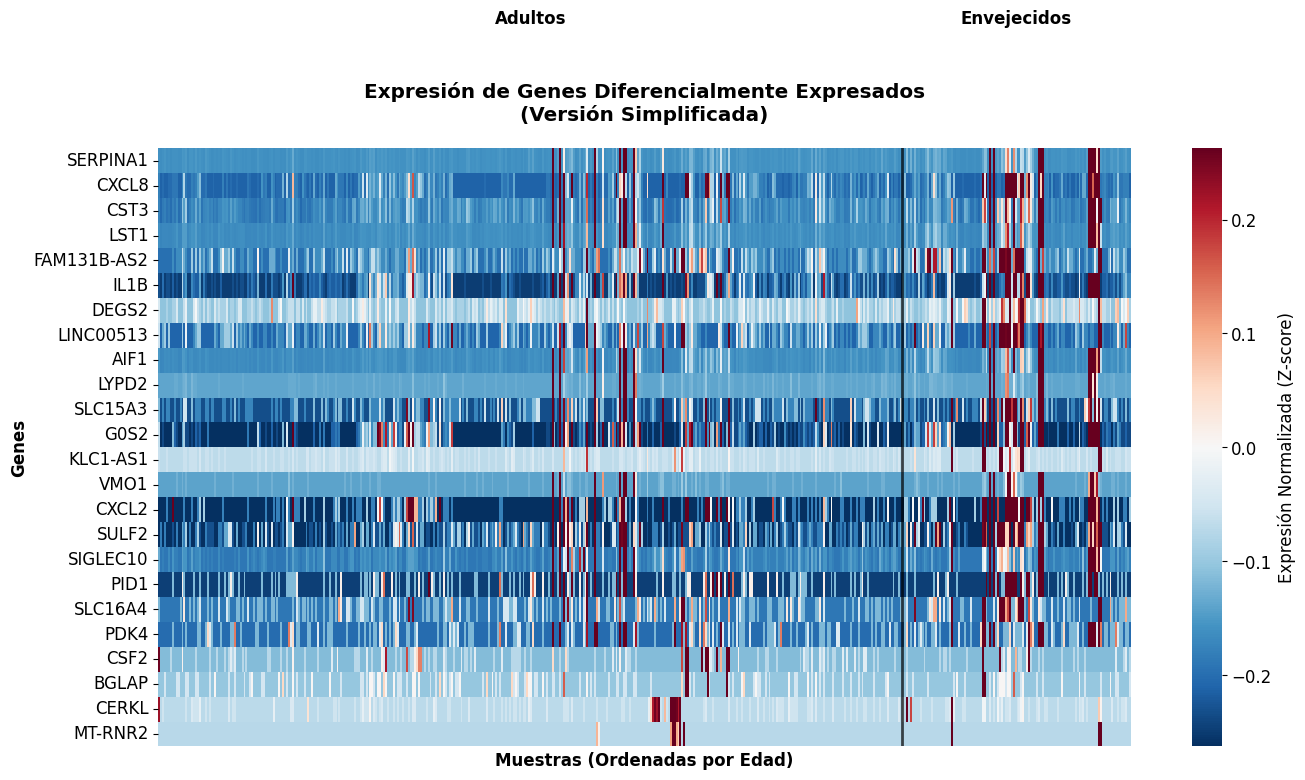

In [75]:
expr_data = plot_simple_heatmap_backup(pb, sig_genes, n_top=40)

🔬 Creando heatmap de genes diferencialmente expresados...
📊 Forma de pb: (502, 6745)
🧬 Número de genes significativos: 48
🔝 Genes seleccionados: 24 (20 up, 4 down)

📋 Estadísticas antes de la limpieza:
   NaN valores: 0
   Inf valores: 0
   Rango original: 0.00 a 998641.00
📈 Rango después de scaling: -0.28 a 22.24
👥 Grupos de edad encontrados: ['old' 'adult']
🇪🇸 Traducidos a: ['envejecidos' 'adultos']
🎯 Escala robusta: -4.74 a 4.74
🔄 Creando clustermap...
✅ Clustermap creado exitosamente
✅ Títulos y etiquetas configurados
✅ Leyenda configurada
✅ Colorbar configurado
✅ Información añadida
✅ Layout ajustado
💾 Heatmap guardado en: /app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/heatmap_genes_DE_corregido.png


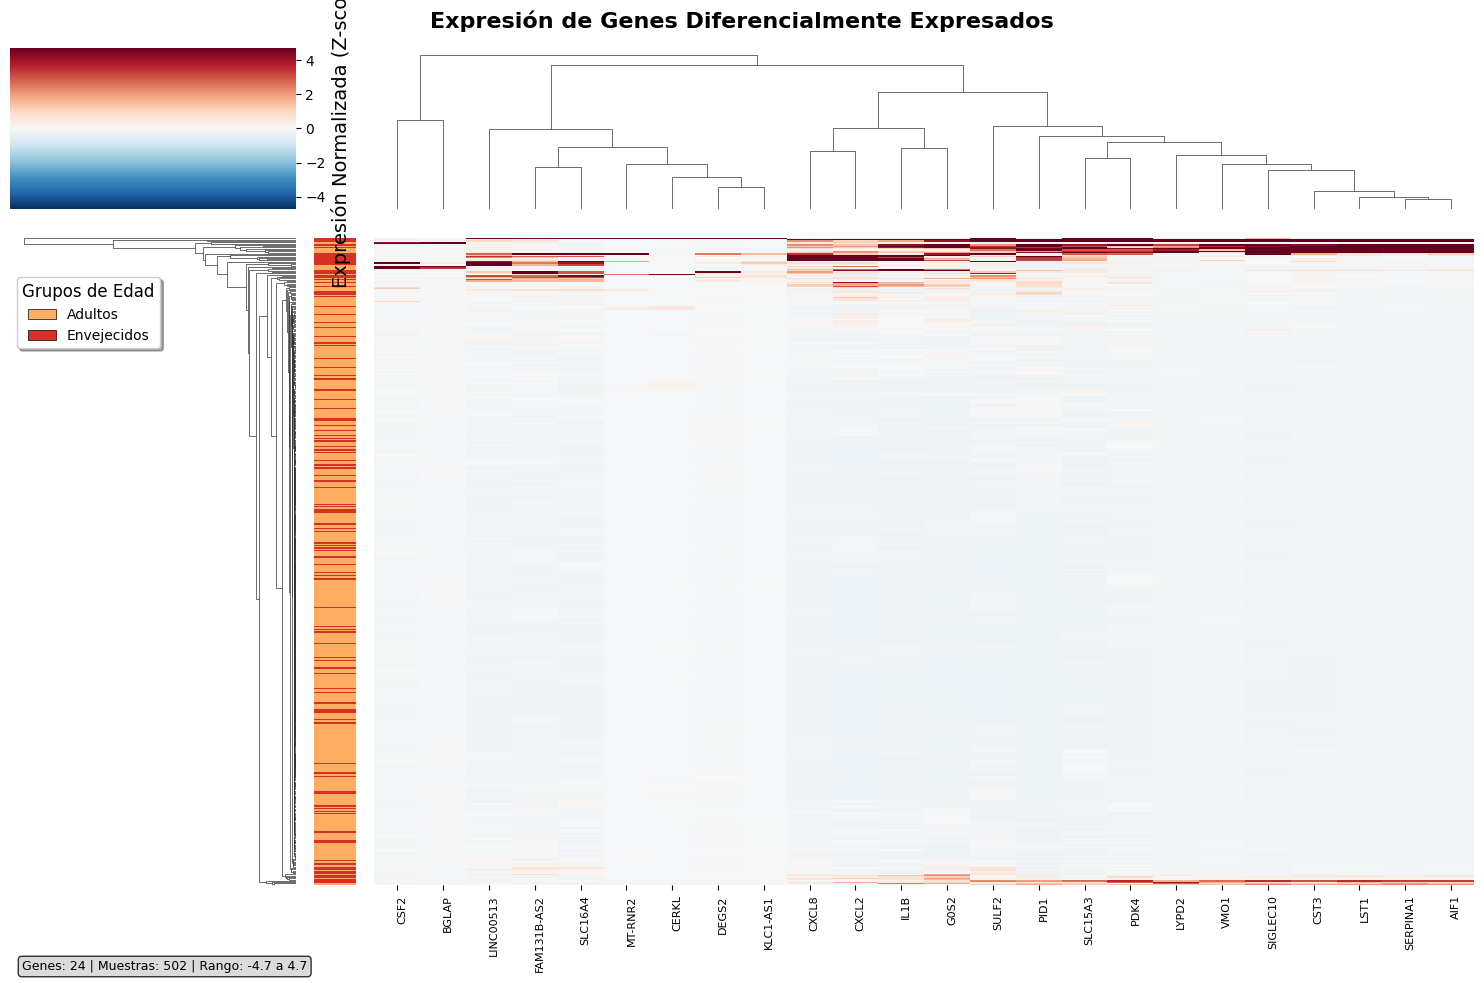

👀 Heatmap mostrado

✅ Heatmap creado exitosamente!
📊 Estadísticas finales:
   Rango de datos: -0.28 a 22.24
   Media: 0.000
   Desviación estándar: 1.001


,SERPINA1,CXCL8,CST3,LST1,FAM131B-AS2,IL1B,DEGS2,LINC00513,AIF1,LYPD2,...,CXCL2,SULF2,SIGLEC10,PID1,SLC16A4,PDK4,CSF2,BGLAP,CERKL,MT-RNR2
old-1,-0.149780,-0.212676,0.115817,-0.153889,18.692611,-0.248259,21.670740,14.563634,-0.158967,-0.125496,...,-0.266268,7.082923,1.597431,-0.247133,16.509002,12.864378,-0.114359,-0.100956,21.773423,20.063766
adult-H1,-0.155549,-0.201561,-0.190915,-0.164669,-0.027388,-0.248259,-0.084575,-0.210494,-0.160002,-0.138315,...,-0.266268,-0.230312,-0.107477,-0.116129,0.026497,-0.203005,-0.114359,-0.100956,0.628060,0.305002
adult-H2,-0.162759,-0.212676,-0.202249,-0.170957,-0.130245,-0.248259,-0.105656,-0.210494,-0.170351,-0.138315,...,-0.266268,-0.230312,-0.190354,-0.247133,-0.190378,-0.203005,-0.114359,-0.100956,0.208879,0.060080
adult-H3,-0.162759,-0.212676,-0.203666,-0.170059,-0.130245,-0.248259,-0.084575,-0.210494,-0.170351,-0.138315,...,-0.266268,-0.278425,-0.190354,-0.247133,-0.190378,-0.203005,-0.114359,-0.100956,0.255455,0.097805
adult-H4,-0.152664,-0.212676,-0.182414,-0.152990,0.658327,-0.232439,-0.021333,-0.016608,-0.168281,-0.131906,...,-0.266268,-0.134085,-0.060118,-0.116129,0.098789,0.306114,-0.114359,-0.100956,4.944074,2.449716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
adult-P-HC018,-0.161317,-0.212676,-0.193748,-0.171855,-0.130245,-0.248259,-0.105656,-0.132939,-0.169316,-0.138315,...,-0.266268,-0.278425,-0.166675,-0.247133,-0.045794,-0.203005,-0.114359,-0.100956,0.084677,-0.071989
adult-P-HC001,-0.159875,-0.168214,-0.200124,-0.172754,-0.198816,-0.153342,-0.105656,-0.171717,-0.170351,-0.138315,...,-0.266268,-0.278425,-0.178514,-0.247133,-0.190378,-0.203005,-0.114359,-0.100956,-0.055050,-0.071989
adult-P-HC002,-0.162759,-0.212676,-0.202957,-0.172754,-0.198816,-0.248259,-0.105656,-0.210494,-0.170351,-0.138315,...,-0.177630,-0.230312,-0.190354,-0.247133,-0.190378,-0.203005,-0.114359,-0.100956,-0.070575,-0.071989
adult-P-HC003,-0.158433,-0.212676,-0.190206,-0.169160,-0.095959,-0.248259,-0.105656,-0.171717,-0.168281,-0.138315,...,-0.266268,-0.278425,-0.154835,-0.247133,-0.118086,-0.118152,-0.114359,-0.100956,0.038102,-0.071989


In [76]:
plot_top_genes_heatmap_corrected(pb, sig_genes, n_top=40)  # En lugar de 80

Verificando datos de entrada:
Forma de pb: (502, 6745)
Número de genes significativos: 48

Estadísticas antes de la limpieza:
NaN valores: 0
Inf valores: 0


<Figure size 1500x1000 with 0 Axes>

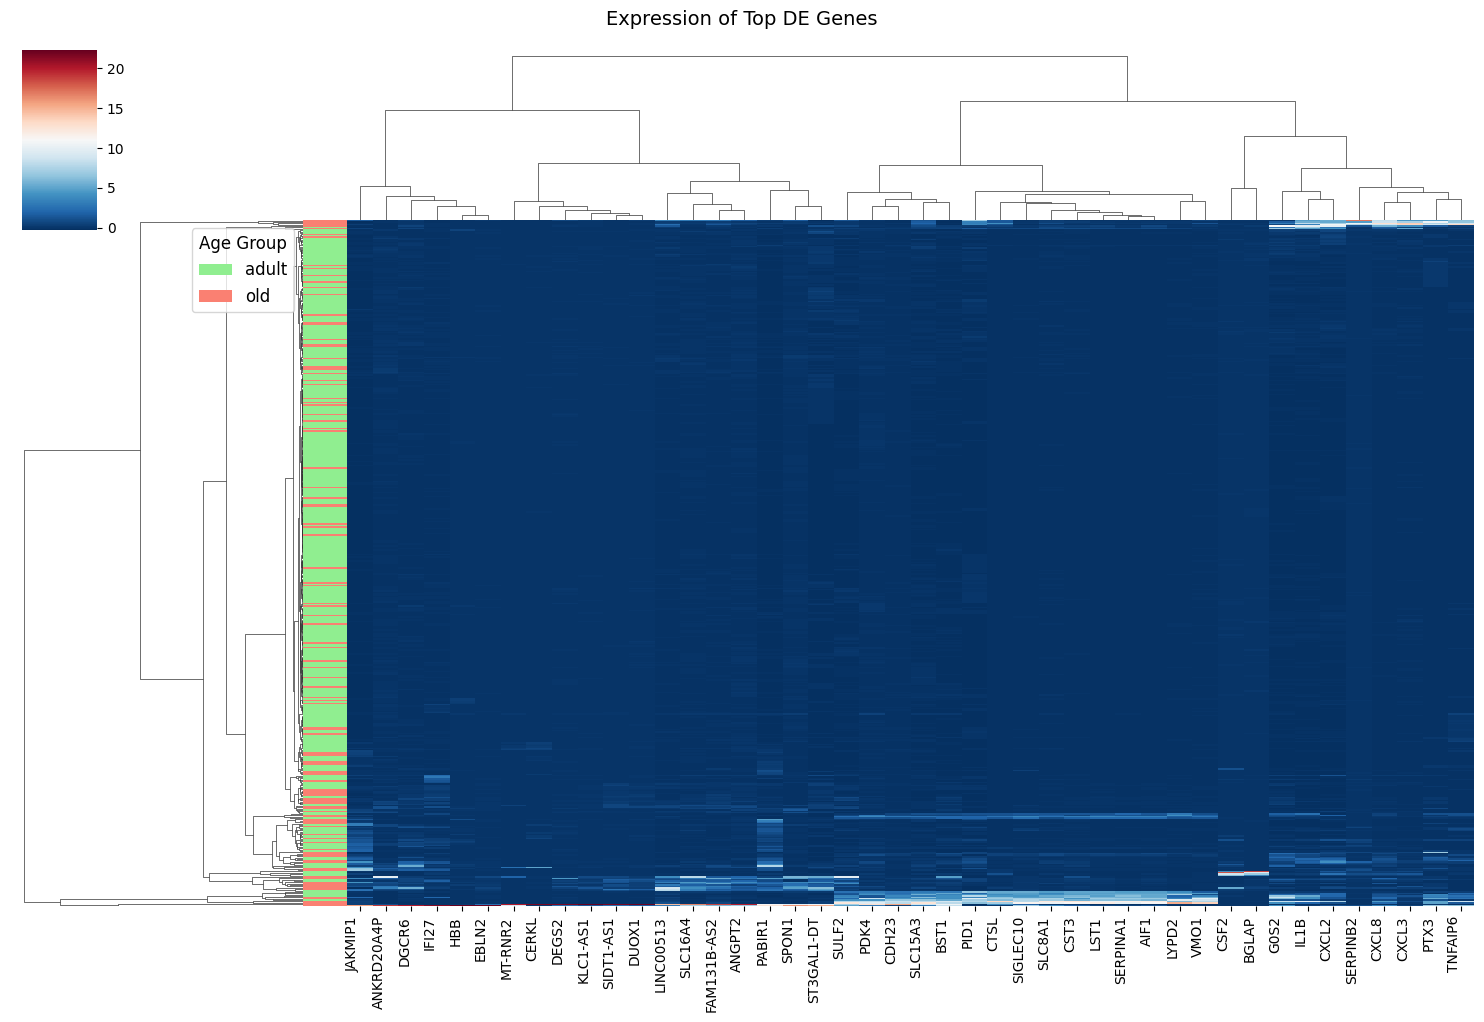


Estadísticas finales:
         SERPINA1         CXCL8        CST3          LST1   FAM131B-AS2  \
count  502.000000  5.020000e+02  502.000000  5.020000e+02  5.020000e+02   
mean     0.000000  2.830848e-17    0.000000  1.415424e-17  3.538559e-17   
std      1.000998  1.000998e+00    1.000998  1.000998e+00  1.000998e+00   
min     -0.162759 -2.126760e-01   -0.203666 -1.727537e-01 -1.988161e-01   
25%     -0.159875 -2.126760e-01   -0.182414 -1.655670e-01 -1.988161e-01   
50%     -0.156991 -1.904452e-01   -0.164704 -1.610754e-01 -1.645304e-01   
75%     -0.151222 -1.348682e-01   -0.137254 -1.523166e-01 -9.595901e-02   
max     11.694404  1.292572e+01   12.429718  1.194665e+01  1.869261e+01   

               IL1B         DEGS2     LINC00513          AIF1       LYPD2  \
count  5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  502.000000   
mean   1.415424e-17  1.415424e-17  2.830848e-17 -1.415424e-17    0.000000   
std    1.000998e+00  1.000998e+00  1.000998e+00  1.000998e+00    1.000

In [77]:
def plot_top_genes_heatmap(pb, sig_genes, n_top=80):
    """
    Crear heatmap de los top genes con manejo de valores no finitos
    """
    print("Verificando datos de entrada:")
    print(f"Forma de pb: {pb.shape}")
    print(f"Número de genes significativos: {len(sig_genes)}")
    
    # Seleccionar top genes
    top_up = sig_genes[sig_genes['log2FoldChange'] > 0].head(n_top//2).index
    top_down = sig_genes[sig_genes['log2FoldChange'] < 0].head(n_top//2).index
    top_genes = list(top_up) + list(top_down)
    
    try:
        # Obtener datos de expresión
        gene_indices = [pb.var_names.get_loc(g) for g in top_genes]
        
        if sparse.issparse(pb.X):
            expr_matrix = pb.X[:, gene_indices].toarray()
        else:
            expr_matrix = pb.X[:, gene_indices]
        
        # Crear DataFrame
        expr_data = pd.DataFrame(
            expr_matrix,
            columns=top_genes,
            index=pb.obs_names
        )
        
        # Verificar y manejar valores no finitos
        print("\nEstadísticas antes de la limpieza:")
        print("NaN valores:", expr_data.isna().sum().sum())
        print("Inf valores:", np.isinf(expr_data).sum().sum())
        
        # Reemplazar valores no finitos
        expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
        expr_data = expr_data.fillna(expr_data.mean())
        
        # Normalizar datos
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        expr_data_scaled = pd.DataFrame(
            scaler.fit_transform(expr_data),
            columns=expr_data.columns,
            index=expr_data.index
        )
        
        # Crear vector de colores
        colors = pd.Categorical(pb.obs['age_group'])
        color_map = {'adult': 'lightgreen', 'old': 'salmon'}
        row_colors = [color_map.get(x, 'gray') for x in colors]
        
        # Crear heatmap
        plt.figure(figsize=(15, 10))
        g = sns.clustermap(
            expr_data_scaled,
            row_cluster=True,
            col_cluster=True,
            cmap='RdBu_r',
            z_score=None,  # Ya realizamos la normalización
            row_colors=row_colors,
            xticklabels=True,
            yticklabels=False,
            figsize=(15, 10),
            method='ward'  # Usar método ward para clustering
        )
        
        # Ajustar etiquetas
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
        
        # Agregar leyenda
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, label=group) 
                         for group, color in color_map.items()]
        g.ax_row_dendrogram.legend(handles=legend_elements, 
                                 title='Age Group', 
                                 bbox_to_anchor=(1, 1))
        
        # Título
        g.fig.suptitle('Expression of Top DE Genes', y=1.02, fontsize=14)
        
        # Guardar y mostrar
        plt.savefig('/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/top_genes_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        return expr_data_scaled
        
    except Exception as e:
        print(f"Error durante la creación del heatmap: {str(e)}")
        print("Detalles adicionales:")
        import traceback
        print(traceback.format_exc())

# Ejecutar con manejo de errores
try:
    expr_data = plot_top_genes_heatmap(pb, sig_genes, n_top=80)
    
    # Verificar resultado
    if expr_data is not None:
        print("\nEstadísticas finales:")
        print(expr_data.describe())
except Exception as e:
    print(f"Error en la ejecución principal: {str(e)}")

Verificando datos de entrada:
Forma de pb: (502, 6745)
Número de genes significativos: 48

Estadísticas antes de la limpieza:
NaN valores: 0
Inf valores: 0


<Figure size 1500x1000 with 0 Axes>

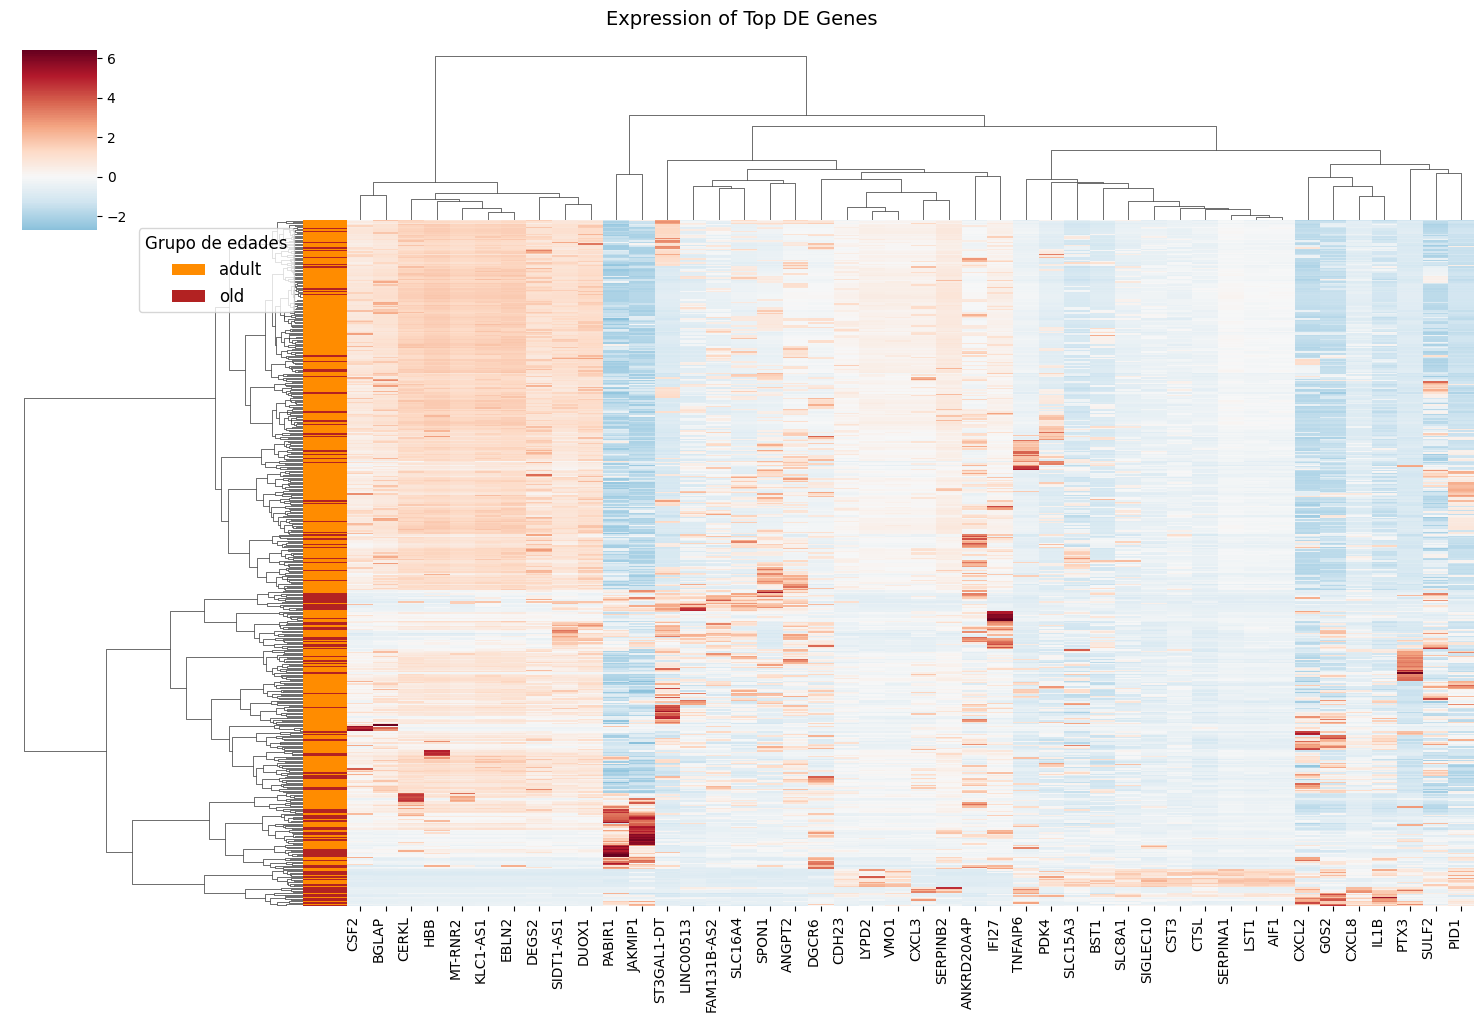


Estadísticas finales:
         SERPINA1         CXCL8        CST3          LST1   FAM131B-AS2  \
count  502.000000  5.020000e+02  502.000000  5.020000e+02  5.020000e+02   
mean     0.000000  2.830848e-17    0.000000  1.415424e-17  3.538559e-17   
std      1.000998  1.000998e+00    1.000998  1.000998e+00  1.000998e+00   
min     -0.162759 -2.126760e-01   -0.203666 -1.727537e-01 -1.988161e-01   
25%     -0.159875 -2.126760e-01   -0.182414 -1.655670e-01 -1.988161e-01   
50%     -0.156991 -1.904452e-01   -0.164704 -1.610754e-01 -1.645304e-01   
75%     -0.151222 -1.348682e-01   -0.137254 -1.523166e-01 -9.595901e-02   
max     11.694404  1.292572e+01   12.429718  1.194665e+01  1.869261e+01   

               IL1B         DEGS2     LINC00513          AIF1       LYPD2  \
count  5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  502.000000   
mean   1.415424e-17  1.415424e-17  2.830848e-17 -1.415424e-17    0.000000   
std    1.000998e+00  1.000998e+00  1.000998e+00  1.000998e+00    1.000

In [78]:
def plot_top_genes_heatmap(pb, sig_genes, n_top=80):
    """
    Crear heatmap de los top genes con manejo de valores no finitos
    """
    print("Verificando datos de entrada:")
    print(f"Forma de pb: {pb.shape}")
    print(f"Número de genes significativos: {len(sig_genes)}")
    
    # Seleccionar top genes
    top_up = sig_genes[sig_genes['log2FoldChange'] > 0].head(n_top//2).index
    top_down = sig_genes[sig_genes['log2FoldChange'] < 0].head(n_top//2).index
    top_genes = list(top_up) + list(top_down)
    
    try:
        # Obtener datos de expresión
        gene_indices = [pb.var_names.get_loc(g) for g in top_genes]
        
        if sparse.issparse(pb.X):
            expr_matrix = pb.X[:, gene_indices].toarray()
        else:
            expr_matrix = pb.X[:, gene_indices]
        
        # Crear DataFrame
        expr_data = pd.DataFrame(
            expr_matrix,
            columns=top_genes,
            index=pb.obs_names
        )
        
        # Verificar y manejar valores no finitos
        print("\nEstadísticas antes de la limpieza:")
        print("NaN valores:", expr_data.isna().sum().sum())
        print("Inf valores:", np.isinf(expr_data).sum().sum())
        
        # Reemplazar valores no finitos
        expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
        expr_data = expr_data.fillna(expr_data.mean())
        
        # Normalizar datos
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        expr_data_scaled = pd.DataFrame(
            scaler.fit_transform(expr_data),
            columns=expr_data.columns,
            index=expr_data.index
        )
        
        # Crear vector de colores
        colors = pd.Categorical(pb.obs['age_group'])
        color_map = {'adult': '#FF8C00', 'old': '#B22222'}
        row_colors = [color_map.get(x, 'gray') for x in colors]
        
        # Crear heatmap
        plt.figure(figsize=(15, 10))
        g = sns.clustermap(
            expr_data_scaled,
            row_cluster=True,
            col_cluster=True,
            cmap='RdBu_r',
            z_score=0,  # Ya realizamos la normalización
            row_colors=row_colors,
            xticklabels=True,
            yticklabels=False,
            figsize=(15, 10),
            method='ward',  # Usar método ward para clustering
            center=0
        )
        
        # Ajustar etiquetas
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
        
        # Agregar leyenda
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, label=group) 
                         for group, color in color_map.items()]
        g.ax_row_dendrogram.legend(handles=legend_elements, 
                                 title='Grupo de edades', 
                                 bbox_to_anchor=(1, 1))
        
        # Título
        g.fig.suptitle('Expression of Top DE Genes', y=1.02, fontsize=14)
        
        # Guardar y mostrar
        plt.savefig('/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/top_genes_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        return expr_data_scaled
        
    except Exception as e:
        print(f"Error durante la creación del heatmap: {str(e)}")
        print("Detalles adicionales:")
        import traceback
        print(traceback.format_exc())

# Ejecutar con manejo de errores
try:
    expr_data = plot_top_genes_heatmap(pb, sig_genes, n_top=80)
    
    # Verificar resultado
    if expr_data is not None:
        print("\nEstadísticas finales:")
        print(expr_data.describe())
except Exception as e:
    print(f"Error en la ejecución principal: {str(e)}")

Verificando datos de entrada:
Forma de pb: (502, 6745)
Número de genes significativos: 48

Estadísticas antes de la limpieza:
NaN valores: 0
Inf valores: 0


<Figure size 1500x1000 with 0 Axes>

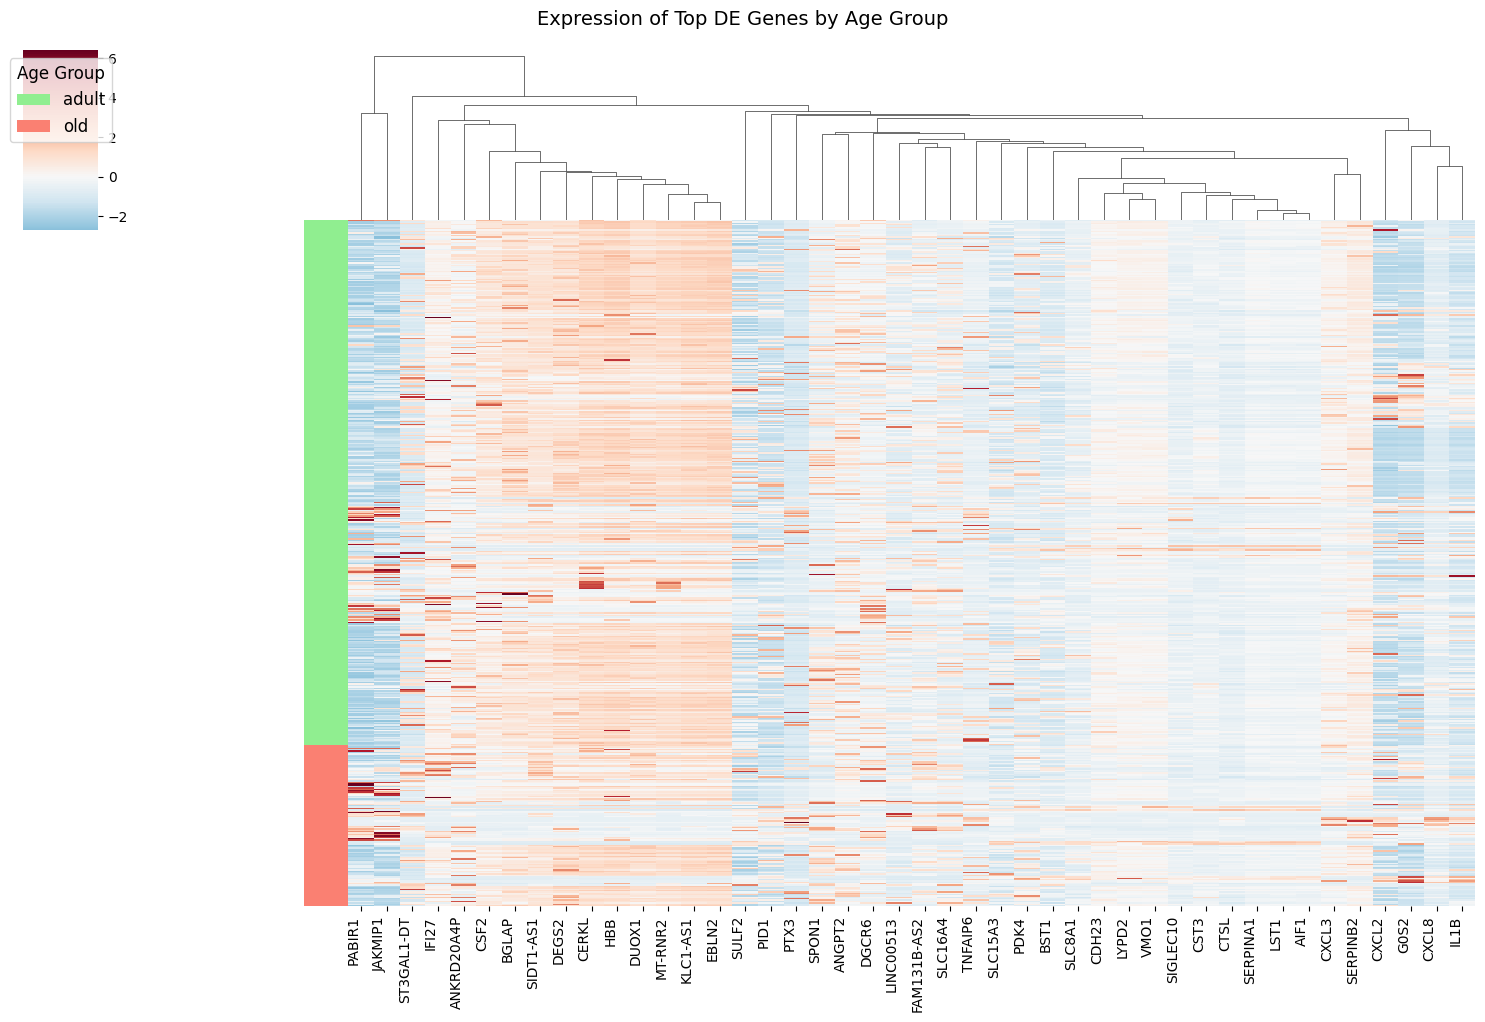


Estadísticas finales:
           SERPINA1       CXCL8          CST3          LST1   FAM131B-AS2  \
count  5.020000e+02  502.000000  5.020000e+02  5.020000e+02  5.020000e+02   
mean  -3.538559e-18    0.000000 -7.077119e-18 -1.061568e-17  4.246271e-17   
std    1.000998e+00    1.000998  1.000998e+00  1.000998e+00  1.000998e+00   
min   -1.627592e-01   -0.212676 -2.036656e-01 -1.727537e-01 -1.988161e-01   
25%   -1.598749e-01   -0.212676 -1.824140e-01 -1.655670e-01 -1.988161e-01   
50%   -1.569907e-01   -0.190445 -1.647043e-01 -1.610754e-01 -1.645304e-01   
75%   -1.512222e-01   -0.134868 -1.372543e-01 -1.523166e-01 -9.595901e-02   
max    1.169440e+01   12.925718  1.242972e+01  1.194665e+01  1.869261e+01   

             IL1B         DEGS2   LINC00513          AIF1         LYPD2  ...  \
count  502.000000  5.020000e+02  502.000000  5.020000e+02  5.020000e+02  ...   
mean     0.000000  1.415424e-17    0.000000  1.415424e-17 -7.077119e-18  ...   
std      1.000998  1.000998e+00    1.000998

In [79]:
def plot_top_genes_heatmap(pb, sig_genes, n_top=80):
    """
    Crear heatmap de los top genes con muestras agrupadas por age_group
    """
    print("Verificando datos de entrada:")
    print(f"Forma de pb: {pb.shape}")
    print(f"Número de genes significativos: {len(sig_genes)}")
    
    # Seleccionar top genes
    top_up = sig_genes[sig_genes['log2FoldChange'] > 0].head(n_top//2).index
    top_down = sig_genes[sig_genes['log2FoldChange'] < 0].head(n_top//2).index
    top_genes = list(top_up) + list(top_down)
    
    try:
        # Obtener datos de expresión
        gene_indices = [pb.var_names.get_loc(g) for g in top_genes]
        
        if sparse.issparse(pb.X):
            expr_matrix = pb.X[:, gene_indices].toarray()
        else:
            expr_matrix = pb.X[:, gene_indices]
        
        # Crear DataFrame
        expr_data = pd.DataFrame(
            expr_matrix,
            columns=top_genes,
            index=pb.obs_names
        )
        
        # Añadir información de grupo de edad
        expr_data['age_group'] = pb.obs['age_group']
        
        # Ordenar por age_group
        expr_data = expr_data.sort_values('age_group')
        
        # Eliminar la columna age_group antes de la normalización
        age_groups = expr_data['age_group']
        expr_data = expr_data.drop('age_group', axis=1)
        
        # Verificar y manejar valores no finitos
        print("\nEstadísticas antes de la limpieza:")
        print("NaN valores:", expr_data.isna().sum().sum())
        print("Inf valores:", np.isinf(expr_data).sum().sum())
        
        # Reemplazar valores no finitos
        expr_data = expr_data.replace([np.inf, -np.inf], np.nan)
        expr_data = expr_data.fillna(expr_data.mean())
        
        # Normalizar datos
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        expr_data_scaled = pd.DataFrame(
            scaler.fit_transform(expr_data),
            columns=expr_data.columns,
            index=expr_data.index
        )
        
        # Crear vector de colores basado en el orden actual
        color_map = {'adult': 'lightgreen', 'old': 'salmon'}
        row_colors = [color_map.get(x, 'gray') for x in age_groups]
        
        # Crear heatmap
        plt.figure(figsize=(15, 10))
        g = sns.clustermap(
            expr_data_scaled,
            row_cluster=False,  # Desactivar clustering de filas para mantener el orden por grupo
            col_cluster=True,
            cmap='RdBu_r',
            z_score=0,
            row_colors=row_colors,
            xticklabels=True,
            yticklabels=False,
            figsize=(15, 10),
            center=0
        )
        
        # Ajustar etiquetas
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
        
        # Agregar leyenda
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=color, label=group) 
                         for group, color in color_map.items()]
        plt.legend(handles=legend_elements, 
                  title='Age Group',
                  bbox_to_anchor=(1.3, 1))
        
        # Título
        g.fig.suptitle('Expression of Top DE Genes by Age Group', y=1.02, fontsize=14)
        
        # Guardar y mostrar
        plt.savefig('/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/top_genes_heatmap.png', 
                    dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        return expr_data_scaled
        
    except Exception as e:
        print(f"Error durante la creación del heatmap: {str(e)}")
        print("Detalles adicionales:")
        import traceback
        print(traceback.format_exc())

# Ejecutar con manejo de errores
try:
    expr_data = plot_top_genes_heatmap(pb, sig_genes, n_top=80)
    
    # Verificar resultado
    if expr_data is not None:
        print("\nEstadísticas finales:")
        print(expr_data.describe())
except Exception as e:
    print(f"Error en la ejecución principal: {str(e)}")

Verificando datos de entrada:
Forma de pb: (502, 6745)
Número de genes significativos: 48

Genes seleccionados (20):
['SERPINA1', 'CXCL8', 'CST3', 'LST1', 'FAM131B-AS2', 'IL1B', 'DEGS2', 'LINC00513', 'AIF1', 'LYPD2', 'SLC15A3', 'G0S2', 'KLC1-AS1', 'VMO1', 'CXCL2', 'SULF2', 'SIGLEC10', 'PID1', 'SLC16A4', 'PDK4']

Índices de genes encontrados: [4770, 3854, 888, 4957, 5205, 1916, 3784, 5220, 4956, 4777, 1285, 1834, 5341, 4417, 521, 4713, 2696, 3068, 3806, 21]

Forma de matriz de expresión: (502, 20)

Gráfico guardado en: /app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/gene_correlations.png


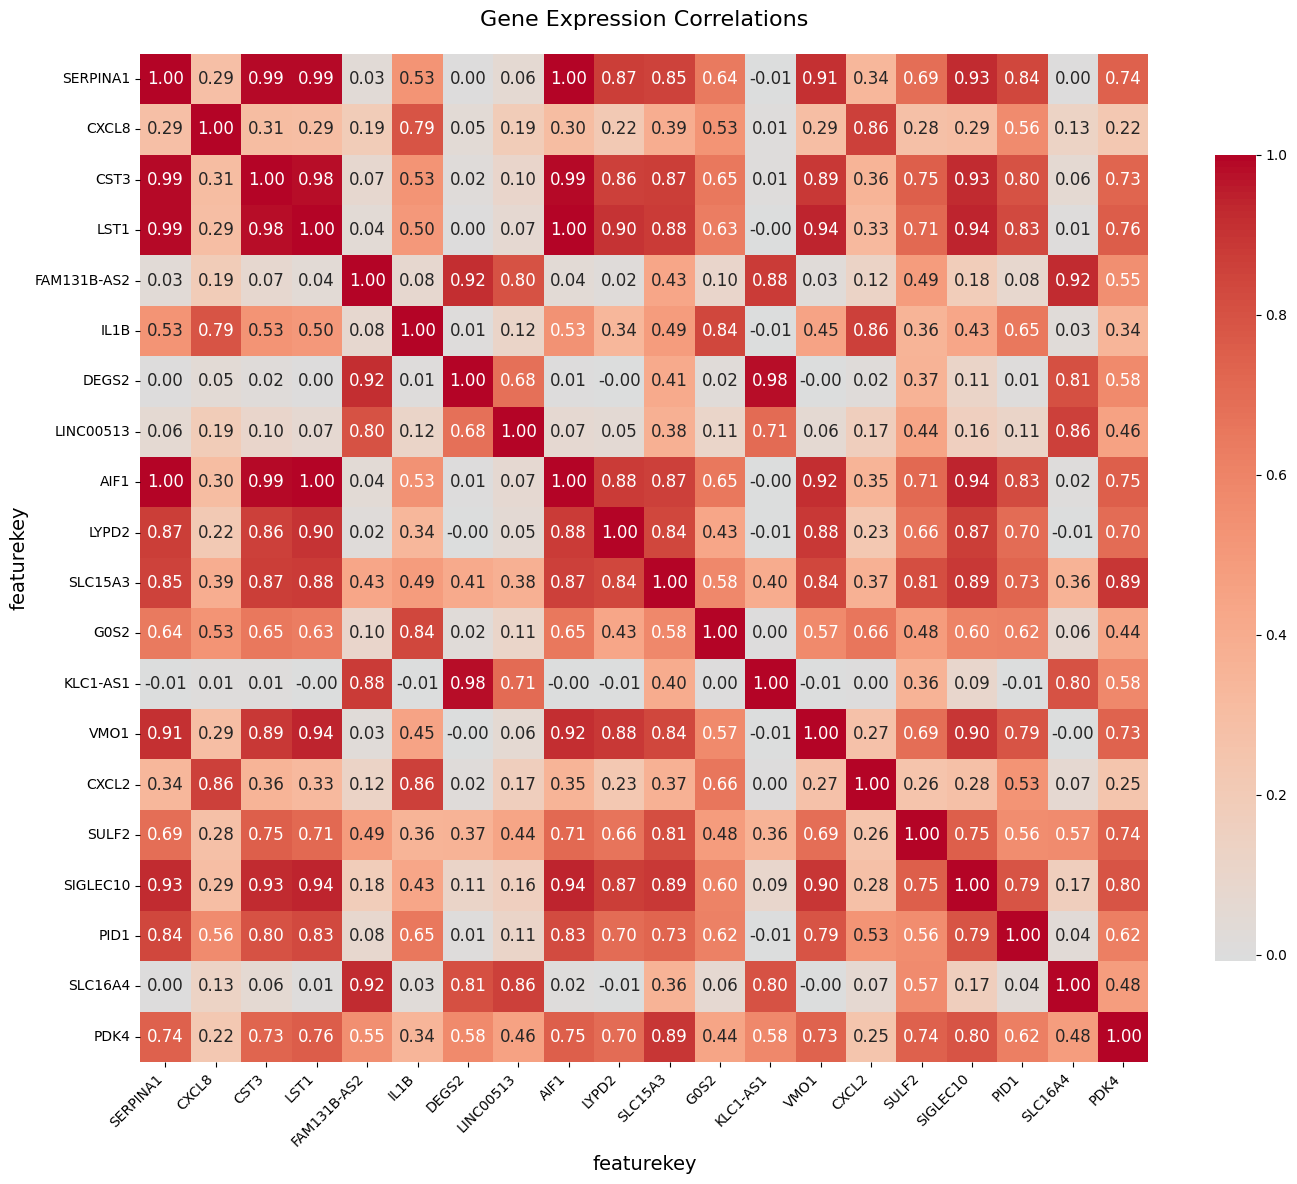


Top 5 correlaciones positivas:
featurekey  featurekey
SERPINA1    AIF1          0.995823
AIF1        SERPINA1      0.995823
LST1        AIF1          0.995087
AIF1        LST1          0.995087
SERPINA1    LST1          0.990751
dtype: float64

Top 5 correlaciones negativas:
featurekey  featurekey
LYPD2       SLC16A4      -0.007801
SLC16A4     LYPD2        -0.007801
KLC1-AS1    VMO1         -0.007038
VMO1        KLC1-AS1     -0.007038
LYPD2       KLC1-AS1     -0.006934
dtype: float64


In [80]:
def plot_gene_correlations(pb, sig_genes, n_top=80, output_path='/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/gene_correlations.png'):
    """
    Crear heatmap de correlaciones entre genes con verificación de datos
    """
    print("Verificando datos de entrada:")
    print(f"Forma de pb: {pb.shape}")
    print(f"Número de genes significativos: {len(sig_genes)}")
    
    try:
        # Seleccionar top genes
        top_genes = sig_genes.head(n_top).index
        print(f"\nGenes seleccionados ({len(top_genes)}):")
        print(top_genes.tolist())
        
        # Obtener índices de genes
        gene_indices = [pb.var_names.get_loc(g) for g in top_genes]
        print("\nÍndices de genes encontrados:", gene_indices)
        
        # Obtener datos de expresión
        if sparse.issparse(pb.X):
            expr_matrix = pb.X[:, gene_indices].toarray()
        else:
            expr_matrix = pb.X[:, gene_indices]
            
        expr_data = pd.DataFrame(
            expr_matrix,
            columns=top_genes,
            index=pb.obs_names
        )
        
        print("\nForma de matriz de expresión:", expr_data.shape)
        
        # Calcular correlaciones
        corr = expr_data.corr()
        
        # Crear heatmap
        plt.figure(figsize=(15, 12))
        sns.heatmap(
            corr, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',  # Mostrar solo 2 decimales
            square=True,  # Hacer celdas cuadradas
            cbar_kws={"shrink": .8}  # Ajustar tamaño de la barra de color
        )
        
        # Ajustar etiquetas
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        
        # Título
        plt.title('Gene Expression Correlations', pad=20)
        
        # Ajustar layout
        plt.tight_layout()
        
        # Guardar
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"\nGráfico guardado en: {output_path}")
        
        # Mostrar
        plt.show()
        plt.close()
        
        # Retornar matriz de correlación para análisis adicional
        return corr
        
    except Exception as e:
        print(f"Error durante la creación del heatmap de correlación: {str(e)}")
        print("Detalles adicionales:")
        import traceback
        print(traceback.format_exc())
        return None

# Ejecutar la función
corr_matrix = plot_gene_correlations(pb, sig_genes, n_top=20)

# Si tenemos la matriz de correlación, podemos hacer análisis adicional
if corr_matrix is not None:
    # Encontrar las correlaciones más fuertes (positivas y negativas)
    corr_flat = corr_matrix.unstack()
    corr_flat = corr_flat[corr_flat != 1.0]  # Eliminar autocorrelaciones
    
    print("\nTop 5 correlaciones positivas:")
    print(corr_flat.nlargest(5))
    
    print("\nTop 5 correlaciones negativas:")
    print(corr_flat.nsmallest(5))

=== Análisis PCA ===


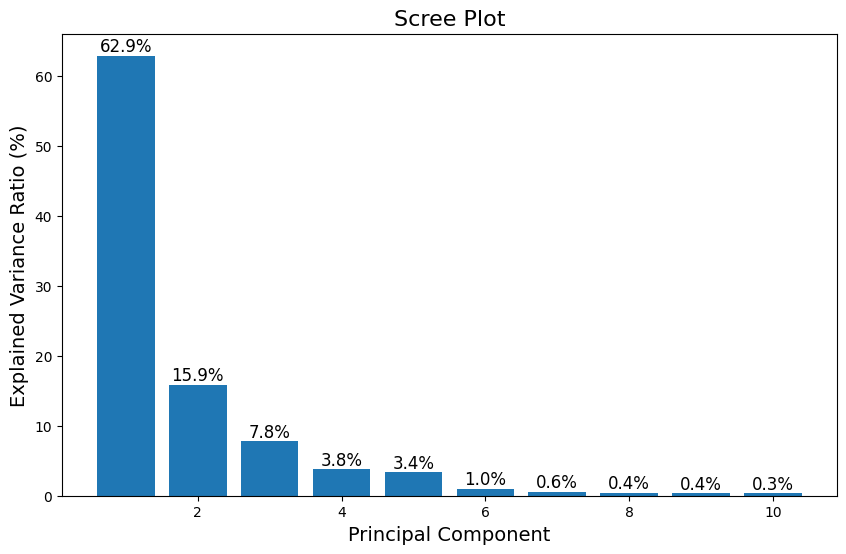

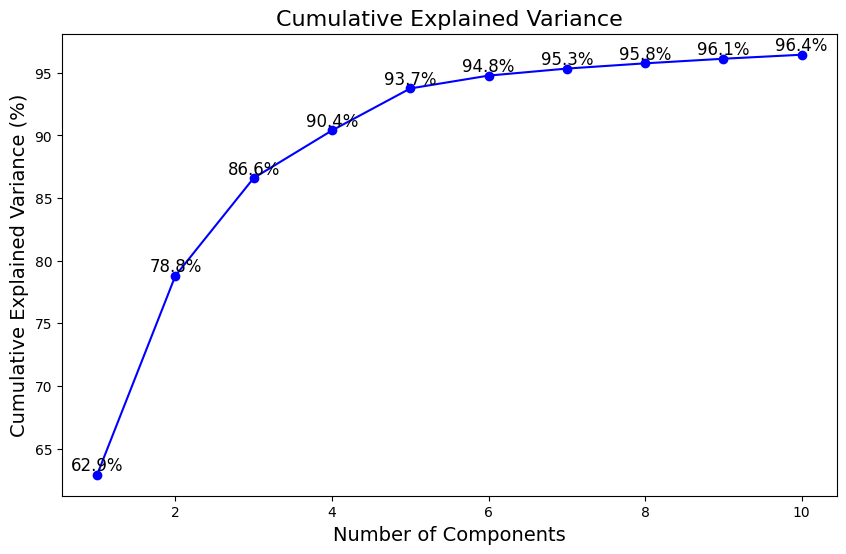

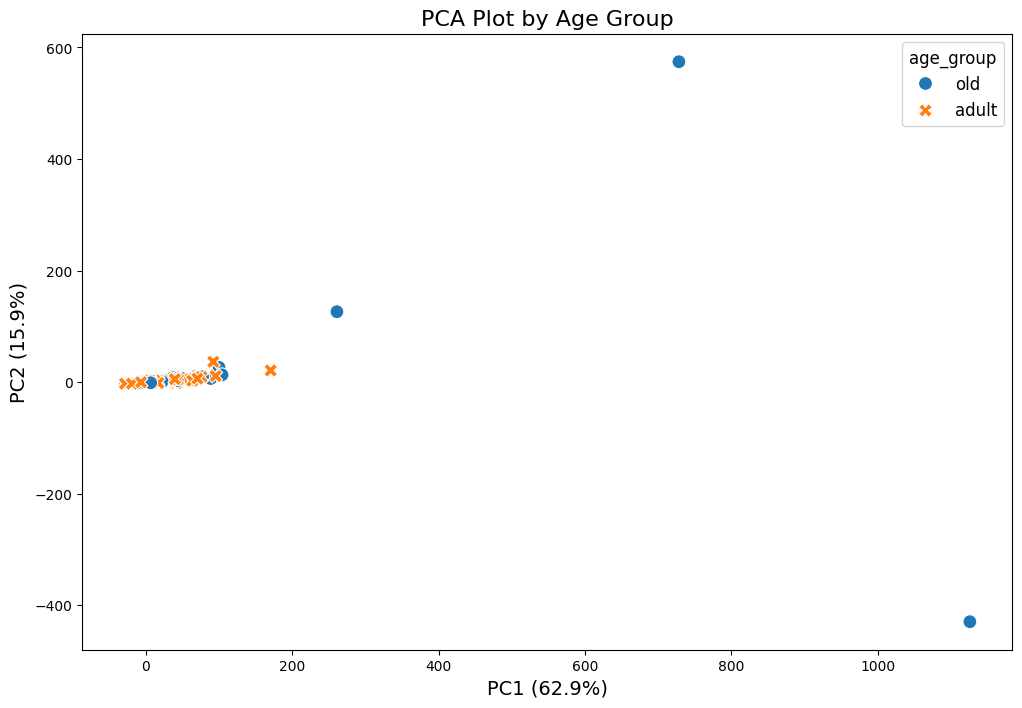


Top 10 genes contributing to PC1:
featurekey
TCP1       0.015282
SH2D1A     0.015257
GHITM      0.015253
TMEM222    0.015252
PTPN4      0.015241
DPP8       0.015229
ZDHHC6     0.015228
KDM5A      0.015226
TRIM22     0.015223
CTNNBL1    0.015219
Name: PC1, dtype: float64

Top 10 genes contributing to PC2:
featurekey
WDR90       0.024646
ODCP        0.024614
RPL4P2      0.024611
ST13P3      0.024611
TTC9B       0.024610
CENPUP1     0.024607
RPL19P16    0.024596
PNRC2P1     0.024588
TRIT1       0.024558
UBE2SP2     0.024550
Name: PC2, dtype: float64


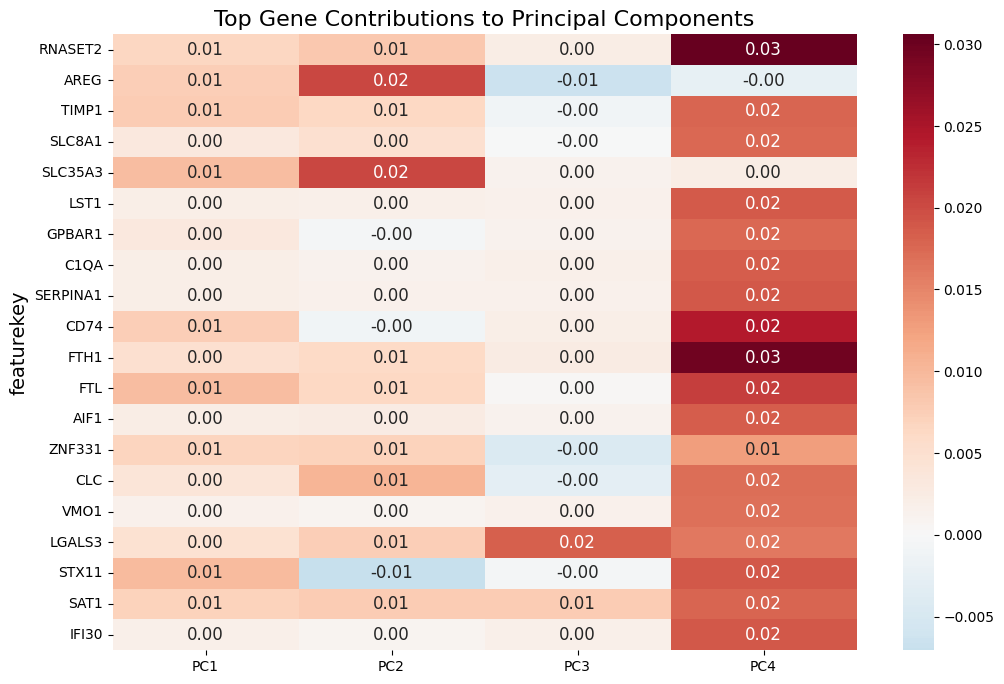

In [81]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def perform_pca_analysis(pb, n_components=10):
    """
    Realizar análisis PCA completo
    """
    print("=== Análisis PCA ===")
    
    # Preparar datos
    if sparse.issparse(pb.X):
        X = pb.X.toarray()
    else:
        X = pb.X
        
    # Normalizar datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Realizar PCA
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(X_scaled)
    
    # Crear DataFrame con resultados
    pca_df = pd.DataFrame(
        data=pca_result,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=pb.obs_names
    )
    
    # Agregar metadata
    pca_df = pca_df.join(pb.obs)
    
    # 1. Scree plot
    plt.figure(figsize=(10, 6))
    variance_ratio = pca.explained_variance_ratio_ * 100
    plt.bar(range(1, n_components + 1), variance_ratio)
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio (%)')
    plt.title('Scree Plot')
    
    # Añadir valores exactos
    for i, v in enumerate(variance_ratio):
        plt.text(i + 1, v, f'{v:.1f}%', ha='center', va='bottom')
    
    plt.savefig('/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/pca_scree.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Varianza acumulada
    plt.figure(figsize=(10, 6))
    cumulative_variance = np.cumsum(variance_ratio)
    plt.plot(range(1, n_components + 1), cumulative_variance, 'bo-')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance (%)')
    plt.title('Cumulative Explained Variance')
    
    # Añadir valores exactos
    for i, v in enumerate(cumulative_variance):
        plt.text(i + 1, v, f'{v:.1f}%', ha='center', va='bottom')
    
    plt.savefig('/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/pca_cumulative.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. PCA plot coloreado por grupo de edad
    plt.figure(figsize=(12, 8))
    
    # Crear scatter plot
    sns.scatterplot(
        data=pca_df,
        x='PC1',
        y='PC2',
        hue='age_group',
        style='age_group',
        s=100
    )
    
    # Añadir etiquetas
    plt.xlabel(f'PC1 ({variance_ratio[0]:.1f}%)')
    plt.ylabel(f'PC2 ({variance_ratio[1]:.1f}%)')
    plt.title('PCA Plot by Age Group')
    
    plt.savefig('/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/pca_age_groups.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Contribución de variables
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=pb.var_names
    )
    
    # Top 10 genes que contribuyen a PC1 y PC2
    print("\nTop 10 genes contributing to PC1:")
    print(loadings['PC1'].abs().sort_values(ascending=False).head(10))
    
    print("\nTop 10 genes contributing to PC2:")
    print(loadings['PC2'].abs().sort_values(ascending=False).head(10))
    
    # 5. Heatmap de las principales contribuciones
    plt.figure(figsize=(12, 8))
    top_genes = (loadings.abs()
                .apply(lambda x: x > np.percentile(x, 90))
                .sum(axis=1)
                .sort_values(ascending=False)
                .head(20)
                .index)
    
    sns.heatmap(
        loadings.loc[top_genes, ['PC1', 'PC2', 'PC3', 'PC4']],
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f'
    )
    plt.title('Top Gene Contributions to Principal Components')
    
    plt.savefig('/app/project/restore_data/pipeline_articulo/old_vs_adult/5.analysis/deseq_bulk/pca_gene_contributions.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return pca, pca_df, loadings

# Ejecutar el análisis
pca, pca_df, loadings = perform_pca_analysis(pb)

In [82]:
print(sig_genes.index)

Index(['SERPINA1', 'CXCL8', 'CST3', 'LST1', 'FAM131B-AS2', 'IL1B', 'DEGS2',
       'LINC00513', 'AIF1', 'LYPD2', 'SLC15A3', 'G0S2', 'KLC1-AS1', 'VMO1',
       'CXCL2', 'SULF2', 'SIGLEC10', 'PID1', 'SLC16A4', 'PDK4', 'PABIR1',
       'SLC8A1', 'CXCL3', 'HBB', 'EBLN2', 'CTSL', 'PTX3', 'SPON1', 'ANGPT2',
       'ANKRD20A4P', 'JAKMIP1', 'ST3GAL1-DT', 'CSF2', 'SIDT1-AS1', 'DGCR6',
       'TNFAIP6', 'CDH23', 'BST1', 'BGLAP', 'DUOX1', 'SERPINB2', 'IFI27',
       'CERKL', 'HBA2', 'MRFAP1P1', 'IL6', 'FAM220A', 'MT-RNR2'],
      dtype='object', name='featurekey')


In [83]:
sig_genes.head(20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
SERPINA1,25.815199,2.940629,0.237045,12.405339,2.444763e-35,1.321150e-31
CXCL8,8.556232,2.033144,0.252325,8.057633,7.778581e-16,2.101773e-12
CST3,118.633573,1.198063,0.162781,7.359951,1.839771e-13,2.485530e-10
LST1,73.460945,1.690537,0.231003,7.318259,2.512086e-13,2.715063e-10
FAM131B-AS2,3.614191,1.510134,0.210303,7.180764,6.932298e-13,5.351734e-10
IL1B,6.537629,1.669227,0.237325,7.033517,2.013919e-12,1.360402e-09
DEGS2,1.865256,1.167043,0.171493,6.805190,1.009160e-11,4.544585e-09
LINC00513,2.761999,1.537797,0.227246,6.767106,1.313841e-11,5.315457e-09
AIF1,60.830887,1.690164,0.250396,6.749964,1.478819e-11,5.327691e-09


In [84]:
sig_genes.tail(20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
featurekey,,,,,,
ANGPT2,1.438676,1.101516,0.234216,4.702990,0.000003,0.000070
ANKRD20A4P,1.810243,1.125672,0.240986,4.671109,0.000003,0.000079
JAKMIP1,5.495810,1.153458,0.253014,4.558867,0.000005,0.000121
ST3GAL1-DT,0.906539,1.055072,0.248174,4.251341,0.000021,0.000367
CSF2,1.190940,-2.031524,0.483444,-4.202192,0.000026,0.000436
SIDT1-AS1,2.952281,1.299925,0.314568,4.132419,0.000036,0.000551
DGCR6,1.150021,1.132746,0.275179,4.116401,0.000038,0.000579
TNFAIP6,0.537257,1.968259,0.495053,3.975859,0.000070,0.000929
CDH23,1.260788,1.141056,0.287970,3.962415,0.000074,0.000971


In [85]:
import re

def extract_and_print_genes(index_string):
    """
    Extrae y muestra todos los genes de un Index de pandas
    """
    # Extraer todos los elementos entre comillas simples
    pattern = r"'([^']+)'"
    genes = re.findall(pattern, index_string)
    
    # Imprimir cada gen en una línea separada, numerado
    print("Lista completa de genes:")
    print("-" * 50)
    for i, gene in enumerate(genes, 1):
        print(f"{i:3d}. {gene}")
    print("-" * 50)
    print(f"Total de genes: {len(genes)}")

extract_and_print_genes(sig_genes.index)

TypeError: expected string or bytes-like object

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import random
from scipy import sparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def create_improved_pseudobulk(adata, 
                             sample_col='donor_id',
                             condition_col='age_group',
                             layer='counts',  # Especificar la capa de conteos raw
                             create_replicates=False,
                             n_replicates=2):
    """
    Crear pseudobulk mejorado asegurando conteos no negativos
    """
    pbs = []
    
    for sample in adata.obs[sample_col].unique():
        # Subset por muestra
        sample_subset = adata[adata.obs[sample_col] == sample].copy()
        
        # Usar conteos de la capa especificada o X si no existe
        if layer in sample_subset.layers:
            X = sample_subset.layers[layer]
        else:
            X = sample_subset.X
            
        # Asegurarse de que X sea una matriz densa o CSR
        if isinstance(X, np.ndarray):
            X_sum = np.array(X.sum(axis=0)).flatten()
        else:
            X_sum = np.array(X.sum(axis=0).A1).flatten()
            
        if create_replicates:
            # Código para réplicas...
            pass
        else:
            # Asegurarse de que los valores sean no negativos
            X_sum = np.maximum(X_sum, 0)
            
            bulk_adata = sc.AnnData(X = X_sum.reshape(1, -1),
                                  var = sample_subset.var)
            
            bulk_adata.obs_names = [sample]
            bulk_adata.obs[condition_col] = sample_subset.obs[condition_col].iloc[0]
            
            pbs.append(bulk_adata)
    
    return sc.concat(pbs)

# Crear nuevo pseudobulk utilizando los conteos raw
pseudo_bulk = create_improved_pseudobulk(
    adata,
    sample_col='donor_id',
    condition_col='age_group',
    layer='counts'  # Especificar la capa de conteos raw
)

# Verificar los datos antes de proceder
if sparse.issparse(pseudo_bulk.X):
    counts_matrix = pseudo_bulk.X.toarray()
else:
    counts_matrix = pseudo_bulk.X

# Crear DataFrame asegurando valores no negativos
counts = pd.DataFrame(
    np.maximum(counts_matrix, 0),  # Asegurar valores no negativos
    index=pseudo_bulk.obs_names,
    columns=pseudo_bulk.var_names
)

# Verificación de datos
print("Verificación de datos:")
print(f"Valores mínimo y máximo: {counts.values.min()}, {counts.values.max()}")
print(f"¿Hay valores negativos? {(counts.values < 0).any()}")
print(f"¿Hay valores no enteros? {(counts.values % 1 != 0).any()}")

# Intentar crear el objeto DeseqDataSet
dds = DeseqDataSet(
    counts=counts,
    metadata=pseudo_bulk.obs,
    design_factors="age_group"
)

In [ ]:
# PCA y visualización
sc.pp.normalize_total(pseudo_bulk)
sc.pp.log1p(pseudo_bulk)
sc.pp.scale(pseudo_bulk)
sc.tl.pca(pseudo_bulk)
sc.pl.pca(pseudo_bulk, color='age_group')

# Opcional: UMAP para visualización
sc.pp.neighbors(pseudo_bulk)
sc.tl.umap(pseudo_bulk)
sc.pl.umap(pseudo_bulk, color='age_group')

In [ ]:
def create_improved_pseudobulk(adata, 
                             sample_col='donor_id',
                             condition_col='age-group',  # Cambiado a guión
                             layer='counts',
                             create_replicates=False,
                             n_replicates=2):
    """
    Crear pseudobulk mejorado asegurando conteos no negativos
    """
    pbs = []
    
    for sample in adata.obs[sample_col].unique():
        # Subset por muestra
        sample_subset = adata[adata.obs[sample_col] == sample].copy()
        
        # Usar conteos de la capa especificada o X si no existe
        if layer in sample_subset.layers:
            X = sample_subset.layers[layer]
        else:
            X = sample_subset.X
            
        # Asegurarse de que X sea una matriz densa o CSR
        if isinstance(X, np.ndarray):
            X_sum = np.array(X.sum(axis=0)).flatten()
        else:
            X_sum = np.array(X.sum(axis=0).A1).flatten()
            
        if create_replicates:
            # Código para réplicas...
            pass
        else:
            # Asegurarse de que los valores sean no negativos
            X_sum = np.maximum(X_sum, 0)
            
            bulk_adata = sc.AnnData(X = X_sum.reshape(1, -1),
                                  var = sample_subset.var)
            
            bulk_adata.obs_names = [sample]
            bulk_adata.obs[condition_col] = sample_subset.obs[condition_col].iloc[0]
            
            pbs.append(bulk_adata)
    
    return sc.concat(pbs)

# Asegurarnos de que la columna en adata use guión
if 'age_group' in adata.obs.columns:
    adata.obs['age-group'] = adata.obs['age_group']
    del adata.obs['age_group']

# Crear nuevo pseudobulk utilizando los conteos raw
pseudo_bulk = create_improved_pseudobulk(
    adata,
    sample_col='donor_id',
    condition_col='age-group',  # Cambiado a guión
    layer='counts'
)

# Verificar los datos antes de proceder
if sparse.issparse(pseudo_bulk.X):
    counts_matrix = pseudo_bulk.X.toarray()
else:
    counts_matrix = pseudo_bulk.X

# Crear DataFrame asegurando valores no negativos y enteros
counts = pd.DataFrame(
    np.round(np.maximum(counts_matrix, 0)).astype(int),  # Asegurar valores no negativos y enteros
    index=pseudo_bulk.obs_names,
    columns=pseudo_bulk.var_names
)

# Verificación de datos
print("Verificación de datos:")
print(f"Valores mínimo y máximo: {counts.values.min()}, {counts.values.max()}")
print(f"¿Hay valores negativos? {(counts.values < 0).any()}")
print(f"¿Hay valores no enteros? {(counts.values % 1 != 0).any()}")

# Crear objeto DeseqDataSet con el nombre correcto del factor
dds = DeseqDataSet(
    counts=counts,
    metadata=pseudo_bulk.obs,
    design_factors="age-group"  # Cambiado a guión
)

# Si todo ha funcionado, procedemos con DESeq2
dds.deseq2()

# Obtener resultados
stat_res = DeseqStats(dds, contrast=("age-group", "old", "adult"))
results = stat_res.summary()

print("\nResumen de resultados:")
print(f"Total de genes analizados: {len(results)}")

# Filtrar genes significativos
sig_genes = results[
    (results['padj'] < 0.05) & 
    (abs(results['log2FoldChange']) > 1)
].sort_values('padj')

print(f"\nGenes diferencialmente expresados: {len(sig_genes)}")